# Project Setup

Enable GPU

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Install libraries

In [ ]:
!pip install -q datasets transformers accelerate sentencepiece gensim scikit-learn pandas numpy matplotlib seaborn nltk wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.4 MB/s eta 0:00:00


In [ ]:
!pip install -q gensim tensorflow

In [ ]:
!wget -q --show-progress \
    https://nlp.stanford.edu/data/glove.twitter.27B.zip
!unzip -q glove.twitter.27B.zip

glove.twitter.27B.z 100%[===================>]   1.42G  4.99MB/s    in 4m 44s  


In [ ]:
!pip install -q transformers accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [ ]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Environment setup completed.")
print("Random seed:", SEED)

Environment setup completed.
Random seed: 42


In [ ]:
import tensorflow as tf
import gensim

print("TensorFlow:", tf.__version__)
print("Gensim:", gensim.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
Gensim: 4.4.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

print(
    os.path.exists(
        "glove.twitter.27B.100d.txt"
    )
)

False


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

print(
    "Transformers libraries loaded successfully."
)

Transformers libraries loaded successfully.


# Dataset Collection

Load Dataset and construct target class

In [ ]:
!pip install -q datasets pandas pyarrow

from datasets import load_dataset
import pandas as pd

print("Streaming 50,000 rows instantly from Hugging Face...")

dataset = load_dataset("librarian-bots/arxiv-metadata-snapshot", split="train", streaming=True)

dataset = dataset.shuffle(
    seed=SEED,
    buffer_size=100000
)


subset = list(dataset.take(50000))
df = pd.DataFrame(subset)
print(f"Extraction complete! Initial Dataframe Shape: {df.shape}")


df['target_classname'] = df['categories'].apply(lambda x: x.split()[0] if len(x.split()) > 0 else 'unknown')

df['target_classname'] = df['target_classname'].apply(lambda x: x.split('.')[0])


physics_archives = ['astro-ph', 'cond-mat', 'gr-qc', 'hep-ex', 'hep-lat',
                    'hep-ph', 'hep-th', 'math-ph', 'nlin', 'nucl-ex', 'nucl-th', 'quant-ph']
df['target_classname'] = df['target_classname'].apply(lambda x: 'physics' if x in physics_archives else x)


valid_classes = ['cs', 'math', 'physics', 'stat', 'q-bio', 'q-fin', 'eess', 'econ']
df = df[df['target_classname'].isin(valid_classes)]


df.to_csv('arxiv_sampled_50k.csv', index=False)
print("\nSaved file to disk as 'arxiv_sampled_50k.csv'. Data is locked in!")


print("\nYour final multi-class distribution counts:")
print(df['target_classname'].value_counts())

Streaming 50,000 rows instantly from Hugging Face...


README.md:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

Extraction complete! Initial Dataframe Shape: (50000, 14)

Saved file to disk as 'arxiv_sampled_50k.csv'. Data is locked in!

Your final multi-class distribution counts:
target_classname
physics    21774
cs         13291
math       10462
eess        2031
stat        1341
q-bio        682
q-fin        269
econ         136
Name: count, dtype: int64


# Dataset Validation

Create Actual Text

In [ ]:
df["title"] = df["title"].fillna("")
df["abstract"] = df["abstract"].fillna("")

df["text"] = (
    df["title"].astype(str)
    + " "
    + df["abstract"].astype(str)
)

df["text"] = df["text"].str.strip()

df = df[
    df["text"].str.len() > 20
].copy()

before_duplicates = len(df)

df = df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

after_duplicates = len(df)

print(
    "Duplicates removed:",
    before_duplicates - after_duplicates
)

Duplicates removed: 0


In [ ]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nClass distribution:")
print(
    df["target_classname"].value_counts()
)

print("\nMissing values:")
print(
    df[
        ["title", "abstract", "text", "target_classname"]
    ].isnull().sum()
)

print("\nDuplicate texts:")
print(
    df["text"].duplicated().sum()
)

class_counts = (
    df["target_classname"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\nClass percentages:")
print(
    (class_counts / len(df) * 100).round(2)
)

FINAL DATASET SUMMARY

Shape:
(49986, 16)

Class distribution:
target_classname
physics    21774
cs         13291
math       10462
eess        2031
stat        1341
q-bio        682
q-fin        269
econ         136
Name: count, dtype: int64

Missing values:
title               0
abstract            0
text                0
target_classname    0
dtype: int64

Duplicate texts:
0

Class percentages:
target_classname
physics    43.56
cs         26.59
math       20.93
eess        4.06
stat        2.68
q-bio       1.36
q-fin       0.54
econ        0.27
Name: count, dtype: float64


# Exploratory Data Analysis

Dataset overview

In [ ]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"\nDataset Shape: {df.shape}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

DATASET OVERVIEW

Dataset Shape: (49986, 16)

Column Names:
['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed', 'target_classname', 'text']

Data Types:


,0
id,object
submitter,object
authors,object
title,object
comments,object
journal-ref,object
doi,object
report-no,object
categories,object
license,object



First 5 Rows:


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed,target_classname,text
0,2004.12183,Christian Wressnegger,Tim Witschel and Christian Wressnegger,"Aim Low, Shoot High: Evading Aimbot Detectors ...",6 pages,European Workshop on Systems Security (EuroSec...,10.1145/3380786.3391397,None,cs.CR,http://arxiv.org/licenses/nonexclusive-distrib...,Current schemes to detect cheating in online...,"[{'version': 'v1', 'created': 'Sat, 25 Apr 202...",2020-04-28,"[[Witschel, Tim, ], [Wressnegger, Christian, ]]",cs,"Aim Low, Shoot High: Evading Aimbot Detectors ..."
1,1910.11632,Michael J. Klaiber,"Michael J. Klaiber, Sebastian Vogel, Axel Acos...",An End-to-End HW/SW Co-Design Methodology to D...,None,"Embedded Systems Week 2019, INTelligent Embedd...",10.1145/3372394.3372396,None,cs.LG cs.DC stat.ML,http://arxiv.org/licenses/nonexclusive-distrib...,End-to-end performance estimation and measur...,"[{'version': 'v1', 'created': 'Fri, 25 Oct 201...",2019-11-19,"[[Klaiber, Michael J., ], [Vogel, Sebastian, ]...",cs,An End-to-End HW/SW Co-Design Methodology to D...
2,1908.09907,Pavol Neilinger,"P. Neilinger, J. Gregu\v{s}, D. Manca, B. Gran...",Observation of quantum corrections to conducti...,"8 pages, 6 figures","Phys. Rev. B 100, 241106 (2019)",10.1103/PhysRevB.100.241106,None,cond-mat.mes-hall cond-mat.dis-nn cond-mat.str...,http://arxiv.org/licenses/nonexclusive-distrib...,It is well known that conductivity of disord...,"[{'version': 'v1', 'created': 'Mon, 26 Aug 201...",2019-12-18,"[[Neilinger, P., ], [Greguš, J., ], [Manca, D....",physics,Observation of quantum corrections to conducti...
3,2002.02926,Iwan Praton,Iwan Praton,Tilings with the Minimal Tile Property,None,None,None,None,math.MG,http://arxiv.org/licenses/nonexclusive-distrib...,A square tiling of the unit square is said t...,"[{'version': 'v1', 'created': 'Fri, 7 Feb 2020...",2020-02-10,"[[Praton, Iwan, ]]",math,Tilings with the Minimal Tile Property A squ...
4,2002.03409,Wojciech Chach\'olski,Wojciech Chacholski and Alvin Jin and Martina ...,Homotopical decompositions of simplicial and V...,None,None,None,None,math.AT,http://arxiv.org/licenses/nonexclusive-distrib...,Motivated by applications in Topological Dat...,"[{'version': 'v1', 'created': 'Sun, 9 Feb 2020...",2020-02-11,"[[Chacholski, Wojciech, ], [Jin, Alvin, ], [Sc...",math,Homotopical decompositions of simplicial and V...


Missing value analysis

,Missing Values,Percentage
report-no,48100,96.226944
journal-ref,34725,69.469451
doi,27992,55.999680
comments,15524,31.056696
license,800,1.600448
submitter,39,0.078022
id,0,0.000000
title,0,0.000000
authors,0,0.000000
categories,0,0.000000



Total Missing Values: 127180


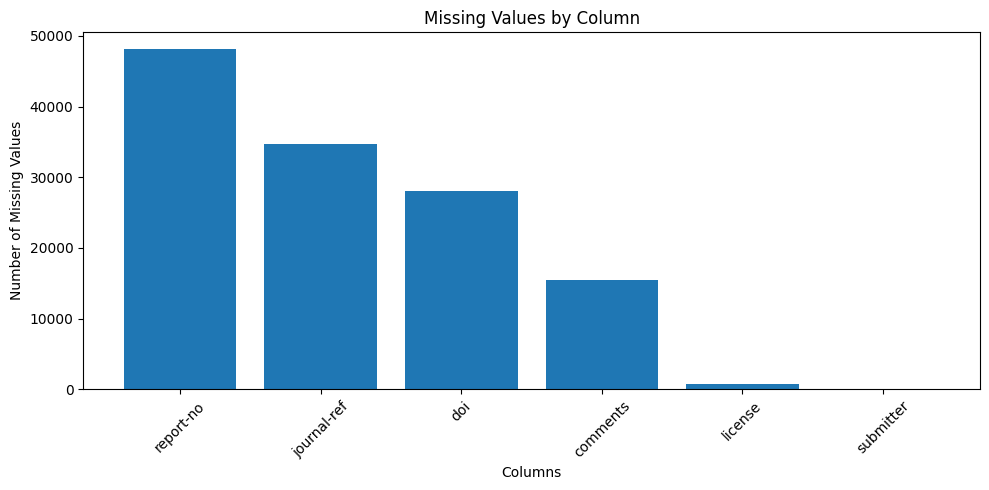

In [ ]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_values)

print("\nTotal Missing Values:", df.isnull().sum().sum())
missing_plot = missing_values[
    missing_values["Missing Values"] > 0
]

if len(missing_plot) > 0:

    plt.figure(figsize=(10, 5))

    plt.bar(
        missing_plot.index,
        missing_plot["Missing Values"]
    )

    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("No missing values found in the dataset.")

Duplicate Analysis

In [ ]:
if "abstract" in df.columns:

    abstract_duplicates = df.duplicated(
        subset=["abstract"]
    ).sum()

    print(
        "Duplicate Abstracts:",
        abstract_duplicates
    )

if "title" in df.columns:

    title_duplicates = df.duplicated(
        subset=["title"]
    ).sum()

    print(
        "Duplicate Titles:",
        title_duplicates
    )

Duplicate Abstracts: 1
Duplicate Titles: 6


Class Distribution table

In [ ]:
class_distribution = pd.DataFrame({
    "Count": df["target_classname"].value_counts(),
    "Percentage": (
        df["target_classname"]
        .value_counts(normalize=True)
        * 100
    )
})

class_distribution = class_distribution.sort_values(
    by="Count",
    ascending=False
)

class_distribution["Percentage"] = (
    class_distribution["Percentage"].round(2)
)

display(class_distribution)

,Count,Percentage
target_classname,,
physics,21774,43.56
cs,13291,26.59
math,10462,20.93
eess,2031,4.06
stat,1341,2.68
q-bio,682,1.36
q-fin,269,0.54
econ,136,0.27


Class imbalance ratio

CLASS IMBALANCE ANALYSIS
Largest Class Size: 21774
Smallest Class Size: 136
Imbalance Ratio: 160.10:1


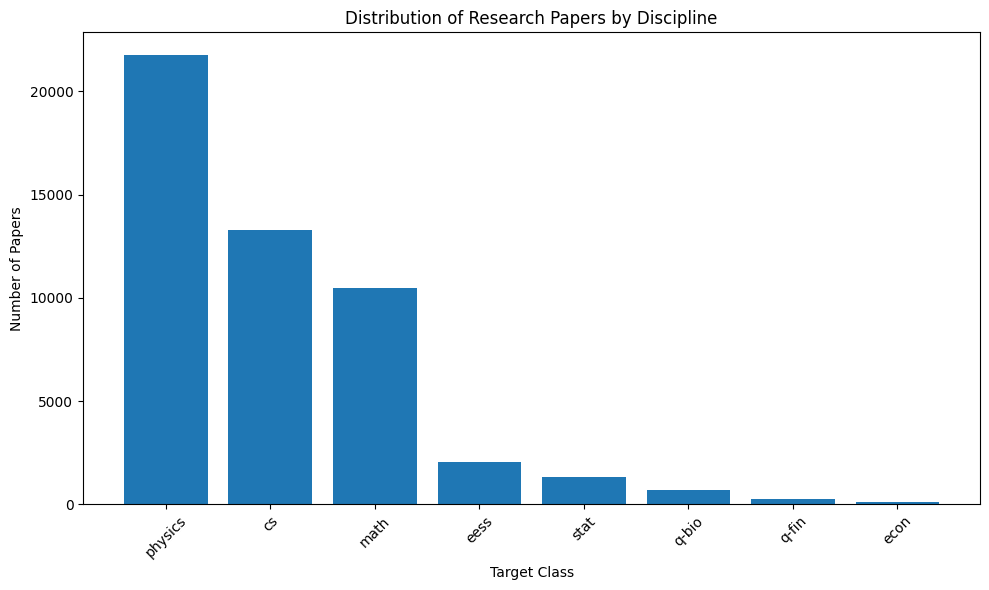

In [ ]:
class_counts = df[
    "target_classname"
].value_counts()

largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = (
    largest_class / smallest_class
)

print("=" * 70)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 70)

print(f"Largest Class Size: {largest_class}")
print(f"Smallest Class Size: {smallest_class}")

print(
    f"Imbalance Ratio: "
    f"{imbalance_ratio:.2f}:1"
)
class_counts = (
    df["target_classname"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("Distribution of Research Papers by Discipline")
plt.xlabel("Target Class")
plt.ylabel("Number of Papers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Text length statistics

In [ ]:
df["title_length"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["abstract_length"] = (
    df["abstract"]
    .fillna("")
    .astype(str)
    .str.len()
)

print("=" * 70)
print("TEXT LENGTH STATISTICS")
print("=" * 70)

print("\nTITLE LENGTH:")
display(
    df["title_length"].describe()
)

print("\nABSTRACT LENGTH:")
display(
    df["abstract_length"].describe()
)

TEXT LENGTH STATISTICS

TITLE LENGTH:


,title_length
count,49986.000000
mean,75.758272
std,27.442436
min,6.000000
25%,56.000000
50%,72.000000
75%,92.000000
max,244.000000



ABSTRACT LENGTH:


,abstract_length
count,49986.000000
mean,1007.471932
std,413.120536
min,19.000000
25%,701.000000
50%,990.000000
75%,1295.000000
max,3506.000000


Word count analysis

In [ ]:
df["title_word_count"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

df["abstract_word_count"] = (
    df["abstract"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("=" * 70)
print("WORD COUNT STATISTICS")
print("=" * 70)

print("\nTITLE WORD COUNT:")
display(
    df["title_word_count"].describe()
)

print("\nABSTRACT WORD COUNT:")
display(
    df["abstract_word_count"].describe()
)

WORD COUNT STATISTICS

TITLE WORD COUNT:


,title_word_count
count,49986.000000
mean,9.831293
std,3.690248
min,1.000000
25%,7.000000
50%,9.000000
75%,12.000000
max,36.000000



ABSTRACT WORD COUNT:


,abstract_word_count
count,49986.000000
mean,148.005822
std,61.082814
min,3.000000
25%,103.000000
50%,145.000000
75%,190.000000
max,528.000000


Abstract length distribution and abstract word count by discipline

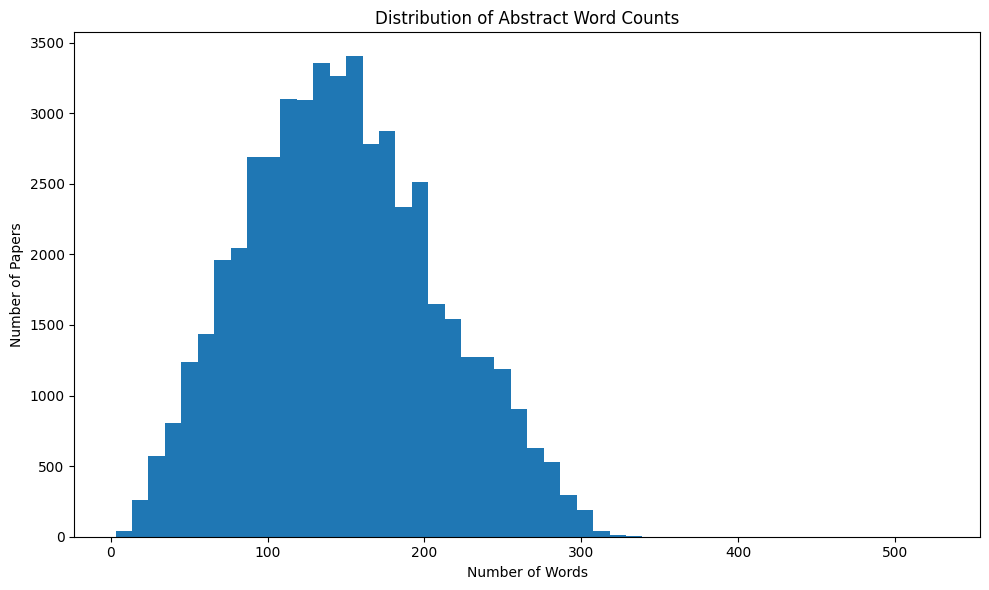

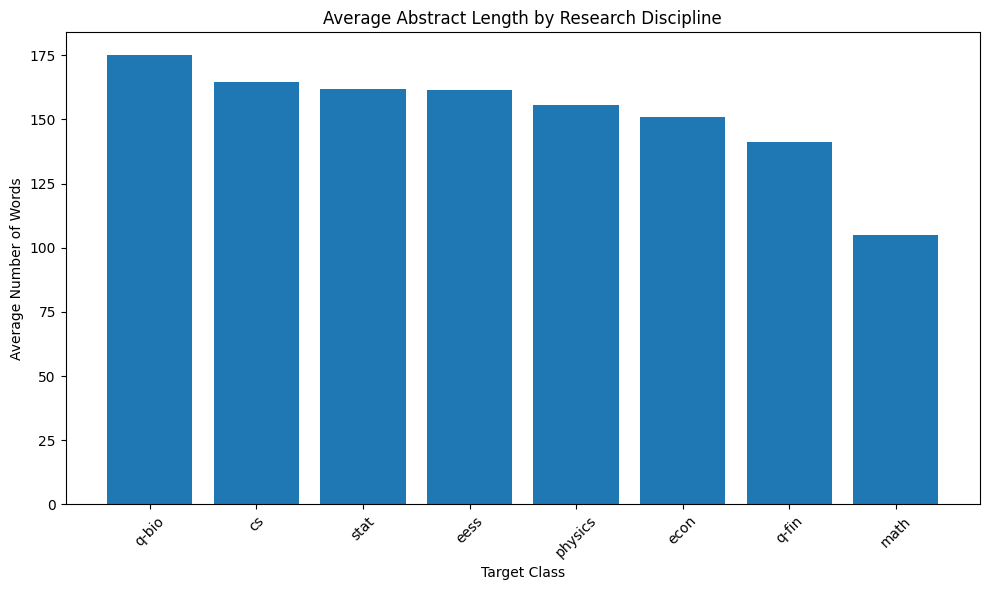

,Average Word Count
target_classname,
q-bio,175.209677
cs,164.792491
stat,161.986577
eess,161.604136
physics,155.495407
econ,150.941176
q-fin,141.394052
math,105.018830


,Median Word Count
target_classname,
q-bio,174.0
cs,162.0
stat,161.0
eess,159.0
physics,149.0
econ,143.0
q-fin,136.0
math,95.0


,Number_of_Papers,Avg_Title_Words,Avg_Abstract_Words,Median_Abstract_Words,Min_Abstract_Words,Max_Abstract_Words
target_classname,,,,,,
physics,21774,10.56,155.50,149.0,3,528
cs,13291,9.12,164.79,162.0,5,488
math,10462,9.04,105.02,95.0,3,335
eess,2031,10.44,161.60,159.0,15,306
stat,1341,9.53,161.99,161.0,24,302
q-bio,682,11.47,175.21,174.0,25,335
q-fin,269,9.74,141.39,136.0,13,304
econ,136,10.12,150.94,143.0,34,288


In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["abstract_word_count"],
    bins=50
)

plt.title("Distribution of Abstract Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()
average_length_by_class = (
    df.groupby("target_classname")[
        "abstract_word_count"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    average_length_by_class.index,
    average_length_by_class.values
)

plt.title("Average Abstract Length by Research Discipline")
plt.xlabel("Target Class")
plt.ylabel("Average Number of Words")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

display(
    average_length_by_class.to_frame(
        "Average Word Count"
    )
)
median_length_by_class = (
    df.groupby("target_classname")[
        "abstract_word_count"
    ]
    .median()
    .sort_values(ascending=False)
)

display(
    median_length_by_class.to_frame(
        "Median Word Count"
    )
)
text_stats_by_class = (
    df.groupby("target_classname")
    .agg(
        Number_of_Papers=(
            "target_classname",
            "count"
        ),
        Avg_Title_Words=(
            "title_word_count",
            "mean"
        ),
        Avg_Abstract_Words=(
            "abstract_word_count",
            "mean"
        ),
        Median_Abstract_Words=(
            "abstract_word_count",
            "median"
        ),
        Min_Abstract_Words=(
            "abstract_word_count",
            "min"
        ),
        Max_Abstract_Words=(
            "abstract_word_count",
            "max"
        )
    )
    .round(2)
    .sort_values(
        "Number_of_Papers",
        ascending=False
    )
)

display(text_stats_by_class)

Category analysis

,num_categories
count,49986.000000
mean,1.831293
std,0.977616
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,8.000000



Average Categories Per Paper: 1.83


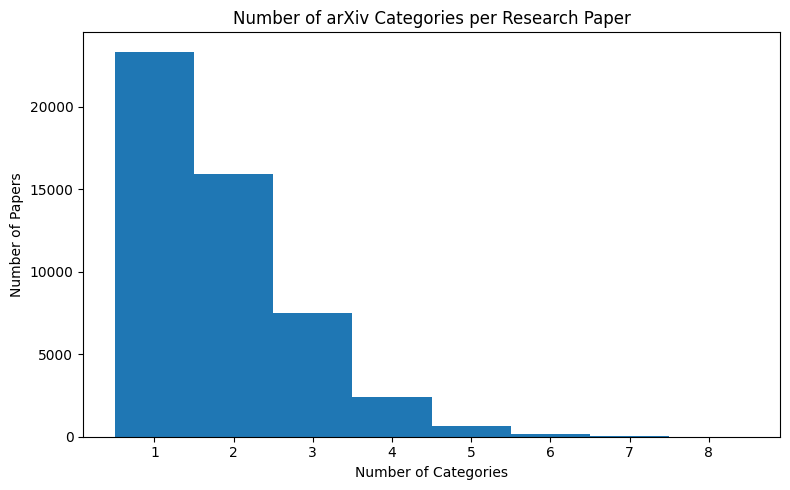

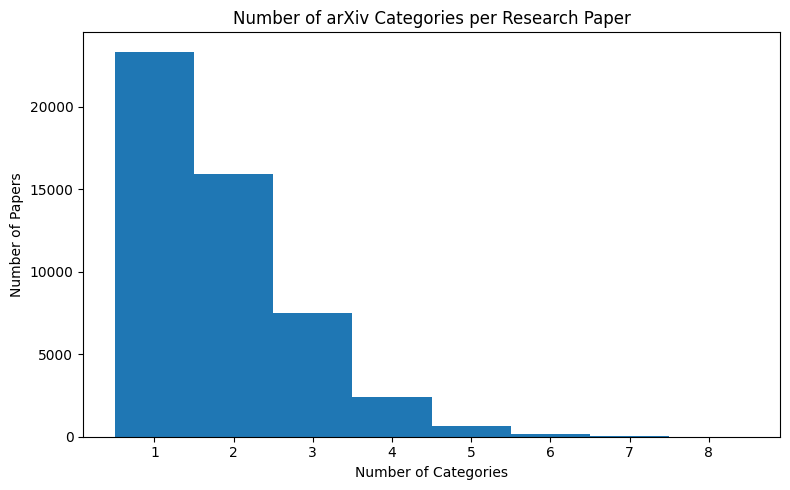

MULTI-CATEGORY ANALYSIS
Single Category Papers: 23356
Multi-Category Papers: 26630
Percentage Multi-Category: 53.27%


In [ ]:
df["num_categories"] = (
    df["categories"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

display(
    df["num_categories"].describe()
)

print(
    "\nAverage Categories Per Paper:",
    round(df["num_categories"].mean(), 2)
)

plt.figure(figsize=(8, 5))

plt.hist(
    df["num_categories"],
    bins=range(
        1,
        int(df["num_categories"].max()) + 2
    ),
    align="left"
)

plt.title("Number of arXiv Categories per Research Paper")
plt.xlabel("Number of Categories")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.hist(
    df["num_categories"],
    bins=range(
        1,
        int(df["num_categories"].max()) + 2
    ),
    align="left"
)

plt.title("Number of arXiv Categories per Research Paper")
plt.xlabel("Number of Categories")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

multi_category_count = (
    df["num_categories"] > 1
).sum()

single_category_count = (
    df["num_categories"] == 1
).sum()

print("=" * 70)
print("MULTI-CATEGORY ANALYSIS")
print("=" * 70)

print(
    f"Single Category Papers: "
    f"{single_category_count}"
)

print(
    f"Multi-Category Papers: "
    f"{multi_category_count}"
)

print(
    f"Percentage Multi-Category: "
    f"{(multi_category_count / len(df)) * 100:.2f}%"
)

Most common original arXiv categories

,Category,Count
0,cs.LG,5848
1,stat.ML,3676
2,cs.CV,3635
3,quant-ph,2601
4,hep-th,2300
5,hep-ph,2228
6,cond-mat.mtrl-sci,1810
7,cond-mat.mes-hall,1745
8,cs.CL,1695
9,gr-qc,1662


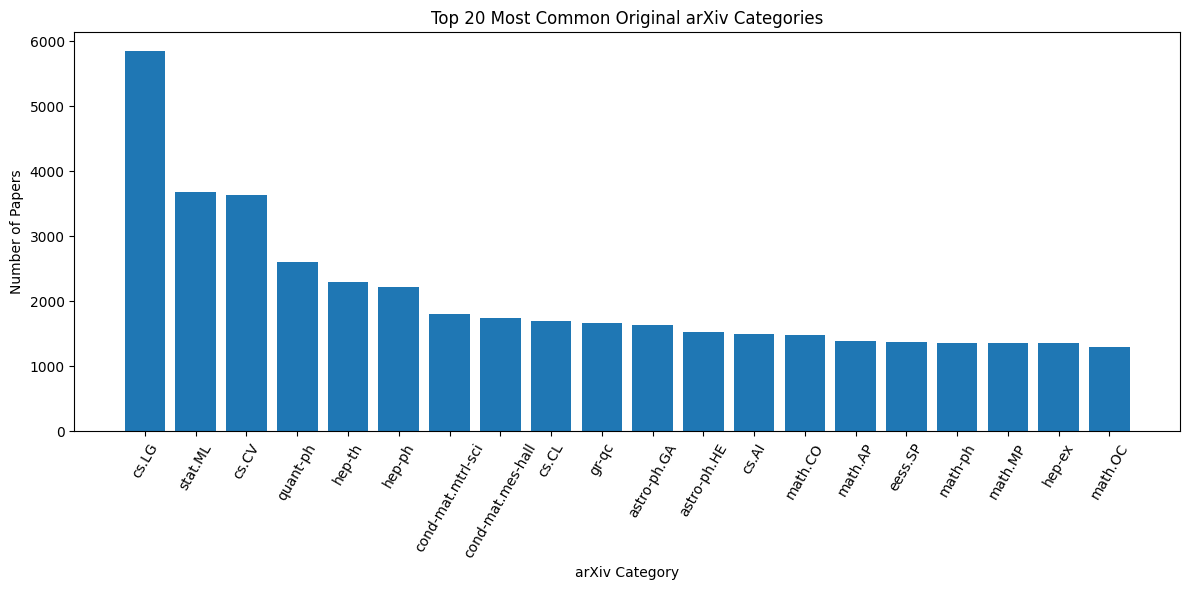

In [ ]:
from collections import Counter

all_categories = []

for category_string in df["categories"].fillna(""):

    all_categories.extend(
        category_string.split()
    )

category_counts = Counter(all_categories)

top_categories = pd.DataFrame(
    category_counts.most_common(20),
    columns=[
        "Category",
        "Count"
    ]
)

display(top_categories)

plt.figure(figsize=(12, 6))

plt.bar(
    top_categories["Category"],
    top_categories["Count"]
)

plt.title("Top 20 Most Common Original arXiv Categories")
plt.xlabel("arXiv Category")
plt.ylabel("Number of Papers")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

Title vs abstract length relationship

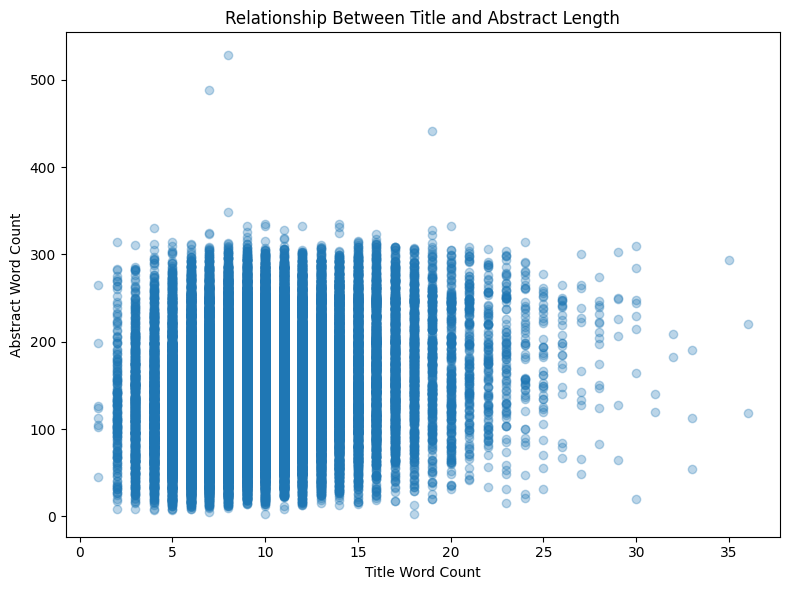


Correlation Matrix:


,title_word_count,abstract_word_count
title_word_count,1.000000,0.199918
abstract_word_count,0.199918,1.000000


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["title_word_count"],
    df["abstract_word_count"],
    alpha=0.3
)

plt.title("Relationship Between Title and Abstract Length")
plt.xlabel("Title Word Count")
plt.ylabel("Abstract Word Count")

plt.tight_layout()
plt.show()

correlation = df[
    ["title_word_count", "abstract_word_count"]
].corr()

print("\nCorrelation Matrix:")
display(correlation)

Random examples from each class

In [ ]:
for target_class in sorted(
    df["target_classname"].unique()
):

    print("\n" + "=" * 80)
    print(f"CLASS: {target_class}")
    print("=" * 80)

    sample = (
        df[
            df["target_classname"] == target_class
        ]
        .sample(
            1,
            random_state=42
        )
    )

    print(
        "TITLE:",
        sample["title"].iloc[0]
    )

    print(
        "\nABSTRACT:",
        sample["abstract"].iloc[0][:500],
        "..."
    )


CLASS: cs
TITLE: Infrared and Visible Image Fusion with ResNet and zero-phase component
  analysis

ABSTRACT:   Feature extraction and processing tasks play a key role in Image Fusion, and
the fusion performance is directly affected by the different features and
processing methods undertaken. By contrast, most of deep learning-based methods
use deep features directly without feature extraction or processing. This leads
to the fusion performance degradation in some cases. To solve these drawbacks,
we propose a deep features and zero-phase component analysis (ZCA) based novel
fusion framework is this pape ...

CLASS: econ
TITLE: Estimation and simulation of the transaction arrival process in intraday
  electricity markets

ABSTRACT:   We examine the novel problem of the estimation of transaction arrival
processes in the intraday electricity markets. We model the inter-arrivals
using multiple time-varying parametric densities based on the generalized F
distribution estimated by maximum l

EDA Plot

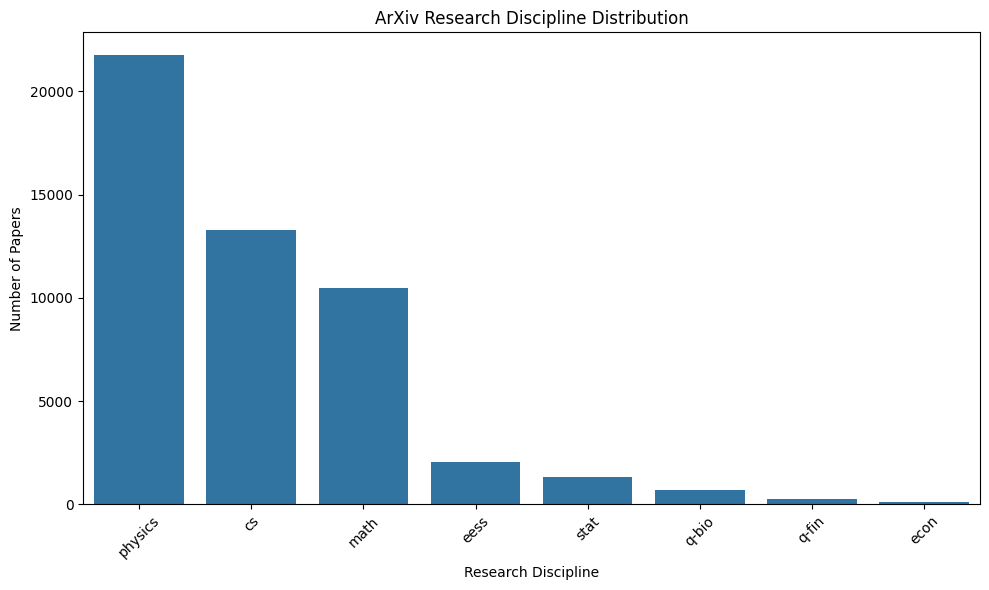

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("ArXiv Research Discipline Distribution")
plt.xlabel("Research Discipline")
plt.ylabel("Number of Papers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

count    49986.000000
mean       157.837114
std         61.926211
min         11.000000
25%        112.000000
50%        155.000000
75%        200.000000
max        536.000000
Name: word_count, dtype: float64


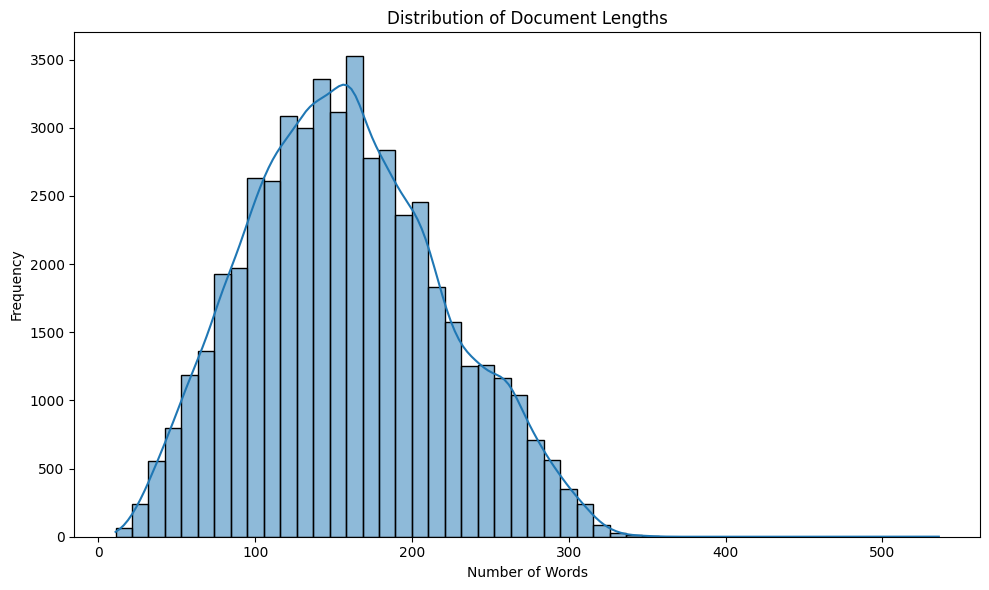

In [ ]:
df["word_count"] = df["text"].apply(
    lambda x: len(x.split())
)

print(df["word_count"].describe())

plt.figure(figsize=(10, 6))

sns.histplot(
    df["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Document Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Data Preprocessing

## Justification of Preprocessing

Preprocessing was performed to improve the quality and consistency of the textual data before training the machine learning and deep learning models. Since the dataset consists of research paper metadata and abstracts, the preprocessing strategy was designed to preserve meaningful academic and technical information while removing unnecessary noise.

### Handling Missing Values

Missing values in important textual fields such as the title and abstract were checked and handled before model training. This was necessary because machine learning and natural language processing models require valid textual input and cannot effectively process missing or null values.

### Removing Duplicate Records

Duplicate records were checked and removed to avoid repeated research papers appearing in both the training and evaluation process. Duplicate samples can lead to data leakage and artificially increase model performance.

### Text Cleaning

Textual content was cleaned to remove unnecessary whitespace and formatting inconsistencies. This improves consistency across research paper abstracts and titles while preserving meaningful technical vocabulary.

Heavy preprocessing such as aggressive removal of punctuation and technical terms was avoided because research paper abstracts contain domain-specific terminology, mathematical expressions, abbreviations, and technical phrases that may provide useful information for classification.

### Combining Textual Features

The title and abstract were combined to create a richer textual representation of each research paper. The title provides a concise summary of the research topic, while the abstract contains more detailed contextual information. Combining these fields allows the models to use both high-level topic information and detailed research content.

### Label Processing

The original arXiv categories were mapped into eight major target disciplines:

- Computer Science
- Mathematics
- Physics
- Statistics
- Quantitative Biology
- Quantitative Finance
- Electrical Engineering and Systems Science
- Economics

This transformation converted the task into a multi-class classification problem. Label encoding was then used to convert the categorical target classes into numerical values required by machine learning and neural network models.

### Train, Validation, and Test Splitting

The dataset was divided into training, validation, and test sets using a fixed random seed. Stratified splitting was used to preserve the class distribution across the different subsets.

The training set was used for learning model parameters, the validation set was used for hyperparameter selection and model configuration comparison, and the test set was reserved for final evaluation. This separation helps reduce the risk of overfitting and ensures a fair comparison between models.

### TF-IDF Representation

TF-IDF was used for the classical machine learning models because it represents documents based on the importance of words within the dataset. Common words receive lower importance, while words that are more distinctive to particular documents or disciplines receive higher weights.

This representation is particularly suitable for models such as Logistic Regression, Naive Bayes, and Random Forest.

### Sequence Preparation for RNN Models

For the recurrent neural network models, the text was tokenized and converted into numerical sequences. The sequences were padded or truncated to a fixed maximum length.

Padding was necessary because neural network models require input sequences of consistent length within a batch. The sequence representation allows RNN-based models to learn relationships between words and capture sequential patterns in the text.

### Transformer Tokenization

BERT used its own pretrained tokenizer rather than the manually processed TF-IDF or RNN sequences. The BERT tokenizer converts text into subword tokens and includes special tokens required by the transformer architecture.

Minimal preprocessing was applied before BERT tokenization because aggressive text cleaning could remove information that the pretrained language model uses to understand contextual relationships.

### Overall Justification

Different preprocessing and representation strategies were used because the models have different input requirements. Classical machine learning models benefit from sparse statistical representations such as TF-IDF, recurrent neural networks require ordered numerical sequences, and transformer models use contextual token representations.

Using model-specific preprocessing allowed each model to operate with the type of textual representation most suitable for its architecture.

Encide target labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["target_classname"]
)

class_names = label_encoder.classes_

print("Class mapping:")
for index, class_name in enumerate(class_names):
    print(f"{index} -> {class_name}")

print("\nNumber of classes:", len(class_names))

Class mapping:
0 -> cs
1 -> econ
2 -> eess
3 -> math
4 -> physics
5 -> q-bio
6 -> q-fin
7 -> stat

Number of classes: 8


# Train/Validation/Test Split

In [ ]:
X = df["text"].values
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst document:")
print(X[0][:500])

print("\nFirst label:")
print(y[0])

X shape: (49986,)
y shape: (49986,)

First document:
Aim Low, Shoot High: Evading Aimbot Detectors by Mimicking User Behavior   Current schemes to detect cheating in online games often build on the
assumption that the applied cheat takes actions that are drastically different
from normal behavior. For instance, an Aimbot for a first-person shooter is
used by an amateur player to increase his/her capabilities many times over.
Attempts to evade detection would require to reduce the intended effect such
that the advantage is presumably lowered into i

First label:
0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 34990
Validation samples: 7498
Test samples: 7498


Startify verification

In [ ]:
print("=" * 60)
print("TRAIN DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(y_train)
    .map(dict(enumerate(class_names)))
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\n" + "=" * 60)
print("VALIDATION DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(y_val)
    .map(dict(enumerate(class_names)))
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\n" + "=" * 60)
print("TEST DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(y_test)
    .map(dict(enumerate(class_names)))
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

TRAIN DISTRIBUTION
cs         26.59
econ        0.27
eess        4.06
math       20.93
physics    43.56
q-bio       1.36
q-fin       0.54
stat        2.68
Name: proportion, dtype: float64

VALIDATION DISTRIBUTION
cs         26.59
econ        0.27
eess        4.07
math       20.93
physics    43.56
q-bio       1.36
q-fin       0.55
stat        2.68
Name: proportion, dtype: float64

TEST DISTRIBUTION
cs         26.58
econ        0.28
eess        4.05
math       20.94
physics    43.56
q-bio       1.37
q-fin       0.53
stat        2.68
Name: proportion, dtype: float64


Class weights calculation

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        classes,
        class_weights_array
    )
}

print("Class weights:")

for class_id, weight in class_weights.items():
    print(
        f"{class_names[class_id]:8s} -> {weight:.4f}"
    )

Class weights:
cs       -> 0.4701
econ     -> 46.0395
eess     -> 3.0758
math     -> 0.5973
physics  -> 0.2870
q-bio    -> 9.1693
q-fin    -> 23.2646
stat     -> 4.6579


In [ ]:
df.to_csv(
    "arxiv_clean_50k.csv",
    index=False
)

print(
    "Saved: arxiv_clean_50k.csv"
)

Saved: arxiv_clean_50k.csv


In [ ]:
dataset_summary = pd.DataFrame({
    "Split": [
        "Full Dataset",
        "Training",
        "Validation",
        "Test"
    ],
    "Samples": [
        len(df),
        len(X_train),
        len(X_val),
        len(X_test)
    ]
})

dataset_summary

,Split,Samples
0,Full Dataset,49986
1,Training,34990
2,Validation,7498
3,Test,7498


# Text Preprocess

Preprocessing function

In [ ]:
import re

def clean_text(text):

    text = str(text)
    text = text.lower()

    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\$+", " ", text)
    text = re.sub(r"[{}[\]<>]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
X_train_clean = np.array([
    clean_text(x) for x in X_train
])

X_val_clean = np.array([
    clean_text(x) for x in X_val
])

X_test_clean = np.array([
    clean_text(x) for x in X_test
])

print("Preprocessing completed.")

print("\nExample:")
print(X_train_clean[0][:1000])

Preprocessing completed.

Example:
characterising the correlations of prepare-and-measure quantum networks prepare-and-measure (p&m) quantum networks are the basic building blocks of quantum communication and cryptography. these networks crucially rely on non-orthogonal quantum encodings to distribute quantum correlations, thus enabling superior communication rates and information-theoretic security. here, we present a computational toolbox that is able to efficiently characterise the set of input-output probability distributions for any discrete-variable p&m quantum network, assuming only the inner-product information of the quantum encodings. our toolbox is thus highly versatile and can be used to analyse a wide range of quantum network protocols, including those that employ infinite-dimensional quantum code states. to demonstrate the feasibility and efficacy of our toolbox, we use it to reveal new results in multipartite quantum distributed computing and quantum cryptography. taken 

Preprocessing Verification

In [ ]:
print("Original length:")
print(len(X_train[0]))

print("\nCleaned length:")
print(len(X_train_clean[0]))

print("\nOriginal word count:")
print(len(X_train[0].split()))

print("\nCleaned word count:")
print(len(X_train_clean[0].split()))

Original length:
1125

Cleaned length:
1123

Original word count:
148

Cleaned word count:
148


# TF-IDF Representation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(
    X_train_clean
)

X_val_tfidf = tfidf.transform(
    X_val_clean
)

X_test_tfidf = tfidf.transform(
    X_test_clean
)

print("TF-IDF completed.")

print("Training shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

print(
    "\nVocabulary size:",
    len(tfidf.vocabulary_)
)

TF-IDF completed.
Training shape: (34990, 50000)
Validation shape: (7498, 50000)
Test shape: (7498, 50000)

Vocabulary size: 50000


Strongest TF-IDF Terms

In [ ]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

mean_tfidf = np.asarray(
    X_train_tfidf.mean(axis=0)
).ravel()

top_indices = mean_tfidf.argsort()[-30:][::-1]

top_terms = pd.DataFrame({
    "term": feature_names[top_indices],
    "mean_tfidf": mean_tfidf[top_indices]
})

top_terms

,term,mean_tfidf
0,and,0.027985
1,in,0.026045
2,to,0.025354
3,we,0.022765
4,for,0.021074
5,is,0.020508
6,of the,0.019623
7,that,0.018376
8,with,0.018149
9,on,0.017522


evaluation framework

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

results = []

In [ ]:
def evaluate_model(
    model_name,
    representation,
    y_true,
    y_pred,
    split="validation",
    configuration=None
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result = {
        "model": model_name,
        "representation": representation,
        "configuration": configuration,
        "split": split,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

    results.append(result)

    print(f"\n{'='*60}")
    print(f"{model_name} | {representation}")
    print(f"{'='*60}")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall   : {recall:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")
    print(f"Weighted F1    : {weighted_f1:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    return result

Confusion Matrix

In [ ]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    title
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(10, 8)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

Hyperparameter and helper

In [ ]:
tuning_results = []
def record_tuning_result(
    model,
    representation,
    configuration,
    hyperparameters,
    validation_accuracy,
    validation_macro_f1
):

    tuning_results.append({
        "model": model,
        "representation": representation,
        "configuration": configuration,
        "hyperparameters": str(hyperparameters),
        "validation_accuracy": validation_accuracy,
        "validation_macro_f1": validation_macro_f1
    })

tuning_df = pd.DataFrame(
    tuning_results
)

# Classical ML Models

Logistic Regression Configuaration 1

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_config_1 = {
    "C": 1.0,
    "solver": "saga",
    "max_iter": 1000,
    "class_weight": "balanced"
}

lr_1 = LogisticRegression(
    **lr_config_1
)

print("Training Logistic Regression - Configuration 1...")

lr_1.fit(
    X_train_tfidf,
    y_train
)

lr_val_pred_1 = lr_1.predict(
    X_val_tfidf
)

lr_result_1 = evaluate_model(
    model_name="Logistic Regression",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=lr_val_pred_1,
    split="validation",
    configuration="LR-1"
)

record_tuning_result(
    model="Logistic Regression",
    representation="TF-IDF",
    configuration="LR-1",
    hyperparameters=lr_config_1,
    validation_accuracy=lr_result_1["accuracy"],
    validation_macro_f1=lr_result_1["macro_f1"]
)

Training Logistic Regression - Configuration 1...

Logistic Regression | TF-IDF
Accuracy       : 0.7769
Macro Precision: 0.5215
Macro Recall   : 0.6590
Macro F1       : 0.4860
Weighted F1    : 0.8072

Classification Report:
              precision    recall  f1-score   support

          cs       0.84      0.75      0.79      1994
        econ       0.06      0.60      0.10        20
        eess       0.58      0.10      0.17       305
        math       0.85      0.88      0.87      1569
     physics       0.98      0.82      0.89      3266
       q-bio       0.12      0.93      0.21       102
       q-fin       0.25      0.73      0.38        41
        stat       0.48      0.45      0.47       201

    accuracy                           0.78      7498
   macro avg       0.52      0.66      0.49      7498
weighted avg       0.87      0.78      0.81      7498



Logistic Regression Configuartion 2

In [ ]:
lr_config_2 = {
    "C": 2.0,
    "solver": "saga",
    "max_iter": 1000,
    "class_weight": "balanced"
}

lr_2 = LogisticRegression(
    **lr_config_2
)

print("Training Logistic Regression - Configuration 2...")

lr_2.fit(
    X_train_tfidf,
    y_train
)

lr_val_pred_2 = lr_2.predict(
    X_val_tfidf
)

lr_result_2 = evaluate_model(
    model_name="Logistic Regression",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=lr_val_pred_2,
    split="validation",
    configuration="LR-2"
)

record_tuning_result(
    model="Logistic Regression",
    representation="TF-IDF",
    configuration="LR-2",
    hyperparameters=lr_config_2,
    validation_accuracy=lr_result_2["accuracy"],
    validation_macro_f1=lr_result_2["macro_f1"]
)

Training Logistic Regression - Configuration 2...

Logistic Regression | TF-IDF
Accuracy       : 0.8314
Macro Precision: 0.5954
Macro Recall   : 0.6343
Macro F1       : 0.5713
Weighted F1    : 0.8455

Classification Report:
              precision    recall  f1-score   support

          cs       0.88      0.74      0.80      1994
        econ       0.33      0.10      0.15        20
        eess       0.51      0.51      0.51       305
        math       0.89      0.86      0.88      1569
     physics       0.96      0.92      0.94      3266
       q-bio       0.29      0.77      0.42       102
       q-fin       0.61      0.34      0.44        41
        stat       0.29      0.83      0.43       201

    accuracy                           0.83      7498
   macro avg       0.60      0.63      0.57      7498
weighted avg       0.87      0.83      0.85      7498



Logistic Regression Configuartion 3

In [ ]:
lr_config_3 = {
    "C": 4.0,
    "solver": "saga",
    "max_iter": 1000,
    "class_weight": "balanced"
}

lr_3 = LogisticRegression(
    **lr_config_3
)

print("Training Logistic Regression - Configuration 3...")

lr_3.fit(
    X_train_tfidf,
    y_train
)

lr_val_pred_3 = lr_3.predict(
    X_val_tfidf
)

lr_result_3 = evaluate_model(
    model_name="Logistic Regression",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=lr_val_pred_3,
    split="validation",
    configuration="LR-3"
)

record_tuning_result(
    model="Logistic Regression",
    representation="TF-IDF",
    configuration="LR-3",
    hyperparameters=lr_config_3,
    validation_accuracy=lr_result_3["accuracy"],
    validation_macro_f1=lr_result_3["macro_f1"]
)

Training Logistic Regression - Configuration 3...

Logistic Regression | TF-IDF
Accuracy       : 0.8561
Macro Precision: 0.5847
Macro Recall   : 0.6147
Macro F1       : 0.5746
Weighted F1    : 0.8607

Classification Report:
              precision    recall  f1-score   support

          cs       0.85      0.84      0.84      1994
        econ       0.00      0.00      0.00        20
        eess       0.45      0.62      0.52       305
        math       0.93      0.81      0.86      1569
     physics       0.95      0.94      0.94      3266
       q-bio       0.37      0.85      0.52       102
       q-fin       0.62      0.24      0.35        41
        stat       0.51      0.61      0.56       201

    accuracy                           0.86      7498
   macro avg       0.58      0.61      0.57      7498
weighted avg       0.87      0.86      0.86      7498



Logistic Regression Result

In [ ]:
pd.DataFrame(
    tuning_results
).sort_values(
    "validation_macro_f1",
    ascending=False
)

,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
2,Logistic Regression,TF-IDF,LR-3,"{'C': 4.0, 'solver': 'saga', 'max_iter': 1000,...",0.856095,0.574648
1,Logistic Regression,TF-IDF,LR-2,"{'C': 2.0, 'solver': 'saga', 'max_iter': 1000,...",0.831422,0.571340
0,Logistic Regression,TF-IDF,LR-1,"{'C': 1.0, 'solver': 'saga', 'max_iter': 1000,...",0.776874,0.486000


Naive Bayes Configuration 1

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_config_1 = {
    "alpha": 0.1
}

nb_1 = MultinomialNB(
    **nb_config_1
)

print("Training Naive Bayes - Configuration 1...")

nb_1.fit(
    X_train_tfidf,
    y_train
)

nb_val_pred_1 = nb_1.predict(
    X_val_tfidf
)

nb_result_1 = evaluate_model(
    model_name="Naive Bayes",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=nb_val_pred_1,
    split="validation",
    configuration="NB-1"
)

record_tuning_result(
    model="Naive Bayes",
    representation="TF-IDF",
    configuration="NB-1",
    hyperparameters=nb_config_1,
    validation_accuracy=nb_result_1["accuracy"],
    validation_macro_f1=nb_result_1["macro_f1"]
)

Training Naive Bayes - Configuration 1...

Naive Bayes | TF-IDF
Accuracy       : 0.8610
Macro Precision: 0.6866
Macro Recall   : 0.5145
Macro F1       : 0.5473
Weighted F1    : 0.8554

Classification Report:
              precision    recall  f1-score   support

          cs       0.79      0.89      0.84      1994
        econ       0.00      0.00      0.00        20
        eess       0.52      0.37      0.44       305
        math       0.83      0.92      0.87      1569
     physics       0.97      0.91      0.94      3266
       q-bio       0.75      0.39      0.52       102
       q-fin       1.00      0.12      0.22        41
        stat       0.63      0.51      0.56       201

    accuracy                           0.86      7498
   macro avg       0.69      0.51      0.55      7498
weighted avg       0.86      0.86      0.86      7498



Naive Bayes Configuration 2

In [ ]:
nb_config_2 = {
    "alpha": 0.5
}

nb_2 = MultinomialNB(
    **nb_config_2
)

print("Training Naive Bayes - Configuration 2...")

nb_2.fit(
    X_train_tfidf,
    y_train
)

nb_val_pred_2 = nb_2.predict(
    X_val_tfidf
)

nb_result_2 = evaluate_model(
    model_name="Naive Bayes",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=nb_val_pred_2,
    split="validation",
    configuration="NB-2"
)

record_tuning_result(
    model="Naive Bayes",
    representation="TF-IDF",
    configuration="NB-2",
    hyperparameters=nb_config_2,
    validation_accuracy=nb_result_2["accuracy"],
    validation_macro_f1=nb_result_2["macro_f1"]
)

Training Naive Bayes - Configuration 2...

Naive Bayes | TF-IDF
Accuracy       : 0.8414
Macro Precision: 0.6197
Macro Recall   : 0.3580
Macro F1       : 0.3497
Weighted F1    : 0.8106

Classification Report:
              precision    recall  f1-score   support

          cs       0.71      0.94      0.81      1994
        econ       0.00      0.00      0.00        20
        eess       0.90      0.06      0.12       305
        math       0.82      0.92      0.87      1569
     physics       0.96      0.91      0.93      3266
       q-bio       1.00      0.01      0.02       102
       q-fin       0.00      0.00      0.00        41
        stat       0.56      0.02      0.05       201

    accuracy                           0.84      7498
   macro avg       0.62      0.36      0.35      7498
weighted avg       0.85      0.84      0.81      7498



Naive Bayes Configuration 3

In [ ]:
nb_config_3 = {
    "alpha": 1.0
}

nb_3 = MultinomialNB(
    **nb_config_3
)

print("Training Naive Bayes - Configuration 3...")

nb_3.fit(
    X_train_tfidf,
    y_train
)

nb_val_pred_3 = nb_3.predict(
    X_val_tfidf
)

nb_result_3 = evaluate_model(
    model_name="Naive Bayes",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=nb_val_pred_3,
    split="validation",
    configuration="NB-3"
)

record_tuning_result(
    model="Naive Bayes",
    representation="TF-IDF",
    configuration="NB-3",
    hyperparameters=nb_config_3,
    validation_accuracy=nb_result_3["accuracy"],
    validation_macro_f1=nb_result_3["macro_f1"]
)

Training Naive Bayes - Configuration 3...

Naive Bayes | TF-IDF
Accuracy       : 0.8381
Macro Precision: 0.3115
Macro Recall   : 0.3450
Macro F1       : 0.3260
Weighted F1    : 0.8025

Classification Report:
              precision    recall  f1-score   support

          cs       0.71      0.94      0.81      1994
        econ       0.00      0.00      0.00        20
        eess       0.00      0.00      0.00       305
        math       0.84      0.91      0.87      1569
     physics       0.95      0.92      0.93      3266
       q-bio       0.00      0.00      0.00       102
       q-fin       0.00      0.00      0.00        41
        stat       0.00      0.00      0.00       201

    accuracy                           0.84      7498
   macro avg       0.31      0.34      0.33      7498
weighted avg       0.78      0.84      0.80      7498



Naive Bayes Result

In [ ]:
tuning_df = pd.DataFrame(
    tuning_results
)

print(
    tuning_df[
        tuning_df["model"] == "Naive Bayes"
    ].sort_values(
        "validation_macro_f1",
        ascending=False
    ).to_string(index=False)
)

      model representation configuration hyperparameters  validation_accuracy  validation_macro_f1
Naive Bayes         TF-IDF          NB-1  {'alpha': 0.1}             0.861030             0.547336
Naive Bayes         TF-IDF          NB-2  {'alpha': 0.5}             0.841424             0.349677
Naive Bayes         TF-IDF          NB-3  {'alpha': 1.0}             0.838090             0.326001


Random Forest Configuration 1

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_config_1 = {
    "n_estimators": 100,
    "max_depth": 20,
    "min_samples_split": 5,
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1
}

rf_1 = RandomForestClassifier(
    **rf_config_1
)

print("Training Random Forest - Configuration 1...")

rf_1.fit(
    X_train_tfidf,
    y_train
)

rf_val_pred_1 = rf_1.predict(
    X_val_tfidf
)

rf_result_1 = evaluate_model(
    model_name="Random Forest",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=rf_val_pred_1,
    split="validation",
    configuration="RF-1"
)

record_tuning_result(
    model="Random Forest",
    representation="TF-IDF",
    configuration="RF-1",
    hyperparameters=rf_config_1,
    validation_accuracy=rf_result_1["accuracy"],
    validation_macro_f1=rf_result_1["macro_f1"]
)

Training Random Forest - Configuration 1...

Random Forest | TF-IDF
Accuracy       : 0.7605
Macro Precision: 0.5409
Macro Recall   : 0.5890
Macro F1       : 0.5431
Weighted F1    : 0.7698

Classification Report:
              precision    recall  f1-score   support

          cs       0.84      0.61      0.71      1994
        econ       0.25      0.05      0.08        20
        eess       0.28      0.56      0.38       305
        math       0.68      0.86      0.76      1569
     physics       0.92      0.85      0.88      3266
       q-bio       0.42      0.54      0.47       102
       q-fin       0.54      0.68      0.60        41
        stat       0.39      0.57      0.46       201

    accuracy                           0.76      7498
   macro avg       0.54      0.59      0.54      7498
weighted avg       0.80      0.76      0.77      7498



Random Forest Configuration 2

In [ ]:
rf_config_2 = {
    "n_estimators": 150,
    "max_depth": 30,
    "min_samples_split": 5,
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1
}

rf_2 = RandomForestClassifier(
    **rf_config_2
)

print("Training Random Forest - Configuration 2...")

rf_2.fit(
    X_train_tfidf,
    y_train
)

rf_val_pred_2 = rf_2.predict(
    X_val_tfidf
)

rf_result_2 = evaluate_model(
    model_name="Random Forest",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=rf_val_pred_2,
    split="validation",
    configuration="RF-2"
)

record_tuning_result(
    model="Random Forest",
    representation="TF-IDF",
    configuration="RF-2",
    hyperparameters=rf_config_2,
    validation_accuracy=rf_result_2["accuracy"],
    validation_macro_f1=rf_result_2["macro_f1"]
)

Training Random Forest - Configuration 2...

Random Forest | TF-IDF
Accuracy       : 0.7933
Macro Precision: 0.5506
Macro Recall   : 0.5471
Macro F1       : 0.5465
Weighted F1    : 0.7935

Classification Report:
              precision    recall  f1-score   support

          cs       0.80      0.73      0.77      1994
        econ       0.00      0.00      0.00        20
        eess       0.35      0.38      0.36       305
        math       0.72      0.86      0.78      1569
     physics       0.91      0.87      0.89      3266
       q-bio       0.51      0.38      0.44       102
       q-fin       0.63      0.63      0.63        41
        stat       0.49      0.51      0.50       201

    accuracy                           0.79      7498
   macro avg       0.55      0.55      0.55      7498
weighted avg       0.80      0.79      0.79      7498



Random Forest Configuration 3

In [ ]:
rf_config_3 = {
    "n_estimators": 200,
    "max_depth": 40,
    "min_samples_split": 3,
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1
}

rf_3 = RandomForestClassifier(
    **rf_config_3
)

print("Training Random Forest - Configuration 3...")

rf_3.fit(
    X_train_tfidf,
    y_train
)

rf_val_pred_3 = rf_3.predict(
    X_val_tfidf
)

rf_result_3 = evaluate_model(
    model_name="Random Forest",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=rf_val_pred_3,
    split="validation",
    configuration="RF-3"
)

record_tuning_result(
    model="Random Forest",
    representation="TF-IDF",
    configuration="RF-3",
    hyperparameters=rf_config_3,
    validation_accuracy=rf_result_3["accuracy"],
    validation_macro_f1=rf_result_3["macro_f1"]
)

Training Random Forest - Configuration 3...

Random Forest | TF-IDF
Accuracy       : 0.8055
Macro Precision: 0.5751
Macro Recall   : 0.4778
Macro F1       : 0.5084
Weighted F1    : 0.7970

Classification Report:
              precision    recall  f1-score   support

          cs       0.76      0.80      0.78      1994
        econ       0.00      0.00      0.00        20
        eess       0.40      0.22      0.28       305
        math       0.73      0.87      0.79      1569
     physics       0.91      0.89      0.90      3266
       q-bio       0.60      0.25      0.36       102
       q-fin       0.55      0.39      0.46        41
        stat       0.65      0.41      0.50       201

    accuracy                           0.81      7498
   macro avg       0.58      0.48      0.51      7498
weighted avg       0.80      0.81      0.80      7498



Random Forest Result

In [ ]:
tuning_df = pd.DataFrame(
    tuning_results
)

print(
    tuning_df[
        tuning_df["model"] == "Random Forest"
    ].sort_values(
        "validation_macro_f1",
        ascending=False
    ).to_string(index=False)
)

        model representation configuration                                                                                                              hyperparameters  validation_accuracy  validation_macro_f1
Random Forest         TF-IDF          RF-2 {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 5, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}             0.793278             0.546527
Random Forest         TF-IDF          RF-1 {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}             0.760469             0.543148
Random Forest         TF-IDF          RF-3 {'n_estimators': 200, 'max_depth': 40, 'min_samples_split': 3, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}             0.805548             0.508368


Classical ML Models Comparison

In [ ]:
tuning_df = pd.DataFrame(
    tuning_results
)

classical_results = (
    tuning_df[
        tuning_df["model"].isin([
            "Logistic Regression",
            "Naive Bayes",
            "Random Forest"
        ])
    ]
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
)

print(
    classical_results.to_string(
        index=False
    )
)

              model representation configuration                                                                                                              hyperparameters  validation_accuracy  validation_macro_f1
Logistic Regression         TF-IDF          LR-3                                                   {'C': 4.0, 'solver': 'saga', 'max_iter': 1000, 'class_weight': 'balanced'}             0.856095             0.574648
Logistic Regression         TF-IDF          LR-2                                                   {'C': 2.0, 'solver': 'saga', 'max_iter': 1000, 'class_weight': 'balanced'}             0.831422             0.571340
        Naive Bayes         TF-IDF          NB-1                                                                                                               {'alpha': 0.1}             0.861030             0.547336
      Random Forest         TF-IDF          RF-2 {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 5, 'class_weight': 'balance

In [ ]:
best_classical = (
    classical_results
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .groupby("model")
    .head(1)
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
)

print("\nBEST CONFIGURATION FOR EACH CLASSICAL MODEL")
print("=" * 70)

print(
    best_classical.to_string(
        index=False
    )
)


BEST CONFIGURATION FOR EACH CLASSICAL MODEL
              model representation configuration                                                                                                              hyperparameters  validation_accuracy  validation_macro_f1
Logistic Regression         TF-IDF          LR-3                                                   {'C': 4.0, 'solver': 'saga', 'max_iter': 1000, 'class_weight': 'balanced'}             0.856095             0.574648
        Naive Bayes         TF-IDF          NB-1                                                                                                               {'alpha': 0.1}             0.861030             0.547336
      Random Forest         TF-IDF          RF-2 {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 5, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}             0.793278             0.546527


In [ ]:
def evaluate_final_model(
    model,
    X_test_data,
    y_test_data,
    model_name,
    representation,
    configuration
):


    predictions = model.predict(X_test_data)


    probabilities = model.predict_proba(X_test_data)


    accuracy = accuracy_score(
        y_test_data,
        predictions
    )

    macro_f1 = f1_score(
        y_test_data,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test_data,
        predictions,
        average="weighted"
    )

    print("=" * 70)
    print(f"FINAL TEST EVALUATION: {model_name}")
    print("=" * 70)

    print(f"Best Configuration: {configuration}")
    print(f"Representation: {representation}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Macro F1: {macro_f1:.4f}")
    print(f"Test Weighted F1: {weighted_f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test_data,
            predictions,
            target_names=class_names,
            digits=4
        )
    )

    plot_confusion_matrix(
        y_test_data,
        predictions,
        f"{model_name} - Confusion Matrix"
    )

    return {
        "model": model_name,
        "configuration": configuration,
        "representation": representation,
        "test_accuracy": accuracy,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "predictions": predictions,
        "probabilities": probabilities
    }

In [ ]:
def select_best_classical_model(
    model_name,
    models_dict
):

    tuning_df = pd.DataFrame(
        tuning_results
    )

    model_results = (
        tuning_df[
            tuning_df["model"] == model_name
        ]
        .sort_values(
            "validation_macro_f1",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print("=" * 70)
    print(
        f"{model_name} HYPERPARAMETER TUNING RESULTS"
    )
    print("=" * 70)

    display(
        model_results
    )

    best_configuration = model_results.loc[
        0,
        "configuration"
    ]

    best_model = models_dict[
        best_configuration
    ]

    best_validation_accuracy = model_results.loc[
        0,
        "validation_accuracy"
    ]

    best_validation_f1 = model_results.loc[
        0,
        "validation_macro_f1"
    ]

    print("\nBest Configuration:")
    print(
        best_configuration
    )

    print("\nBest Validation Accuracy:")
    print(
        round(
            best_validation_accuracy,
            4
        )
    )

    print("\nBest Validation Macro F1:")
    print(
        round(
            best_validation_f1,
            4
        )
    )

    return (
        best_model,
        best_configuration,
        best_validation_f1,
        model_results
    )

Logistic Regression HYPERPARAMETER TUNING RESULTS


,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Logistic Regression,TF-IDF,LR-3,"{'C': 4.0, 'solver': 'saga', 'max_iter': 1000,...",0.856095,0.574648
1,Logistic Regression,TF-IDF,LR-2,"{'C': 2.0, 'solver': 'saga', 'max_iter': 1000,...",0.831422,0.571340
2,Logistic Regression,TF-IDF,LR-1,"{'C': 1.0, 'solver': 'saga', 'max_iter': 1000,...",0.776874,0.486000



Best Configuration:
LR-3

Best Validation Accuracy:
0.8561

Best Validation Macro F1:
0.5746
FINAL TEST EVALUATION: Logistic Regression (LR-3)
Best Configuration: LR-3
Representation: TF-IDF
Test Accuracy: 0.8576
Test Macro F1: 0.5698
Test Weighted F1: 0.8613

Classification Report:

              precision    recall  f1-score   support

          cs     0.8275    0.8424    0.8349      1993
        econ     0.0000    0.0000    0.0000        21
        eess     0.4987    0.6217    0.5534       304
        math     0.9351    0.8172    0.8722      1570
     physics     0.9503    0.9421    0.9462      3266
       q-bio     0.3590    0.8155    0.4985       103
       q-fin     0.8182    0.2250    0.3529        40
        stat     0.4638    0.5423    0.5000       201

    accuracy                         0.8576      7498
   macro avg     0.6066    0.6008    0.5698      7498
weighted avg     0.8716    0.8576    0.8613      7498



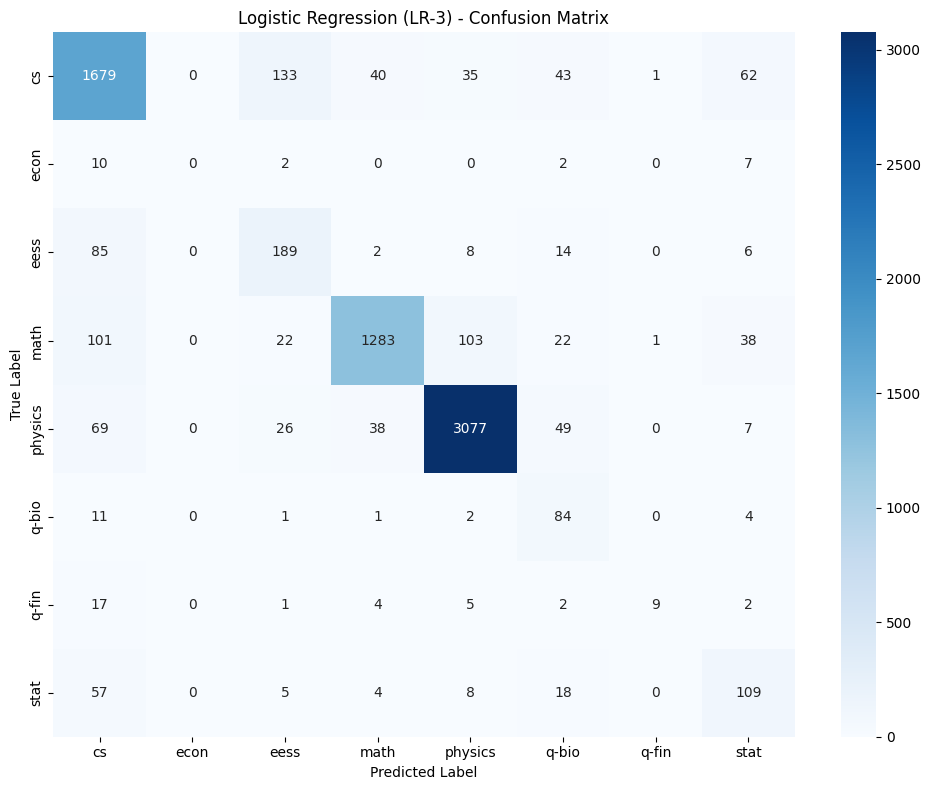

In [ ]:
lr_models = {

    "LR-1": lr_1,

    "LR-2": lr_2,

    "LR-3": lr_3
}
(
    best_lr_model,
    best_lr_config,
    best_lr_val_f1,
    lr_tuning_df
) = select_best_classical_model(
    "Logistic Regression",
    lr_models
)
lr_final_result = evaluate_final_model(
    model=best_lr_model,
    X_test_data=X_test_tfidf,
    y_test_data=y_test,
    model_name=f"Logistic Regression ({best_lr_config})",
    representation="TF-IDF",
    configuration=best_lr_config
)

Naive Bayes HYPERPARAMETER TUNING RESULTS


,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Naive Bayes,TF-IDF,NB-1,{'alpha': 0.1},0.861030,0.547336
1,Naive Bayes,TF-IDF,NB-2,{'alpha': 0.5},0.841424,0.349677
2,Naive Bayes,TF-IDF,NB-3,{'alpha': 1.0},0.838090,0.326001



Best Configuration:
NB-1

Best Validation Accuracy:
0.861

Best Validation Macro F1:
0.5473
FINAL TEST EVALUATION: Naive Bayes (NB-1)
Best Configuration: NB-1
Representation: TF-IDF
Test Accuracy: 0.8605
Test Macro F1: 0.5331
Test Weighted F1: 0.8541

Classification Report:

              precision    recall  f1-score   support

          cs     0.7760    0.9037    0.8350      1993
        econ     0.0000    0.0000    0.0000        21
        eess     0.5743    0.3816    0.4585       304
        math     0.8392    0.8975    0.8673      1570
     physics     0.9695    0.9155    0.9417      3266
       q-bio     0.7451    0.3689    0.4935       103
       q-fin     1.0000    0.0750    0.1395        40
        stat     0.6013    0.4726    0.5292       201

    accuracy                         0.8605      7498
   macro avg     0.6882    0.5018    0.5331      7498
weighted avg     0.8592    0.8605    0.8541      7498



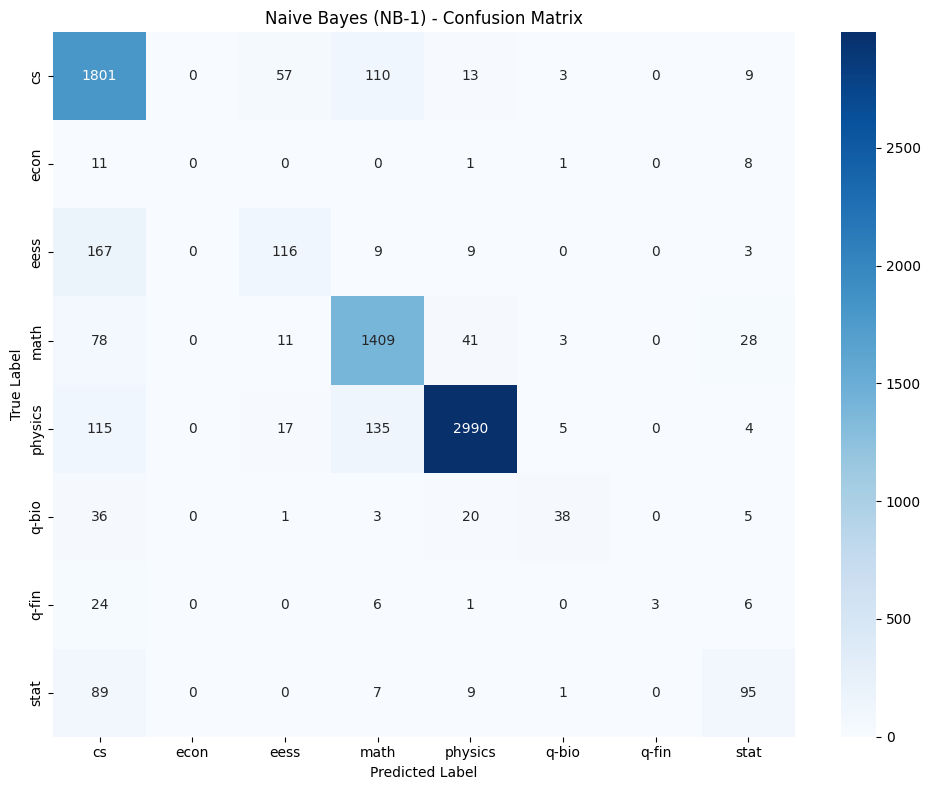

In [ ]:
nb_models = {

    "NB-1": nb_1,

    "NB-2": nb_2,

    "NB-3": nb_3
}
(
    best_nb_model,
    best_nb_config,
    best_nb_val_f1,
    nb_tuning_df
) = select_best_classical_model(
    "Naive Bayes",
    nb_models
)
nb_final_result = evaluate_final_model(
    model=best_nb_model,
    X_test_data=X_test_tfidf,
    y_test_data=y_test,
    model_name=f"Naive Bayes ({best_nb_config})",
    representation="TF-IDF",
    configuration=best_nb_config
)

Random Forest HYPERPARAMETER TUNING RESULTS


,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Random Forest,TF-IDF,RF-2,"{'n_estimators': 150, 'max_depth': 30, 'min_sa...",0.793278,0.546527
1,Random Forest,TF-IDF,RF-1,"{'n_estimators': 100, 'max_depth': 20, 'min_sa...",0.760469,0.543148
2,Random Forest,TF-IDF,RF-3,"{'n_estimators': 200, 'max_depth': 40, 'min_sa...",0.805548,0.508368



Best Configuration:
RF-2

Best Validation Accuracy:
0.7933

Best Validation Macro F1:
0.5465
FINAL TEST EVALUATION: Random Forest (RF-2)
Best Configuration: RF-2
Representation: TF-IDF
Test Accuracy: 0.7923
Test Macro F1: 0.5459
Test Weighted F1: 0.7918

Classification Report:

              precision    recall  f1-score   support

          cs     0.7707    0.7321    0.7509      1993
        econ     0.0000    0.0000    0.0000        21
        eess     0.3452    0.3520    0.3485       304
        math     0.7230    0.8561    0.7839      1570
     physics     0.9232    0.8803    0.9013      3266
       q-bio     0.5909    0.3786    0.4615       103
       q-fin     0.6522    0.7500    0.6977        40
        stat     0.4143    0.4328    0.4234       201

    accuracy                         0.7923      7498
   macro avg     0.5524    0.5477    0.5459      7498
weighted avg     0.7951    0.7923    0.7918      7498



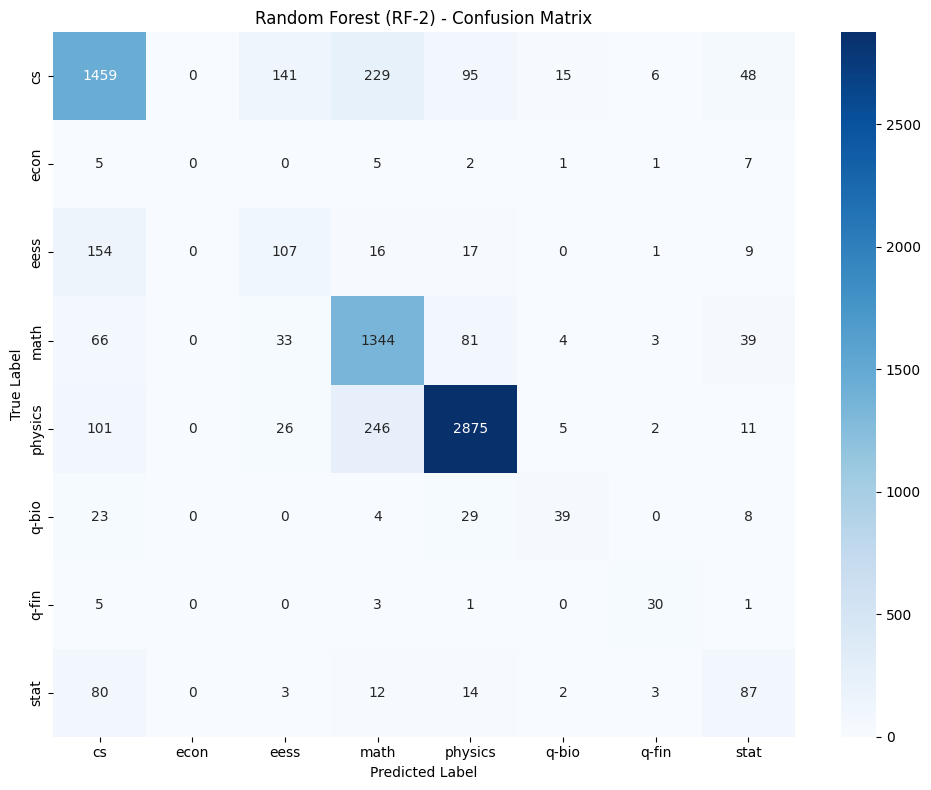

In [ ]:
rf_models = {

    "RF-1": rf_1,

    "RF-2": rf_2,

    "RF-3": rf_3
}
(
    best_rf_model,
    best_rf_config,
    best_rf_val_f1,
    rf_tuning_df
) = select_best_classical_model(
    "Random Forest",
    rf_models
)
rf_final_result = evaluate_final_model(
    model=best_rf_model,
    X_test_data=X_test_tfidf,
    y_test_data=y_test,
    model_name=f"Random Forest ({best_rf_config})",
    representation="TF-IDF",
    configuration=best_rf_config
)

In [ ]:
all_classical_tuning_results = pd.concat(
    [
        lr_tuning_df,
        nb_tuning_df,
        rf_tuning_df
    ],
    ignore_index=True
)

all_classical_tuning_results = (
    all_classical_tuning_results
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)
display(
    all_classical_tuning_results
)
all_classical_tuning_results.to_csv(
    "classical_hyperparameter_tuning.csv",
    index=False
)

,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Logistic Regression,TF-IDF,LR-3,"{'C': 4.0, 'solver': 'saga', 'max_iter': 1000,...",0.856095,0.574648
1,Logistic Regression,TF-IDF,LR-2,"{'C': 2.0, 'solver': 'saga', 'max_iter': 1000,...",0.831422,0.571340
2,Naive Bayes,TF-IDF,NB-1,{'alpha': 0.1},0.861030,0.547336
3,Random Forest,TF-IDF,RF-2,"{'n_estimators': 150, 'max_depth': 30, 'min_sa...",0.793278,0.546527
4,Random Forest,TF-IDF,RF-1,"{'n_estimators': 100, 'max_depth': 20, 'min_sa...",0.760469,0.543148
5,Random Forest,TF-IDF,RF-3,"{'n_estimators': 200, 'max_depth': 40, 'min_sa...",0.805548,0.508368
6,Logistic Regression,TF-IDF,LR-1,"{'C': 1.0, 'solver': 'saga', 'max_iter': 1000,...",0.776874,0.486000
7,Naive Bayes,TF-IDF,NB-2,{'alpha': 0.5},0.841424,0.349677
8,Naive Bayes,TF-IDF,NB-3,{'alpha': 1.0},0.838090,0.326001


In [ ]:
best_classical_models_df = (
    all_classical_tuning_results
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .groupby(
        "model",
        as_index=False
    )
    .first()
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print("=" * 70)
print("BEST CLASSICAL MODEL CONFIGURATIONS")
print("=" * 70)

display(
    best_classical_models_df
)

BEST CLASSICAL MODEL CONFIGURATIONS


,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Logistic Regression,TF-IDF,LR-3,"{'C': 4.0, 'solver': 'saga', 'max_iter': 1000,...",0.856095,0.574648
1,Naive Bayes,TF-IDF,NB-1,{'alpha': 0.1},0.861030,0.547336
2,Random Forest,TF-IDF,RF-2,"{'n_estimators': 150, 'max_depth': 30, 'min_sa...",0.793278,0.546527


Visualization

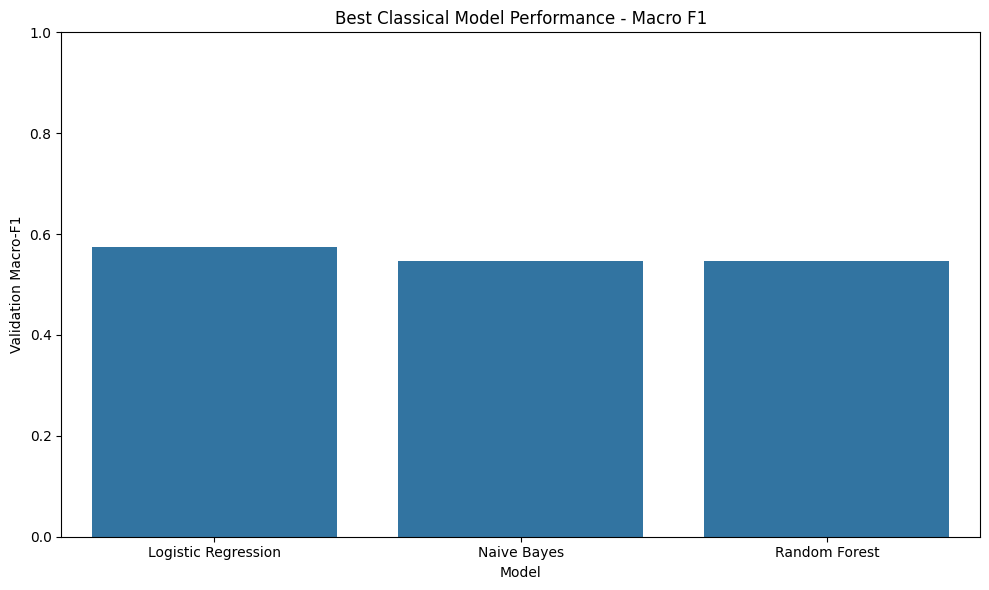

In [ ]:
best_classical_plot = best_classical.copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=best_classical_plot,
    x="model",
    y="validation_macro_f1"
)

plt.title(
    "Best Classical Model Performance - Macro F1"
)

plt.xlabel("Model")
plt.ylabel("Validation Macro-F1")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Saving Results

In [ ]:
tuning_df.to_csv(
    "classical_tuning_results.csv",
    index=False
)

print(
    "Saved: classical_tuning_results.csv"
)

best_classical.to_csv(
    "best_classical_models.csv",
    index=False
)

print(
    "Saved: best_classical_models.csv"
)

Saved: classical_tuning_results.csv
Saved: best_classical_models.csv


# Word2Vec Representation

Tokenization

In [ ]:
train_tokens = [
    text.split()
    for text in X_train_clean
]

val_tokens = [
    text.split()
    for text in X_val_clean
]

test_tokens = [
    text.split()
    for text in X_test_clean
]

print("Training documents:", len(train_tokens))
print("Validation documents:", len(val_tokens))
print("Test documents:", len(test_tokens))

print("\nExample tokens:")
print(train_tokens[0][:30])

Training documents: 34990
Validation documents: 7498
Test documents: 7498

Example tokens:
['characterising', 'the', 'correlations', 'of', 'prepare-and-measure', 'quantum', 'networks', 'prepare-and-measure', '(p&m)', 'quantum', 'networks', 'are', 'the', 'basic', 'building', 'blocks', 'of', 'quantum', 'communication', 'and', 'cryptography.', 'these', 'networks', 'crucially', 'rely', 'on', 'non-orthogonal', 'quantum', 'encodings', 'to']


Vocabulary Size

In [ ]:
from collections import Counter

word_counter = Counter(
    word
    for document in train_tokens
    for word in document
)

print("Unique training vocabulary:", len(word_counter))

print("\nMost common 30 words:")
print(
    word_counter.most_common(30)
)

Unique training vocabulary: 219117

Most common 30 words:
[('the', 368513), ('of', 231332), ('and', 147060), ('a', 138235), ('in', 120203), ('to', 114690), ('we', 80806), ('for', 71727), ('is', 68644), ('with', 52583), ('that', 52434), ('on', 45306), ('this', 39337), ('by', 35686), ('are', 35558), ('as', 31184), ('an', 29127), ('from', 24629), ('be', 22675), ('which', 21562), ('can', 19146), ('at', 18724), ('our', 17618), ('model', 14393), ('using', 13774), ('it', 12603), ('these', 12322), ('show', 12161), ('data', 11722), ('results', 11512)]


Train Word2Vec

In [ ]:
from gensim.models import Word2Vec
import multiprocessing

w2v_workers = max(
    1,
    multiprocessing.cpu_count() - 1
)

print("Training Word2Vec...")
print("Workers:", w2v_workers)

word2vec_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    workers=w2v_workers,
    sg=1,
    negative=5,
    epochs=10,
    seed=SEED
)

print("\nWord2Vec training completed.")

print(
    "Vocabulary size:",
    len(word2vec_model.wv)
)

print(
    "Embedding dimension:",
    word2vec_model.wv.vector_size
)

Training Word2Vec...
Workers: 1

Word2Vec training completed.
Vocabulary size: 61096
Embedding dimension: 100


Test Word2Vec Embedding

In [ ]:
test_words = [
    "model",
    "data",
    "physics",
    "quantum",
    "neural",
    "algorithm",
    "protein"
]

for word in test_words:
    if word in word2vec_model.wv:
        print(
            f"{word:12s} -> available"
        )
    else:
        print(
            f"{word:12s} -> OOV"
        )

model        -> available
data         -> available
physics      -> available
quantum      -> available
neural       -> available
algorithm    -> available
protein      -> available


In [ ]:
for word in ["physics", "neural", "algorithm"]:

    if word in word2vec_model.wv:

        print(
            f"\nSimilar words to '{word}':"
        )

        print(
            word2vec_model.wv.most_similar(
                word,
                topn=10
            )
        )


Similar words to 'physics':
[('physics,', 0.7834417819976807), ('astroparticle', 0.7551778554916382), ('physics.', 0.7513679265975952), ('clic', 0.7364141345024109), ('astrophysics,', 0.7215235233306885), ('(hep)', 0.7167902588844299), ('(sm).', 0.7053145170211792), ('astrophysics.', 0.6946488618850708), ('introductory', 0.6794701814651489), ('four-top', 0.6785727143287659)]

Similar words to 'neural':
[('convolutional', 0.8871534466743469), ('(dnn)', 0.8632710576057434), ('recurrent', 0.834402859210968), ('(rnn)', 0.8260776400566101), ('(rnns),', 0.8229251503944397), ('(cnn),', 0.8208014965057373), ('(cnns),', 0.8162468671798706), ('networks', 0.8121196031570435), ('(rnns).', 0.8120338320732117), ('(anns),', 0.809166669845581)]

Similar words to 'algorithm':
[('algorithm,', 0.8250243663787842), ('algorithms', 0.7799127697944641), ('method', 0.7629972100257874), ('strategy', 0.7194297909736633), ('algorithm.', 0.7118299007415771), ('procedure', 0.7104982137680054), ('greedy', 0.700402

Save Word2Vec

In [ ]:
word2vec_model.save(
    "arxiv_word2vec_100d.model"
)

print(
    "Saved: arxiv_word2vec_100d.model"
)

Saved: arxiv_word2vec_100d.model


Word2Vec for Neural Networks

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_VOCAB_SIZE = 50000

tokenizer = Tokenizer(
    num_words=MAX_VOCAB_SIZE,
    oov_token="<OOV>",
    lower=False,
    filters=""
)

tokenizer.fit_on_texts(
    X_train_clean
)

word_index = tokenizer.word_index

print(
    "Tokenizer vocabulary:",
    len(word_index)
)

print("\nFirst 20 vocabulary entries:")

for word, index in list(word_index.items())[:20]:
    print(index, "->", word)

Tokenizer vocabulary: 219118

First 20 vocabulary entries:
1 -> <OOV>
2 -> the
3 -> of
4 -> and
5 -> a
6 -> in
7 -> to
8 -> we
9 -> for
10 -> is
11 -> with
12 -> that
13 -> on
14 -> this
15 -> by
16 -> are
17 -> as
18 -> an
19 -> from
20 -> be


Sequence Length

In [ ]:
MAX_SEQUENCE_LENGTH = 250

print(
    "Maximum sequence length:",
    MAX_SEQUENCE_LENGTH
)

Maximum sequence length: 250


Convert text into sequences

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(
    X_train_clean
)

X_val_seq = tokenizer.texts_to_sequences(
    X_val_clean
)

X_test_seq = tokenizer.texts_to_sequences(
    X_test_clean
)

print("Example sequence:")
print(X_train_seq[0][:30])

Example sequence:
[10014, 2, 882, 3, 22261, 46, 109, 22261, 1, 46, 109, 16, 2, 982, 1115, 2289, 3, 46, 496, 4, 23768, 28, 109, 8236, 1468, 13, 7196, 46, 10390, 7]


Pad Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train_pad.shape)
print("Validation shape:", X_val_pad.shape)
print("Test shape:", X_test_pad.shape)

Training shape: (34990, 250)
Validation shape: (7498, 250)
Test shape: (7498, 250)


Word2Vec Embedding Matrix

In [ ]:
EMBEDDING_DIM = 100

embedding_matrix = np.zeros(
    (
        MAX_VOCAB_SIZE + 1,
        EMBEDDING_DIM
    ),
    dtype=np.float32
)

found_words = 0

for word, index in word_index.items():

    if index > MAX_VOCAB_SIZE:
        continue

    if word in word2vec_model.wv:
        embedding_matrix[index] = (
            word2vec_model.wv[word]
        )
        found_words += 1

print(
    "Embedding matrix shape:",
    embedding_matrix.shape
)

print(
    "Words found in Word2Vec:",
    found_words
)

print(
    "Coverage:",
    f"{found_words / min(len(word_index), MAX_VOCAB_SIZE) * 100:.2f}%"
)

Embedding matrix shape: (50001, 100)
Words found in Word2Vec: 49999
Coverage: 100.00%


Verify Embedding Matrix

In [ ]:
nonzero_rows = np.sum(
    np.any(
        embedding_matrix != 0,
        axis=1
    )
)

print(
    "Non-zero embedding rows:",
    nonzero_rows
)

print(
    "Embedding dimension:",
    embedding_matrix.shape[1]
)

Non-zero embedding rows: 49999
Embedding dimension: 100


In [ ]:
print(
    "\nSample embedding for first known word:"
)

for word, index in word_index.items():

    if index <= MAX_VOCAB_SIZE and word in word2vec_model.wv:
        print("Word:", word)
        print("Index:", index)
        print(
            "Vector:",
            embedding_matrix[index][:20]
        )
        break


Sample embedding for first known word:
Word: the
Index: 2
Vector: [-0.25524428 -0.18902393 -0.09510826  0.22730811  0.14676023  0.25297645
 -0.02722349  0.06162272  0.09602699 -0.44493663 -0.04978538  0.33630708
  0.23145346  0.01562664 -0.18839522 -0.13326788 -0.18413565 -0.429747
  0.0006223  -0.14864032]


Controlled Word2Vec Classical Model Experiment

In [ ]:
def document_vector(
    tokens,
    model,
    vector_size=100
):

    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(
            vector_size,
            dtype=np.float32
        )

    return np.mean(
        vectors,
        axis=0
    )

document vectors

In [ ]:
print("Creating Word2Vec document representations...")

X_train_w2v = np.vstack([
    document_vector(
        tokens,
        word2vec_model,
        EMBEDDING_DIM
    )
    for tokens in train_tokens
])

X_val_w2v = np.vstack([
    document_vector(
        tokens,
        word2vec_model,
        EMBEDDING_DIM
    )
    for tokens in val_tokens
])

X_test_w2v = np.vstack([
    document_vector(
        tokens,
        word2vec_model,
        EMBEDDING_DIM
    )
    for tokens in test_tokens
])

print(
    "Training shape:",
    X_train_w2v.shape
)

print(
    "Validation shape:",
    X_val_w2v.shape
)

print(
    "Test shape:",
    X_test_w2v.shape
)

Creating Word2Vec document representations...
Training shape: (34990, 100)
Validation shape: (7498, 100)
Test shape: (7498, 100)


Word2Vec Logistic Regression Configuration 1

In [ ]:
w2v_lr_config_1 = {
    "C": 0.5,
    "max_iter": 1000,
    "class_weight": "balanced"
}

w2v_lr_1 = LogisticRegression(
    **w2v_lr_config_1
)

print(
    "Training Word2Vec + Logistic Regression 1..."
)

w2v_lr_1.fit(
    X_train_w2v,
    y_train
)

w2v_lr_pred_1 = w2v_lr_1.predict(
    X_val_w2v
)

w2v_lr_result_1 = evaluate_model(
    model_name="Logistic Regression",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=w2v_lr_pred_1,
    split="validation",
    configuration="W2V-LR-1"
)

record_tuning_result(
    model="Logistic Regression",
    representation="Word2Vec",
    configuration="W2V-LR-1",
    hyperparameters=w2v_lr_config_1,
    validation_accuracy=w2v_lr_result_1["accuracy"],
    validation_macro_f1=w2v_lr_result_1["macro_f1"]
)

Training Word2Vec + Logistic Regression 1...

Logistic Regression | Word2Vec
Accuracy       : 0.8003
Macro Precision: 0.5195
Macro Recall   : 0.7402
Macro F1       : 0.5624
Weighted F1    : 0.8247

Classification Report:
              precision    recall  f1-score   support

          cs       0.91      0.64      0.75      1994
        econ       0.08      0.60      0.14        20
        eess       0.33      0.69      0.45       305
        math       0.86      0.87      0.87      1569
     physics       0.98      0.88      0.93      3266
       q-bio       0.27      0.82      0.41       102
       q-fin       0.35      0.68      0.46        41
        stat       0.38      0.73      0.50       201

    accuracy                           0.80      7498
   macro avg       0.52      0.74      0.56      7498
weighted avg       0.88      0.80      0.82      7498



Word2Vec Logistic Regression Configuration 2

In [ ]:
w2v_lr_config_2 = {
    "C": 1.0,
    "max_iter": 1000,
    "class_weight": "balanced"
}

w2v_lr_2 = LogisticRegression(
    **w2v_lr_config_2
)

print(
    "Training Word2Vec + Logistic Regression 2..."
)

w2v_lr_2.fit(
    X_train_w2v,
    y_train
)

w2v_lr_pred_2 = w2v_lr_2.predict(
    X_val_w2v
)

w2v_lr_result_2 = evaluate_model(
    model_name="Logistic Regression",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=w2v_lr_pred_2,
    split="validation",
    configuration="W2V-LR-2"
)

record_tuning_result(
    model="Logistic Regression",
    representation="Word2Vec",
    configuration="W2V-LR-2",
    hyperparameters=w2v_lr_config_2,
    validation_accuracy=w2v_lr_result_2["accuracy"],
    validation_macro_f1=w2v_lr_result_2["macro_f1"]
)

Training Word2Vec + Logistic Regression 2...

Logistic Regression | Word2Vec
Accuracy       : 0.8011
Macro Precision: 0.5174
Macro Recall   : 0.7340
Macro F1       : 0.5597
Weighted F1    : 0.8253

Classification Report:
              precision    recall  f1-score   support

          cs       0.90      0.64      0.75      1994
        econ       0.08      0.60      0.14        20
        eess       0.33      0.69      0.45       305
        math       0.86      0.87      0.87      1569
     physics       0.98      0.88      0.93      3266
       q-bio       0.28      0.81      0.41       102
       q-fin       0.33      0.63      0.43        41
        stat       0.37      0.74      0.50       201

    accuracy                           0.80      7498
   macro avg       0.52      0.73      0.56      7498
weighted avg       0.88      0.80      0.83      7498



Word2Vec Logistic Regression Configuration 3

In [ ]:
w2v_lr_config_3 = {
    "C": 2.0,
    "max_iter": 1000,
    "class_weight": "balanced"
}

w2v_lr_3 = LogisticRegression(
    **w2v_lr_config_3
)

print(
    "Training Word2Vec + Logistic Regression 3..."
)

w2v_lr_3.fit(
    X_train_w2v,
    y_train
)

w2v_lr_pred_3 = w2v_lr_3.predict(
    X_val_w2v
)

w2v_lr_result_3 = evaluate_model(
    model_name="Logistic Regression",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=w2v_lr_pred_3,
    split="validation",
    configuration="W2V-LR-3"
)

record_tuning_result(
    model="Logistic Regression",
    representation="Word2Vec",
    configuration="W2V-LR-3",
    hyperparameters=w2v_lr_config_3,
    validation_accuracy=w2v_lr_result_3["accuracy"],
    validation_macro_f1=w2v_lr_result_3["macro_f1"]
)

Training Word2Vec + Logistic Regression 3...

Logistic Regression | Word2Vec
Accuracy       : 0.8031
Macro Precision: 0.5173
Macro Recall   : 0.7351
Macro F1       : 0.5604
Weighted F1    : 0.8268

Classification Report:
              precision    recall  f1-score   support

          cs       0.90      0.64      0.75      1994
        econ       0.08      0.60      0.14        20
        eess       0.34      0.69      0.46       305
        math       0.86      0.87      0.86      1569
     physics       0.98      0.89      0.93      3266
       q-bio       0.28      0.81      0.42       102
       q-fin       0.32      0.63      0.42        41
        stat       0.37      0.75      0.49       201

    accuracy                           0.80      7498
   macro avg       0.52      0.74      0.56      7498
weighted avg       0.88      0.80      0.83      7498



Compare Word2Vec Comparison

In [ ]:
w2v_results = (
    pd.DataFrame(tuning_results)
    .query("representation == 'Word2Vec'")
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
)

print(
    w2v_results.to_string(
        index=False
    )
)

              model representation configuration                                          hyperparameters  validation_accuracy  validation_macro_f1
Logistic Regression       Word2Vec      W2V-LR-1 {'C': 0.5, 'max_iter': 1000, 'class_weight': 'balanced'}             0.800347             0.562408
Logistic Regression       Word2Vec      W2V-LR-3 {'C': 2.0, 'max_iter': 1000, 'class_weight': 'balanced'}             0.803148             0.560435
Logistic Regression       Word2Vec      W2V-LR-2 {'C': 1.0, 'max_iter': 1000, 'class_weight': 'balanced'}             0.801147             0.559700


Save Word2Vec Stage

In [ ]:
np.save(
    "X_train_w2v.npy",
    X_train_w2v
)

np.save(
    "X_val_w2v.npy",
    X_val_w2v
)

np.save(
    "X_test_w2v.npy",
    X_test_w2v
)

np.save(
    "embedding_matrix_word2vec.npy",
    embedding_matrix
)

print("Word2Vec representations saved.")

Word2Vec representations saved.


# GloVe Representation

Load GloVe Embeddings

In [ ]:
import numpy as np

glove_path = "glove.twitter.27B.100d.txt"

glove_embeddings = {}

print("Loading GloVe...")

with open(
    glove_path,
    "r",
    encoding="utf-8"
) as f:

    for line in f:

        values = line.rstrip().split(" ")

        word = values[0]

        vector = np.asarray(
            values[1:],
            dtype=np.float32
        )

        glove_embeddings[word] = vector

print(
    "GloVe vocabulary:",
    len(glove_embeddings)
)

print(
    "GloVe dimension:",
    len(next(iter(glove_embeddings.values())))
)

Loading GloVe...
GloVe vocabulary: 1193514
GloVe dimension: 100


Check GloVe Coverage

In [ ]:
glove_found = 0
glove_total = 0

for word, index in word_index.items():

    if index > MAX_VOCAB_SIZE:
        continue

    glove_total += 1

    if word in glove_embeddings:
        glove_found += 1

print(
    "Vocabulary checked:",
    glove_total
)

print(
    "Words found:",
    glove_found
)

print(
    "Coverage:",
    f"{glove_found / glove_total * 100:.2f}%"
)

Vocabulary checked: 50000
Words found: 17266
Coverage: 34.53%


GloVe Embedding Matrix

In [ ]:
GLOVE_DIM = 100

glove_embedding_matrix = np.zeros(
    (
        MAX_VOCAB_SIZE + 1,
        GLOVE_DIM
    ),
    dtype=np.float32
)

glove_found = 0

for word, index in word_index.items():

    if index > MAX_VOCAB_SIZE:
        continue

    if word in glove_embeddings:

        glove_embedding_matrix[index] = (
            glove_embeddings[word]
        )

        glove_found += 1

print(
    "GloVe embedding matrix:",
    glove_embedding_matrix.shape
)

print(
    "Words found:",
    glove_found
)

print(
    "Coverage:",
    f"{glove_found / glove_total * 100:.2f}%"
)

GloVe embedding matrix: (50001, 100)
Words found: 17266
Coverage: 34.53%


Save GloVe Matrix

In [ ]:
np.save(
    "embedding_matrix_glove_100d.npy",
    glove_embedding_matrix
)

print(
    "Saved: embedding_matrix_glove_100d.npy"
)

Saved: embedding_matrix_glove_100d.npy


GloVe Document Representations

In [ ]:
def document_vector_glove(
    tokens,
    embeddings,
    vector_size=100
):

    vectors = [
        embeddings[word]
        for word in tokens
        if word in embeddings
    ]

    if len(vectors) == 0:
        return np.zeros(
            vector_size,
            dtype=np.float32
        )

    return np.mean(
        vectors,
        axis=0
    )

In [ ]:
print(
    "Creating GloVe document representations..."
)

X_train_glove = np.vstack([
    document_vector_glove(
        tokens,
        glove_embeddings,
        GLOVE_DIM
    )
    for tokens in train_tokens
])

X_val_glove = np.vstack([
    document_vector_glove(
        tokens,
        glove_embeddings,
        GLOVE_DIM
    )
    for tokens in val_tokens
])

X_test_glove = np.vstack([
    document_vector_glove(
        tokens,
        glove_embeddings,
        GLOVE_DIM
    )
    for tokens in test_tokens
])

print(
    "Training:",
    X_train_glove.shape
)

print(
    "Validation:",
    X_val_glove.shape
)

print(
    "Test:",
    X_test_glove.shape
)

Creating GloVe document representations...
Training: (34990, 100)
Validation: (7498, 100)
Test: (7498, 100)


GloVe Logistic Regression Configuration 1

In [ ]:
glove_lr_config_1 = {
    "C": 0.5,
    "max_iter": 1000,
    "class_weight": "balanced"
}

glove_lr_1 = LogisticRegression(
    **glove_lr_config_1
)

print(
    "Training GloVe Logistic Regression 1..."
)

glove_lr_1.fit(
    X_train_glove,
    y_train
)

glove_pred_1 = glove_lr_1.predict(
    X_val_glove
)

glove_result_1 = evaluate_model(
    model_name="Logistic Regression",
    representation="GloVe",
    y_true=y_val,
    y_pred=glove_pred_1,
    split="validation",
    configuration="GLOVE-LR-1"
)

record_tuning_result(
    model="Logistic Regression",
    representation="GloVe",
    configuration="GLOVE-LR-1",
    hyperparameters=glove_lr_config_1,
    validation_accuracy=glove_result_1["accuracy"],
    validation_macro_f1=glove_result_1["macro_f1"]
)

Training GloVe Logistic Regression 1...

Logistic Regression | GloVe
Accuracy       : 0.6859
Macro Precision: 0.4302
Macro Recall   : 0.6158
Macro F1       : 0.4521
Weighted F1    : 0.7241

Classification Report:
              precision    recall  f1-score   support

          cs       0.84      0.54      0.65      1994
        econ       0.03      0.40      0.06        20
        eess       0.26      0.63      0.37       305
        math       0.73      0.76      0.74      1569
     physics       0.94      0.76      0.84      3266
       q-bio       0.19      0.65      0.29       102
       q-fin       0.20      0.59      0.30        41
        stat       0.26      0.61      0.36       201

    accuracy                           0.69      7498
   macro avg       0.43      0.62      0.45      7498
weighted avg       0.80      0.69      0.72      7498



GloVe Logistic Regression Configuration 2

In [ ]:
glove_lr_config_2 = {
    "C": 1.0,
    "max_iter": 1000,
    "class_weight": "balanced"
}

glove_lr_2 = LogisticRegression(
    **glove_lr_config_2
)

print(
    "Training GloVe Logistic Regression 2..."
)

glove_lr_2.fit(
    X_train_glove,
    y_train
)

glove_pred_2 = glove_lr_2.predict(
    X_val_glove
)

glove_result_2 = evaluate_model(
    model_name="Logistic Regression",
    representation="GloVe",
    y_true=y_val,
    y_pred=glove_pred_2,
    split="validation",
    configuration="GLOVE-LR-2"
)

record_tuning_result(
    model="Logistic Regression",
    representation="GloVe",
    configuration="GLOVE-LR-2",
    hyperparameters=glove_lr_config_2,
    validation_accuracy=glove_result_2["accuracy"],
    validation_macro_f1=glove_result_2["macro_f1"]
)

Training GloVe Logistic Regression 2...

Logistic Regression | GloVe
Accuracy       : 0.6871
Macro Precision: 0.4299
Macro Recall   : 0.6109
Macro F1       : 0.4517
Weighted F1    : 0.7249

Classification Report:
              precision    recall  f1-score   support

          cs       0.84      0.54      0.66      1994
        econ       0.03      0.35      0.05        20
        eess       0.27      0.65      0.38       305
        math       0.72      0.75      0.74      1569
     physics       0.93      0.76      0.84      3266
       q-bio       0.19      0.65      0.30       102
       q-fin       0.20      0.59      0.30        41
        stat       0.25      0.61      0.36       201

    accuracy                           0.69      7498
   macro avg       0.43      0.61      0.45      7498
weighted avg       0.80      0.69      0.72      7498



GloVe Logistic Regression Configuration 3

In [ ]:
glove_lr_config_3 = {
    "C": 2.0,
    "max_iter": 1000,
    "class_weight": "balanced"
}

glove_lr_3 = LogisticRegression(
    **glove_lr_config_3
)

print(
    "Training GloVe Logistic Regression 3..."
)

glove_lr_3.fit(
    X_train_glove,
    y_train
)

glove_pred_3 = glove_lr_3.predict(
    X_val_glove
)

glove_result_3 = evaluate_model(
    model_name="Logistic Regression",
    representation="GloVe",
    y_true=y_val,
    y_pred=glove_pred_3,
    split="validation",
    configuration="GLOVE-LR-3"
)

record_tuning_result(
    model="Logistic Regression",
    representation="GloVe",
    configuration="GLOVE-LR-3",
    hyperparameters=glove_lr_config_3,
    validation_accuracy=glove_result_3["accuracy"],
    validation_macro_f1=glove_result_3["macro_f1"]
)

Training GloVe Logistic Regression 3...

Logistic Regression | GloVe
Accuracy       : 0.6885
Macro Precision: 0.4290
Macro Recall   : 0.6121
Macro F1       : 0.4500
Weighted F1    : 0.7271

Classification Report:
              precision    recall  f1-score   support

          cs       0.84      0.54      0.66      1994
        econ       0.03      0.35      0.05        20
        eess       0.27      0.64      0.38       305
        math       0.73      0.75      0.74      1569
     physics       0.94      0.76      0.84      3266
       q-bio       0.19      0.67      0.30       102
       q-fin       0.18      0.59      0.28        41
        stat       0.25      0.60      0.36       201

    accuracy                           0.69      7498
   macro avg       0.43      0.61      0.45      7498
weighted avg       0.81      0.69      0.73      7498



Compare GloVe

In [ ]:
glove_results = (
    pd.DataFrame(tuning_results)
    .query("representation == 'GloVe'")
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
)

print(
    glove_results.to_string(
        index=False
    )
)

              model representation configuration                                          hyperparameters  validation_accuracy  validation_macro_f1
Logistic Regression          GloVe    GLOVE-LR-1 {'C': 0.5, 'max_iter': 1000, 'class_weight': 'balanced'}             0.685916             0.452056
Logistic Regression          GloVe    GLOVE-LR-2 {'C': 1.0, 'max_iter': 1000, 'class_weight': 'balanced'}             0.687117             0.451655
Logistic Regression          GloVe    GLOVE-LR-3 {'C': 2.0, 'max_iter': 1000, 'class_weight': 'balanced'}             0.688450             0.449987


Save GloVe Document vectors

In [ ]:
np.save(
    "X_train_glove.npy",
    X_train_glove
)

np.save(
    "X_val_glove.npy",
    X_val_glove
)

np.save(
    "X_test_glove.npy",
    X_test_glove
)

print(
    "GloVe representations saved."
)

GloVe representations saved.


Verify Tensorflow/GPU

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

print("TensorFlow:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

print("Available GPUs:", gpus)

if gpus:
    print("GPU is available.")
else:
    print("WARNING: No GPU detected.")

TensorFlow: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU is available.


In [ ]:
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(
            gpu,
            True
        )
    except:
        pass

Required Variable

In [ ]:
required_variables = [
    "X_train_pad",
    "X_val_pad",
    "X_test_pad",
    "y_train",
    "y_val",
    "y_test",
    "embedding_matrix",
    "class_weights"
]

for variable in required_variables:
    print(
        variable,
        "->",
        "OK" if variable in globals() else "MISSING"
    )

X_train_pad -> OK
X_val_pad -> OK
X_test_pad -> OK
y_train -> OK
y_val -> OK
y_test -> OK
embedding_matrix -> OK
class_weights -> OK


Verify Labels

In [ ]:
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("\nUnique labels:")
print(np.unique(y_train))

print("\nClass weights:")
for class_id, weight in class_weights.items():
    print(
        f"{class_id}: {weight:.4f}"
    )

y_train: (34990,)
y_val: (7498,)
y_test: (7498,)

Unique labels:
[0 1 2 3 4 5 6 7]

Class weights:
0: 0.4701
1: 46.0395
2: 3.0758
3: 0.5973
4: 0.2870
5: 9.1693
6: 23.2646
7: 4.6579


Validation Macro-F1 Callback

In [ ]:
from sklearn.metrics import f1_score
from tensorflow.keras.callbacks import Callback


class ValidationMacroF1(Callback):

    def __init__(
        self,
        validation_data
    ):
        super().__init__()

        self.X_val = validation_data[0]
        self.y_val = validation_data[1]

        self.macro_f1s = []

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):

        y_prob = self.model.predict(
            self.X_val,
            batch_size=256,
            verbose=0
        )

        y_pred = np.argmax(
            y_prob,
            axis=1
        )

        macro_f1 = f1_score(
            self.y_val,
            y_pred,
            average="macro",
            zero_division=0
        )

        self.macro_f1s.append(
            macro_f1
        )

        print(
            f" - val_macro_f1: {macro_f1:.4f}"
        )

In [ ]:
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score
import numpy as np


class MacroF1Checkpoint(Callback):

    def __init__(
        self,
        X_val,
        y_val,
        filepath,
        batch_size=256
    ):
        super().__init__()

        self.X_val = X_val
        self.y_val = y_val
        self.filepath = filepath
        self.batch_size = batch_size

        self.best_macro_f1 = -np.inf
        self.best_epoch = None

        self.history_macro_f1 = []

    def on_epoch_end(self, epoch, logs=None):

        y_prob = self.model.predict(
            self.X_val,
            batch_size=self.batch_size,
            verbose=0
        )

        y_pred = np.argmax(
            y_prob,
            axis=1
        )

        macro_f1 = f1_score(
            self.y_val,
            y_pred,
            average="macro",
            zero_division=0
        )

        self.history_macro_f1.append(
            macro_f1
        )

        if macro_f1 > self.best_macro_f1:

            self.best_macro_f1 = macro_f1
            self.best_epoch = epoch + 1

            self.model.save(
                self.filepath
            )

            print(
                f" - val_macro_f1: {macro_f1:.4f} "
                f"*** BEST ***"
            )

        else:

            print(
                f" - val_macro_f1: {macro_f1:.4f}"
            )

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

def create_callbacks(
    model_name
):

    checkpoint_path = (
        f"{model_name}_best.keras"
    )

    callbacks = [

        ValidationMacroF1(
            (
                X_val_pad,
                y_val
            )
        ),

        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=1
        ),

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1
        ),

        ModelCheckpoint(
            checkpoint_path,
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        )
    ]

    return callbacks

In [ ]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)


def create_macro_f1_callbacks(
    model_name
):

    checkpoint_path = (
        f"{model_name}_best.keras"
    )

    macro_f1_checkpoint = MacroF1Checkpoint(
        X_val_pad,
        y_val,
        checkpoint_path
    )

    callbacks = [

        macro_f1_checkpoint,

        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-6,
            verbose=1
        ),

        EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=False,
            verbose=1
        )
    ]

    return callbacks, macro_f1_checkpoint

Common Embedding Layer

In [ ]:
from tensorflow.keras.layers import Embedding

def create_word2vec_embedding():

    return Embedding(
        input_dim=MAX_VOCAB_SIZE + 1,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_SEQUENCE_LENGTH,
        trainable=False,
        mask_zero=True
    )

Six Architectures

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    SimpleRNN,
    GRU,
    LSTM,
    Bidirectional
)


def build_rnn_model(
    architecture,
    units=128,
    dropout=0.3
):

    model = Sequential(
        name=architecture
    )

    model.add(
        create_word2vec_embedding()
    )

    if architecture == "SimpleRNN":

        model.add(
            SimpleRNN(
                units,
                dropout=dropout,
                recurrent_dropout=0.0
            )
        )

    elif architecture == "GRU":

        model.add(
            GRU(
                units,
                dropout=dropout,
                recurrent_dropout=0.0
            )
        )

    elif architecture == "LSTM":

        model.add(
            LSTM(
                units,
                dropout=dropout,
                recurrent_dropout=0.0
            )
        )

    elif architecture == "BiSimpleRNN":

        model.add(
            Bidirectional(
                SimpleRNN(
                    units,
                    dropout=dropout
                )
            )
        )

    elif architecture == "BiGRU":

        model.add(
            Bidirectional(
                GRU(
                    units,
                    dropout=dropout
                )
            )
        )

    elif architecture == "BiLSTM":

        model.add(
            Bidirectional(
                LSTM(
                    units,
                    dropout=dropout
                )
            )
        )

    else:

        raise ValueError(
            f"Unknown architecture: {architecture}"
        )

    model.add(
        Dense(
            64,
            activation="relu"
        )
    )

    model.add(
        Dropout(dropout)
    )

    model.add(
        Dense(
            8,
            activation="softmax"
        )
    )

    return model

Compilation Function

In [ ]:
from tensorflow.keras.optimizers import Adam


def compile_rnn_model(
    model,
    learning_rate=0.001
):

    model.compile(

        optimizer=Adam(
            learning_rate=learning_rate
        ),

        loss="sparse_categorical_crossentropy",

        metrics=[
            "accuracy"
        ]
    )

    return model

# RNN Models

Testing the Architecture Builder

GRU

GRU Configuration 1

In [ ]:
tf.keras.backend.clear_session()

gru_1 = build_rnn_model(
    architecture="GRU",
    units=128,
    dropout=0.30
)

gru_1 = compile_rnn_model(
    gru_1,
    learning_rate=0.001
)

gru_callbacks_1, gru_f1_callback_1 = create_macro_f1_callbacks(
    "GRU_W2V_1"
)

print("=" * 60)
print("Training GRU Configuration 1")
print("=" * 60)

history_gru_1 = gru_1.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=gru_callbacks_1,
    verbose=1
)

gru_1_best = tf.keras.models.load_model(
    "GRU_W2V_1_best.keras"
)

gru_1_prob = gru_1_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

gru_1_pred = np.argmax(
    gru_1_prob,
    axis=1
)

gru_result_1 = evaluate_model(
    model_name="GRU",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=gru_1_pred,
    split="validation",
    configuration="W2V-GRU-1"
)

record_tuning_result(
    model="GRU",
    representation="Word2Vec",
    configuration="W2V-GRU-1",
    hyperparameters={
        "units": 128,
        "dropout": 0.30,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=gru_result_1["accuracy"],
    validation_macro_f1=gru_result_1["macro_f1"]
)

Training GRU Configuration 1
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3361 - loss: 1.9305 - val_macro_f1: 0.3189 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.4728 - loss: 1.7710 - val_accuracy: 0.6111 - val_loss: 1.1532 - learning_rate: 0.0010
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5814 - loss: 1.5148 - val_macro_f1: 0.2852

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5960 - loss: 1.4623 - val_accuracy: 0.4943 - val_loss: 1.2939 - learning_rate: 0.0010
Epoch 3/10
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6082 - loss: 1.2894 - val_macro_f1: 0.4496 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.6472 - loss: 1.2273 - val_accuracy: 0.7182 - val_loss: 0.8552 - learning_rate: 5.0000e-04
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6962 - loss: 1.0894 - val_macro_f1: 0.49

GRU Configuration 2

In [ ]:
tf.keras.backend.clear_session()

gru_2 = build_rnn_model(
    architecture="GRU",
    units=128,
    dropout=0.50
)

gru_2 = compile_rnn_model(
    gru_2,
    learning_rate=0.001
)

gru_callbacks_2, gru_f1_callback_2 = create_macro_f1_callbacks(
    "GRU_W2V_2"
)

print("=" * 60)
print("Training GRU Configuration 2")
print("=" * 60)

history_gru_2 = gru_2.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=gru_callbacks_2,
    verbose=1
)

gru_2_best = tf.keras.models.load_model(
    "GRU_W2V_2_best.keras"
)

gru_2_prob = gru_2_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

gru_2_pred = np.argmax(
    gru_2_prob,
    axis=1
)

gru_result_2 = evaluate_model(
    model_name="GRU",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=gru_2_pred,
    split="validation",
    configuration="W2V-GRU-2"
)

record_tuning_result(
    model="GRU",
    representation="Word2Vec",
    configuration="W2V-GRU-2",
    hyperparameters={
        "units": 128,
        "dropout": 0.50,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=gru_result_2["accuracy"],
    validation_macro_f1=gru_result_2["macro_f1"]
)

Training GRU Configuration 2
Epoch 1/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2916 - loss: 1.9569 - val_macro_f1: 0.3206 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.3878 - loss: 1.8987 - val_accuracy: 0.6352 - val_loss: 1.3955 - learning_rate: 0.0010
Epoch 2/10
272/274 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5246 - loss: 1.6995 - val_macro_f1: 0.3517 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.5318 - loss: 1.6499 - val_accuracy: 0.6448 - val_loss: 0.9076 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5521 - loss: 1.5961 - val_macro_f1: 0.4248 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5858 - loss: 1.5249 - val_accuracy: 0.7103 - val_loss: 0.8391 - learning_rate: 0.0010
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6181 - loss: 1.3876 - val_macro_f1: 0.4706 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy

GRU Configuration 3

In [ ]:
tf.keras.backend.clear_session()

gru_3 = build_rnn_model(
    architecture="GRU",
    units=256,
    dropout=0.30
)

gru_3 = compile_rnn_model(
    gru_3,
    learning_rate=0.0005
)

gru_callbacks_3, gru_f1_callback_3 = create_macro_f1_callbacks(
    "GRU_W2V_3"
)

print("=" * 60)
print("Training GRU Configuration 3")
print("=" * 60)

history_gru_3 = gru_3.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=gru_callbacks_3,
    verbose=1
)

gru_3_best = tf.keras.models.load_model(
    "GRU_W2V_3_best.keras"
)

gru_3_prob = gru_3_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

gru_3_pred = np.argmax(
    gru_3_prob,
    axis=1
)

gru_result_3 = evaluate_model(
    model_name="GRU",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=gru_3_pred,
    split="validation",
    configuration="W2V-GRU-3"
)

record_tuning_result(
    model="GRU",
    representation="Word2Vec",
    configuration="W2V-GRU-3",
    hyperparameters={
        "units": 256,
        "dropout": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 128
    },
    validation_accuracy=gru_result_3["accuracy"],
    validation_macro_f1=gru_result_3["macro_f1"]
)

Training GRU Configuration 3
Epoch 1/10
272/274 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4265 - loss: 2.0106 - val_macro_f1: 0.3554 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.5203 - loss: 1.7998 - val_accuracy: 0.6222 - val_loss: 1.1311 - learning_rate: 5.0000e-04
Epoch 2/10
272/274 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6048 - loss: 1.5289 - val_macro_f1: 0.4324 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.6141 - loss: 1.4996 - val_accuracy: 0.7446 - val_loss: 0.8091 - learning_rate: 5.0000e-04
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6469 - loss: 1.4057 - val_macro_f1: 0.4277

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.6461 - loss: 1.3776 - val_accuracy: 0.7254 - val_loss: 0.8245 - learning_rate: 5.0000e-04
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6712 - loss: 1.2422 - val_macro_

GRU Result

In [ ]:
tuning_df = pd.DataFrame(tuning_results)

gru_results = tuning_df[
    tuning_df["model"] == "GRU"
].sort_values(
    "validation_macro_f1",
    ascending=False
).copy()

print("=" * 60)
print("GRU CONFIGURATION RESULTS")
print("=" * 60)

print(gru_results.to_string(index=False))

best_gru_config = gru_results.iloc[0]

print("\n" + "=" * 60)
print("BEST GRU CONFIGURATION")
print("=" * 60)

print(best_gru_config.to_string())

GRU CONFIGURATION RESULTS
model representation configuration                                                            hyperparameters  validation_accuracy  validation_macro_f1
  GRU       Word2Vec     W2V-GRU-1  {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 128}             0.797813             0.568754
  GRU       Word2Vec     W2V-GRU-2  {'units': 128, 'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 128}             0.766204             0.541002
  GRU       Word2Vec     W2V-GRU-3 {'units': 256, 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 128}             0.758602             0.519106

BEST GRU CONFIGURATION
model                                                                GRU
representation                                                  Word2Vec
configuration                                                  W2V-GRU-1
hyperparameters        {'units': 128, 'dropout': 0.3, 'learning_rate'...
validation_accuracy                               

SimpleRNN Configuration 1

In [ ]:
tf.keras.backend.clear_session()

simple_rnn_1 = build_rnn_model(
    architecture="SimpleRNN",
    units=128,
    dropout=0.30
)

simple_rnn_1 = compile_rnn_model(
    simple_rnn_1,
    learning_rate=0.001
)

simple_rnn_callbacks_1, simple_rnn_f1_callback_1 = create_macro_f1_callbacks(
    "SimpleRNN_W2V_1"
)

print("=" * 60)
print("Training SimpleRNN Configuration 1")
print("=" * 60)

history_simple_rnn_1 = simple_rnn_1.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=simple_rnn_callbacks_1,
    verbose=1
)

simple_rnn_1_best = tf.keras.models.load_model(
    "SimpleRNN_W2V_1_best.keras"
)

simple_rnn_1_prob = simple_rnn_1_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

simple_rnn_1_pred = np.argmax(
    simple_rnn_1_prob,
    axis=1
)

simple_rnn_result_1 = evaluate_model(
    model_name="SimpleRNN",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=simple_rnn_1_pred,
    split="validation",
    configuration="W2V-SimpleRNN-1"
)

record_tuning_result(
    model="SimpleRNN",
    representation="Word2Vec",
    configuration="W2V-SimpleRNN-1",
    hyperparameters={
        "units": 128,
        "dropout": 0.30,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=simple_rnn_result_1["accuracy"],
    validation_macro_f1=simple_rnn_result_1["macro_f1"]
)

Training SimpleRNN Configuration 1
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2762 - loss: 2.0785 - val_macro_f1: 0.2759 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 43ms/step - accuracy: 0.3558 - loss: 1.9661 - val_accuracy: 0.6086 - val_loss: 1.4431 - learning_rate: 0.0010
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4884 - loss: 1.8027 - val_macro_f1: 0.2805 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5001 - loss: 1.7476 - val_accuracy: 0.5381 - val_loss: 1.3761 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5381 - loss: 1.6238 - val_macro_f1: 0.2895 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5247 - loss: 1.6421 - val_accuracy: 0.5367 - val_loss: 1.3688 - learning_rate: 0.0010
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4924 - loss: 1.6047 - val_macro_f1: 0.2395

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.000

SimpleRNN Configuration 2

In [ ]:
tf.keras.backend.clear_session()

simple_rnn_2 = build_rnn_model(
    architecture="SimpleRNN",
    units=128,
    dropout=0.50
)

simple_rnn_2 = compile_rnn_model(
    simple_rnn_2,
    learning_rate=0.001
)

simple_rnn_callbacks_2, simple_rnn_f1_callback_2 = create_macro_f1_callbacks(
    "SimpleRNN_W2V_2"
)

print("=" * 60)
print("Training SimpleRNN Configuration 2")
print("=" * 60)

history_simple_rnn_2 = simple_rnn_2.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=simple_rnn_callbacks_2,
    verbose=1
)

simple_rnn_2_best = tf.keras.models.load_model(
    "SimpleRNN_W2V_2_best.keras"
)

simple_rnn_2_prob = simple_rnn_2_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

simple_rnn_2_pred = np.argmax(
    simple_rnn_2_prob,
    axis=1
)

simple_rnn_result_2 = evaluate_model(
    model_name="SimpleRNN",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=simple_rnn_2_pred,
    split="validation",
    configuration="W2V-SimpleRNN-2"
)

record_tuning_result(
    model="SimpleRNN",
    representation="Word2Vec",
    configuration="W2V-SimpleRNN-2",
    hyperparameters={
        "units": 128,
        "dropout": 0.50,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=simple_rnn_result_2["accuracy"],
    validation_macro_f1=simple_rnn_result_2["macro_f1"]
)

Training SimpleRNN Configuration 2
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.1966 - loss: 2.0962 - val_macro_f1: 0.2313 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.2185 - loss: 2.0766 - val_accuracy: 0.4012 - val_loss: 1.8350 - learning_rate: 0.0010
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3211 - loss: 2.0059 - val_macro_f1: 0.2107
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.3268 - loss: 1.9781 - val_accuracy: 0.4920 - val_loss: 1.7309 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4061 - loss: 1.9518 - val_macro_f1: 0.2896 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.4107 - loss: 1.8706 - val_accuracy: 0.5363 - val_loss: 1.3665 - learning_rate: 0.0010
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4433 - loss: 1.8235 - val_macro_f1: 0.2867

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487

SimpleRNN Configuration 3

In [ ]:
tf.keras.backend.clear_session()

simple_rnn_3 = build_rnn_model(
    architecture="SimpleRNN",
    units=256,
    dropout=0.30
)

simple_rnn_3 = compile_rnn_model(
    simple_rnn_3,
    learning_rate=0.0005
)

simple_rnn_callbacks_3, simple_rnn_f1_callback_3 = create_macro_f1_callbacks(
    "SimpleRNN_W2V_3"
)

print("=" * 60)
print("Training SimpleRNN Configuration 3")
print("=" * 60)

history_simple_rnn_3 = simple_rnn_3.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=simple_rnn_callbacks_3,
    verbose=1
)

simple_rnn_3_best = tf.keras.models.load_model(
    "SimpleRNN_W2V_3_best.keras"
)

simple_rnn_3_prob = simple_rnn_3_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

simple_rnn_3_pred = np.argmax(
    simple_rnn_3_prob,
    axis=1
)

simple_rnn_result_3 = evaluate_model(
    model_name="SimpleRNN",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=simple_rnn_3_pred,
    split="validation",
    configuration="W2V-SimpleRNN-3"
)

record_tuning_result(
    model="SimpleRNN",
    representation="Word2Vec",
    configuration="W2V-SimpleRNN-3",
    hyperparameters={
        "units": 256,
        "dropout": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 128
    },
    validation_accuracy=simple_rnn_result_3["accuracy"],
    validation_macro_f1=simple_rnn_result_3["macro_f1"]
)

Training SimpleRNN Configuration 3
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.2316 - loss: 2.0971 - val_macro_f1: 0.2598 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.3039 - loss: 1.9955 - val_accuracy: 0.5393 - val_loss: 1.4999 - learning_rate: 5.0000e-04
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4566 - loss: 1.8011 - val_macro_f1: 0.3276 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.4950 - loss: 1.7275 - val_accuracy: 0.6576 - val_loss: 1.0917 - learning_rate: 5.0000e-04
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5055 - loss: 1.6524 - val_macro_f1: 0.2632

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.4528 - loss: 1.7074 - val_accuracy: 0.4362 - val_loss: 1.6140 - learning_rate: 5.0000e-04
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4719 - loss: 1.6458 - val_

SimpleRNN Result

In [ ]:
tuning_df = pd.DataFrame(tuning_results)

simple_rnn_results = tuning_df[
    tuning_df["model"] == "SimpleRNN"
].sort_values(
    "validation_macro_f1",
    ascending=False
).copy()


print("=" * 60)
print("SimpleRNN CONFIGURATION RESULTS")
print("=" * 60)

print(
    simple_rnn_results.to_string(index=False)
)


best_simple_rnn_config = simple_rnn_results.iloc[0]

print("\n" + "=" * 60)
print("BEST SimpleRNN CONFIGURATION")
print("=" * 60)

print(best_simple_rnn_config.to_string())

SimpleRNN CONFIGURATION RESULTS
    model representation   configuration                                                            hyperparameters  validation_accuracy  validation_macro_f1
SimpleRNN       Word2Vec W2V-SimpleRNN-1  {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 128}             0.666444             0.373396
SimpleRNN       Word2Vec W2V-SimpleRNN-3 {'units': 256, 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 128}             0.644038             0.340996
SimpleRNN       Word2Vec W2V-SimpleRNN-2  {'units': 128, 'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 128}             0.656308             0.340810

BEST SimpleRNN CONFIGURATION
model                                                          SimpleRNN
representation                                                  Word2Vec
configuration                                            W2V-SimpleRNN-1
hyperparameters        {'units': 128, 'dropout': 0.3, 'learning_rate'...
validation_acc

LSTM Configuration 1

In [ ]:
tf.keras.backend.clear_session()

lstm_1 = build_rnn_model(
    architecture="LSTM",
    units=128,
    dropout=0.30
)

lstm_1 = compile_rnn_model(
    lstm_1,
    learning_rate=0.001
)

lstm_callbacks_1, lstm_f1_callback_1 = create_macro_f1_callbacks(
    "LSTM_W2V_1"
)

print("=" * 60)
print("Training LSTM Configuration 1")
print("=" * 60)

history_lstm_1 = lstm_1.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=lstm_callbacks_1,
    verbose=1
)

lstm_1_best = tf.keras.models.load_model(
    "LSTM_W2V_1_best.keras"
)

lstm_1_prob = lstm_1_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

lstm_1_pred = np.argmax(
    lstm_1_prob,
    axis=1
)

lstm_result_1 = evaluate_model(
    model_name="LSTM",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=lstm_1_pred,
    split="validation",
    configuration="W2V-LSTM-1"
)

record_tuning_result(
    model="LSTM",
    representation="Word2Vec",
    configuration="W2V-LSTM-1",
    hyperparameters={
        "units": 128,
        "dropout": 0.30,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=lstm_result_1["accuracy"],
    validation_macro_f1=lstm_result_1["macro_f1"]
)

Training LSTM Configuration 1
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4937 - loss: 1.8647 - val_macro_f1: 0.2792 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.5173 - loss: 1.7652 - val_accuracy: 0.5204 - val_loss: 1.3353 - learning_rate: 0.0010
Epoch 2/10
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5727 - loss: 1.6491 - val_macro_f1: 0.2961 *** BEST ***

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5896 - loss: 1.5742 - val_accuracy: 0.4885 - val_loss: 1.5543 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6184 - loss: 1.4072 - val_macro_f1: 0.4326 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.6396 - loss: 1.3990 - val_accuracy: 0.7086 - val_loss: 0.8257 - learning_rate: 5.0000e-04
Epoch 4/10
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6804 - loss: 1.3112 - val_m

LSTM Configuration 2

In [ ]:
tf.keras.backend.clear_session()

lstm_2 = build_rnn_model(
    architecture="LSTM",
    units=128,
    dropout=0.50
)

lstm_2 = compile_rnn_model(
    lstm_2,
    learning_rate=0.001
)

lstm_callbacks_2, lstm_f1_callback_2 = create_macro_f1_callbacks(
    "LSTM_W2V_2"
)

print("=" * 60)
print("Training LSTM Configuration 2")
print("=" * 60)

history_lstm_2 = lstm_2.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=lstm_callbacks_2,
    verbose=1
)

lstm_2_best = tf.keras.models.load_model(
    "LSTM_W2V_2_best.keras"
)

lstm_2_prob = lstm_2_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

lstm_2_pred = np.argmax(
    lstm_2_prob,
    axis=1
)

lstm_result_2 = evaluate_model(
    model_name="LSTM",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=lstm_2_pred,
    split="validation",
    configuration="W2V-LSTM-2"
)

record_tuning_result(
    model="LSTM",
    representation="Word2Vec",
    configuration="W2V-LSTM-2",
    hyperparameters={
        "units": 128,
        "dropout": 0.50,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=lstm_result_2["accuracy"],
    validation_macro_f1=lstm_result_2["macro_f1"]
)

Training LSTM Configuration 2
Epoch 1/10
272/274 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.3403 - loss: 1.9656 - val_macro_f1: 0.3331 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.4315 - loss: 1.8463 - val_accuracy: 0.6460 - val_loss: 1.0538 - learning_rate: 0.0010
Epoch 2/10
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5010 - loss: 1.7395 - val_macro_f1: 0.3710 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.4760 - loss: 1.7057 - val_accuracy: 0.6466 - val_loss: 1.0086 - learning_rate: 0.0010
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5297 - loss: 1.7228 - val_macro_f1: 0.3831 *** BEST ***

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.5272 - loss: 1.6733 - val_accuracy: 0.7094 - val_loss: 1.0397 - learning_rate: 0.0010
Epoch 4/10
271/274 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5828 - loss: 1.5615 - val_macro

LSTM Configuration 3

In [ ]:
tf.keras.backend.clear_session()

lstm_3 = build_rnn_model(
    architecture="LSTM",
    units=256,
    dropout=0.30
)

lstm_3 = compile_rnn_model(
    lstm_3,
    learning_rate=0.0005
)

lstm_callbacks_3, lstm_f1_callback_3 = create_macro_f1_callbacks(
    "LSTM_W2V_3"
)

print("=" * 60)
print("Training LSTM Configuration 3")
print("=" * 60)

history_lstm_3 = lstm_3.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=lstm_callbacks_3,
    verbose=1
)

lstm_3_best = tf.keras.models.load_model(
    "LSTM_W2V_3_best.keras"
)

lstm_3_prob = lstm_3_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

lstm_3_pred = np.argmax(
    lstm_3_prob,
    axis=1
)

lstm_result_3 = evaluate_model(
    model_name="LSTM",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=lstm_3_pred,
    split="validation",
    configuration="W2V-LSTM-3"
)

record_tuning_result(
    model="LSTM",
    representation="Word2Vec",
    configuration="W2V-LSTM-3",
    hyperparameters={
        "units": 256,
        "dropout": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 128
    },
    validation_accuracy=lstm_result_3["accuracy"],
    validation_macro_f1=lstm_result_3["macro_f1"]
)

Training LSTM Configuration 3
Epoch 1/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4443 - loss: 1.9022 - val_macro_f1: 0.2702 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.5238 - loss: 1.7471 - val_accuracy: 0.5200 - val_loss: 1.2680 - learning_rate: 5.0000e-04
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5894 - loss: 1.6424 - val_macro_f1: 0.3803 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6090 - loss: 1.5243 - val_accuracy: 0.6510 - val_loss: 0.8897 - learning_rate: 5.0000e-04
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6259 - loss: 1.3515 - val_macro_f1: 0.3566

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6297 - loss: 1.4221 - val_accuracy: 0.6108 - val_loss: 1.0617 - learning_rate: 5.0000e-04
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6450 - loss: 1.3287 - val_mac

LSTM Result

In [ ]:
tuning_df = pd.DataFrame(tuning_results)

lstm_results = tuning_df[
    tuning_df["model"] == "LSTM"
].sort_values(
    "validation_macro_f1",
    ascending=False
).copy()

print("=" * 60)
print("LSTM CONFIGURATION RESULTS")
print("=" * 60)

print(lstm_results.to_string(index=False))

best_lstm_config = lstm_results.iloc[0]

print("\n" + "=" * 60)
print("BEST LSTM CONFIGURATION")
print("=" * 60)

print(best_lstm_config.to_string())

LSTM CONFIGURATION RESULTS
model representation configuration                                                            hyperparameters  validation_accuracy  validation_macro_f1
 LSTM       Word2Vec    W2V-LSTM-1  {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 128}             0.744065             0.486447
 LSTM       Word2Vec    W2V-LSTM-3 {'units': 256, 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 128}             0.728461             0.465102
 LSTM       Word2Vec    W2V-LSTM-2  {'units': 128, 'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 128}             0.701254             0.425510

BEST LSTM CONFIGURATION
model                                                               LSTM
representation                                                  Word2Vec
configuration                                                 W2V-LSTM-1
hyperparameters        {'units': 128, 'dropout': 0.3, 'learning_rate'...
validation_accuracy                             

Bidirectional GRU Configuration 1

In [ ]:
tf.keras.backend.clear_session()

bigru_1 = build_rnn_model(
    architecture="BiGRU",
    units=128,
    dropout=0.30
)

bigru_1 = compile_rnn_model(
    bigru_1,
    learning_rate=0.001
)

bigru_callbacks_1, bigru_f1_callback_1 = create_macro_f1_callbacks(
    "BiGRU_W2V_1"
)

print("=" * 60)
print("Training Bidirectional GRU Configuration 1")
print("=" * 60)

history_bigru_1 = bigru_1.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=bigru_callbacks_1,
    verbose=1
)

bigru_1_best = tf.keras.models.load_model(
    "BiGRU_W2V_1_best.keras"
)

bigru_1_prob = bigru_1_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

bigru_1_pred = np.argmax(
    bigru_1_prob,
    axis=1
)

bigru_result_1 = evaluate_model(
    model_name="BiGRU",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=bigru_1_pred,
    split="validation",
    configuration="W2V-BiGRU-1"
)

record_tuning_result(
    model="BiGRU",
    representation="Word2Vec",
    configuration="W2V-BiGRU-1",
    hyperparameters={
        "units": 128,
        "dropout": 0.30,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=bigru_result_1["accuracy"],
    validation_macro_f1=bigru_result_1["macro_f1"]
)

Training Bidirectional GRU Configuration 1
Epoch 1/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4712 - loss: 1.7557 - val_macro_f1: 0.4818 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.5868 - loss: 1.5200 - val_accuracy: 0.7603 - val_loss: 0.7382 - learning_rate: 0.0010
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6748 - loss: 1.1457 - val_macro_f1: 0.5040 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 38ms/step - accuracy: 0.6893 - loss: 1.1241 - val_accuracy: 0.7454 - val_loss: 0.7025 - learning_rate: 0.0010
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7128 - loss: 0.9717 - val_macro_f1: 0.5312 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.7140 - loss: 0.9916 - val_accuracy: 0.7766 - val_loss: 0.6541 - learning_rate: 0.0010
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7332 - loss: 0.9071 - val_macro_f1: 0.5478 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 38m

Bidirectional GRU Configuration 2

In [ ]:
tf.keras.backend.clear_session()

bigru_2 = build_rnn_model(
    architecture="BiGRU",
    units=128,
    dropout=0.50
)

bigru_2 = compile_rnn_model(
    bigru_2,
    learning_rate=0.001
)

bigru_callbacks_2, bigru_f1_callback_2 = create_macro_f1_callbacks(
    "BiGRU_W2V_2"
)

print("=" * 60)
print("Training Bidirectional GRU Configuration 2")
print("=" * 60)

history_bigru_2 = bigru_2.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=bigru_callbacks_2,
    verbose=1
)

bigru_2_best = tf.keras.models.load_model(
    "BiGRU_W2V_2_best.keras"
)

bigru_2_prob = bigru_2_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

bigru_2_pred = np.argmax(
    bigru_2_prob,
    axis=1
)

bigru_result_2 = evaluate_model(
    model_name="BiGRU",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=bigru_2_pred,
    split="validation",
    configuration="W2V-BiGRU-2"
)

record_tuning_result(
    model="BiGRU",
    representation="Word2Vec",
    configuration="W2V-BiGRU-2",
    hyperparameters={
        "units": 128,
        "dropout": 0.50,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=bigru_result_2["accuracy"],
    validation_macro_f1=bigru_result_2["macro_f1"]
)

Training Bidirectional GRU Configuration 2
Epoch 1/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3683 - loss: 1.8940 - val_macro_f1: 0.4383 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.4936 - loss: 1.7005 - val_accuracy: 0.6856 - val_loss: 0.8641 - learning_rate: 0.0010
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6260 - loss: 1.3897 - val_macro_f1: 0.4977 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6276 - loss: 1.3800 - val_accuracy: 0.7695 - val_loss: 0.7230 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.6569 - loss: 1.2355 - val_macro_f1: 0.5329 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.6470 - loss: 1.2583 - val_accuracy: 0.7535 - val_loss: 0.6790 - learning_rate: 0.0010
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6862 - loss: 1.1577 - val_macro_f1: 0.5182

Epoch 4: ReduceLROnPlateau reducing learning rat

Bidirectional GRU Configuration 3

In [ ]:
tf.keras.backend.clear_session()

bigru_3 = build_rnn_model(
    architecture="BiGRU",
    units=256,
    dropout=0.30
)

bigru_3 = compile_rnn_model(
    bigru_3,
    learning_rate=0.0005
)

bigru_callbacks_3, bigru_f1_callback_3 = create_macro_f1_callbacks(
    "BiGRU_W2V_3"
)

print("=" * 60)
print("Training Bidirectional GRU Configuration 3")
print("=" * 60)

history_bigru_3 = bigru_3.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=bigru_callbacks_3,
    verbose=1
)

bigru_3_best = tf.keras.models.load_model(
    "BiGRU_W2V_3_best.keras"
)

bigru_3_prob = bigru_3_best.predict(
    X_val_pad,
    batch_size=128,
    verbose=1
)

bigru_3_pred = np.argmax(
    bigru_3_prob,
    axis=1
)

bigru_result_3 = evaluate_model(
    model_name="BiGRU",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=bigru_3_pred,
    split="validation",
    configuration="W2V-BiGRU-3"
)

record_tuning_result(
    model="BiGRU",
    representation="Word2Vec",
    configuration="W2V-BiGRU-3",
    hyperparameters={
        "units": 256,
        "dropout": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 128
    },
    validation_accuracy=bigru_result_3["accuracy"],
    validation_macro_f1=bigru_result_3["macro_f1"]
)

Training Bidirectional GRU Configuration 3
Epoch 1/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.4824 - loss: 1.7309 - val_macro_f1: 0.4421 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 63ms/step - accuracy: 0.5840 - loss: 1.5657 - val_accuracy: 0.7127 - val_loss: 0.8362 - learning_rate: 5.0000e-04
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6768 - loss: 1.1682 - val_macro_f1: 0.4722 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.6734 - loss: 1.1911 - val_accuracy: 0.7122 - val_loss: 0.7821 - learning_rate: 5.0000e-04
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6951 - loss: 1.0553 - val_macro_f1: 0.5019 *** BEST ***

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 63ms/step - accuracy: 0.6956 - loss: 1.0737 - val_accuracy: 0.7382 - val_loss: 0.7918 - learning_rate: 5.0000e-04
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.720

Bidirectional GRU Result

In [ ]:
tuning_df = pd.DataFrame(tuning_results)

bidir_gru_results = tuning_df[
    tuning_df["model"] == "BiGRU"
].sort_values(
    "validation_macro_f1",
    ascending=False
).copy()

print("=" * 60)
print("Bidirectional GRU CONFIGURATION RESULTS")
print("=" * 60)

print(bidir_gru_results.to_string(index=False))

best_bidir_gru_config = bidir_gru_results.iloc[0]

print("\n" + "=" * 60)
print("BEST Bidirectional GRU CONFIGURATION")
print("=" * 60)

print(best_bidir_gru_config.to_string())

Bidirectional GRU CONFIGURATION RESULTS
model representation configuration                                                            hyperparameters  validation_accuracy  validation_macro_f1
BiGRU       Word2Vec   W2V-BiGRU-1  {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 128}             0.815818             0.590836
BiGRU       Word2Vec   W2V-BiGRU-3 {'units': 256, 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 128}             0.802347             0.572411
BiGRU       Word2Vec   W2V-BiGRU-2  {'units': 128, 'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 128}             0.753534             0.532853

BEST Bidirectional GRU CONFIGURATION
model                                                              BiGRU
representation                                                  Word2Vec
configuration                                                W2V-BiGRU-1
hyperparameters        {'units': 128, 'dropout': 0.3, 'learning_rate'...
validation_accuracy   

Bidirectional SimpleRNN Configuration 1

In [ ]:
tf.keras.backend.clear_session()

birnn_1 = build_rnn_model(
    architecture="BiSimpleRNN",
    units=128,
    dropout=0.30
)

birnn_1 = compile_rnn_model(
    birnn_1,
    learning_rate=0.001
)

birnn_callbacks_1, birnn_f1_callback_1 = create_macro_f1_callbacks(
    "BiSimpleRNN_W2V_1"
)

print("=" * 60)
print("Training Bidirectional SimpleRNN Configuration 1")
print("=" * 60)

history_birnn_1 = birnn_1.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=birnn_callbacks_1,
    verbose=1
)

birnn_1_best = tf.keras.models.load_model(
    "BiSimpleRNN_W2V_1_best.keras"
)

birnn_1_prob = birnn_1_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

birnn_1_pred = np.argmax(
    birnn_1_prob,
    axis=1
)

birnn_result_1 = evaluate_model(
    model_name="BiSimpleRNN",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=birnn_1_pred,
    split="validation",
    configuration="W2V-BiSimpleRNN-1"
)

record_tuning_result(
    model="BiSimpleRNN",
    representation="Word2Vec",
    configuration="W2V-BiSimpleRNN-1",
    hyperparameters={
        "units": 128,
        "dropout": 0.30,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=birnn_result_1["accuracy"],
    validation_macro_f1=birnn_result_1["macro_f1"]
)

Training Bidirectional SimpleRNN Configuration 1
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.3334 - loss: 1.9998 - val_macro_f1: 0.3919 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 25s 70ms/step - accuracy: 0.4488 - loss: 1.8104 - val_accuracy: 0.7217 - val_loss: 0.9051 - learning_rate: 0.0010
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5821 - loss: 1.5244 - val_macro_f1: 0.4003 *** BEST ***

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.5812 - loss: 1.4798 - val_accuracy: 0.7039 - val_loss: 0.9374 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6337 - loss: 1.2877 - val_macro_f1: 0.3579

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.6303 - loss: 1.2674 - val_accuracy: 0.5607 - val_loss: 1.1470 - learning_rate: 5.0000e-04
Epoch 3:

Bidirectional SimpleRNN Configuration 2

In [ ]:
tf.keras.backend.clear_session()

birnn_2 = build_rnn_model(
    architecture="BiSimpleRNN",
    units=128,
    dropout=0.50
)

birnn_2 = compile_rnn_model(
    birnn_2,
    learning_rate=0.001
)

birnn_callbacks_2, birnn_f1_callback_2 = create_macro_f1_callbacks(
    "BiSimpleRNN_W2V_2"
)

print("=" * 60)
print("Training Bidirectional SimpleRNN Configuration 2")
print("=" * 60)

history_birnn_2 = birnn_2.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=birnn_callbacks_2,
    verbose=1
)

birnn_2_best = tf.keras.models.load_model(
    "BiSimpleRNN_W2V_2_best.keras"
)

birnn_2_prob = birnn_2_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

birnn_2_pred = np.argmax(
    birnn_2_prob,
    axis=1
)

birnn_result_2 = evaluate_model(
    model_name="BiSimpleRNN",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=birnn_2_pred,
    split="validation",
    configuration="W2V-BiSimpleRNN-2"
)

record_tuning_result(
    model="BiSimpleRNN",
    representation="Word2Vec",
    configuration="W2V-BiSimpleRNN-2",
    hyperparameters={
        "units": 128,
        "dropout": 0.50,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=birnn_result_2["accuracy"],
    validation_macro_f1=birnn_result_2["macro_f1"]
)

Training Bidirectional SimpleRNN Configuration 2
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.2651 - loss: 2.1685 - val_macro_f1: 0.3154 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 27s 78ms/step - accuracy: 0.3605 - loss: 2.0092 - val_accuracy: 0.6602 - val_loss: 1.2747 - learning_rate: 0.0010
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5150 - loss: 1.7587 - val_macro_f1: 0.3331 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.5362 - loss: 1.6966 - val_accuracy: 0.6458 - val_loss: 1.0756 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5516 - loss: 1.5788 - val_macro_f1: 0.3409 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.5471 - loss: 1.5768 - val_accuracy: 0.6207 - val_loss: 0.9323 - learning_rate: 0.0010
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.5533 - loss: 1.4838 - val_macro_f1: 0.3215

Epoch 4: ReduceLROnPlateau reducing learni

Bidirectional SimpleRNN Configuration 3

In [ ]:
tf.keras.backend.clear_session()

birnn_3 = build_rnn_model(
    architecture="BiSimpleRNN",
    units=256,
    dropout=0.30
)

birnn_3 = compile_rnn_model(
    birnn_3,
    learning_rate=0.0005
)

birnn_callbacks_3, birnn_f1_callback_3 = create_macro_f1_callbacks(
    "BiSimpleRNN_W2V_3"
)

print("=" * 60)
print("Training Bidirectional SimpleRNN Configuration 3")
print("=" * 60)

history_birnn_3 = birnn_3.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=birnn_callbacks_3,
    verbose=1
)

birnn_3_best = tf.keras.models.load_model(
    "BiSimpleRNN_W2V_3_best.keras"
)

birnn_3_prob = birnn_3_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

birnn_3_pred = np.argmax(
    birnn_3_prob,
    axis=1
)

birnn_result_3 = evaluate_model(
    model_name="BiSimpleRNN",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=birnn_3_pred,
    split="validation",
    configuration="W2V-BiSimpleRNN-3"
)

record_tuning_result(
    model="BiSimpleRNN",
    representation="Word2Vec",
    configuration="W2V-BiSimpleRNN-3",
    hyperparameters={
        "units": 256,
        "dropout": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 128
    },
    validation_accuracy=birnn_result_3["accuracy"],
    validation_macro_f1=birnn_result_3["macro_f1"]
)

Training Bidirectional SimpleRNN Configuration 3
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.3454 - loss: 1.9138 - val_macro_f1: 0.4036 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 29s 85ms/step - accuracy: 0.4658 - loss: 1.7536 - val_accuracy: 0.7297 - val_loss: 0.8322 - learning_rate: 5.0000e-04
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6163 - loss: 1.4313 - val_macro_f1: 0.3675

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.6059 - loss: 1.4125 - val_accuracy: 0.6414 - val_loss: 1.0030 - learning_rate: 5.0000e-04
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.6371 - loss: 1.1759 - val_macro_f1: 0.3993

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
274/274 ━━━━━━━━━━━━━━━━━━━━ 17s 61ms/step - accuracy: 0.6354 - loss: 1.1554 - val_accuracy: 0.6311 - val_loss: 1.0112 - learning_rate: 2.5000e-04
Epoch 3: earl

Bidirectional SimpleRNN Result

In [ ]:
tuning_df = pd.DataFrame(tuning_results)

bidir_rnn_results = tuning_df[
    tuning_df["model"] == "BiSimpleRNN"
].sort_values(
    "validation_macro_f1",
    ascending=False
).copy()

print("=" * 60)
print("Bidirectional SimpleRNN CONFIGURATION RESULTS")
print("=" * 60)

print(bidir_rnn_results.to_string(index=False))

best_bidir_rnn_config = bidir_rnn_results.iloc[0]

print("\n" + "=" * 60)
print("BEST Bidirectional SimpleRNN CONFIGURATION")
print("=" * 60)

print(best_bidir_rnn_config.to_string())

Bidirectional SimpleRNN CONFIGURATION RESULTS
      model representation     configuration                                                            hyperparameters  validation_accuracy  validation_macro_f1
BiSimpleRNN       Word2Vec W2V-BiSimpleRNN-2  {'units': 128, 'dropout': 0.5, 'learning_rate': 0.001, 'batch_size': 128}             0.717391             0.445094
BiSimpleRNN       Word2Vec W2V-BiSimpleRNN-3 {'units': 256, 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 128}             0.729661             0.403591
BiSimpleRNN       Word2Vec W2V-BiSimpleRNN-1  {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 128}             0.703921             0.400296

BEST Bidirectional SimpleRNN CONFIGURATION
model                                                        BiSimpleRNN
representation                                                  Word2Vec
configuration                                          W2V-BiSimpleRNN-2
hyperparameters        {'units': 128, 'drop

Bidirectional LSTM Configuration 1

In [ ]:
tf.keras.backend.clear_session()

bilstm_1 = build_rnn_model(
    architecture="BiLSTM",
    units=128,
    dropout=0.30
)

bilstm_1 = compile_rnn_model(
    bilstm_1,
    learning_rate=0.001
)

bilstm_callbacks_1, bilstm_f1_callback_1 = create_macro_f1_callbacks(
    "BiLSTM_W2V_1"
)

print("=" * 60)
print("Training Bidirectional SiLSTM Configuration 1")
print("=" * 60)

history_bilstm_1 = bilstm_1.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=bilstm_callbacks_1,
    verbose=1
)

bilstm_1_best = tf.keras.models.load_model(
    "BiLSTM_W2V_1_best.keras"
)

bilstm_1_prob = bilstm_1_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

bilstm_1_pred = np.argmax(
    bilstm_1_prob,
    axis=1
)

bilstm_result_1 = evaluate_model(
    model_name="BiLSTM",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=bilstm_1_pred,
    split="validation",
    configuration="W2V-BiLSTM-1"
)

record_tuning_result(
    model="BiLSTM",
    representation="Word2Vec",
    configuration="W2V-BiLSTM-1",
    hyperparameters={
        "units": 128,
        "dropout": 0.30,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=bilstm_result_1["accuracy"],
    validation_macro_f1=bilstm_result_1["macro_f1"]
)

Training Bidirectional SiLSTM Configuration 1
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4895 - loss: 1.6644 - val_macro_f1: 0.4945 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.5934 - loss: 1.4364 - val_accuracy: 0.7577 - val_loss: 0.6817 - learning_rate: 0.0010
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7007 - loss: 1.1170 - val_macro_f1: 0.4861
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6959 - loss: 1.1467 - val_accuracy: 0.7603 - val_loss: 0.6740 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7102 - loss: 1.0655 - val_macro_f1: 0.5000 *** BEST ***

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.7167 - loss: 1.0287 - val_accuracy: 0.7423 - val_loss: 0.7046 - learning_rate: 0.0010
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7286 - loss: 0.9880 - val

Bidirectional LSTM Configuration 2

In [ ]:
tf.keras.backend.clear_session()

bilstm_2 = build_rnn_model(
    architecture="BiLSTM",
    units=128,
    dropout=0.50
)

bilstm_2 = compile_rnn_model(
    bilstm_2,
    learning_rate=0.001
)

bilstm_callbacks_2, bilstm_f1_callback_2 = create_macro_f1_callbacks(
    "BiLSTM_W2V_2"
)

print("=" * 60)
print("Training Bidirectional SiLSTM Configuration 2")
print("=" * 60)

history_bilstm_2 = bilstm_2.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=bilstm_callbacks_2,
    verbose=1
)

bilstm_2_best = tf.keras.models.load_model(
    "BiLSTM_W2V_2_best.keras"
)

bilstm_2_prob = bilstm_2_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

bilstm_2_pred = np.argmax(
    bilstm_2_prob,
    axis=1
)

bilstm_result_2 = evaluate_model(
    model_name="BiLSTM",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=bilstm_2_pred,
    split="validation",
    configuration="W2V-BiLSTM-2"
)

record_tuning_result(
    model="BiLSTM",
    representation="Word2Vec",
    configuration="W2V-BiLSTM-2",
    hyperparameters={
        "units": 128,
        "dropout": 0.20,
        "learning_rate": 0.001,
        "batch_size": 128
    },
    validation_accuracy=bilstm_result_2["accuracy"],
    validation_macro_f1=bilstm_result_2["macro_f1"]
)

Training Bidirectional SiLSTM Configuration 2
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3502 - loss: 1.8844 - val_macro_f1: 0.4275 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 45ms/step - accuracy: 0.5035 - loss: 1.6802 - val_accuracy: 0.7219 - val_loss: 0.8792 - learning_rate: 0.0010
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6289 - loss: 1.3883 - val_macro_f1: 0.5042 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6471 - loss: 1.3673 - val_accuracy: 0.7570 - val_loss: 0.7377 - learning_rate: 0.0010
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6570 - loss: 1.2896 - val_macro_f1: 0.4501

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
274/274 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6587 - loss: 1.2774 - val_accuracy: 0.7129 - val_loss: 0.8596 - learning_rate: 0.0010
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6740 - loss: 1.1663 - val

Bidirectional LSTM Configuration 3

In [ ]:
tf.keras.backend.clear_session()

bilstm_3 = build_rnn_model(
    architecture="BiLSTM",
    units=256,
    dropout=0.30
)

bilstm_3 = compile_rnn_model(
    bilstm_3,
    learning_rate=0.0005
)

bilstm_callbacks_3, bilstm_f1_callback_3 = create_macro_f1_callbacks(
    "BiLSTM_W2V_3"
)

print("=" * 60)
print("Training Bidirectional SiLSTM Configuration 3")
print("=" * 60)

history_bilstm_3 = bilstm_3.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val
    ),
    epochs=10,
    batch_size=128,
    class_weight=class_weights,
    callbacks=bilstm_callbacks_3,
    verbose=1
)

bilstm_3_best = tf.keras.models.load_model(
    "BiLSTM_W2V_3_best.keras"
)

bilstm_3_prob = bilstm_3_best.predict(
    X_val_pad,
    batch_size=256,
    verbose=1
)

bilstm_3_pred = np.argmax(
    bilstm_3_prob,
    axis=1
)

bilstm_result_3 = evaluate_model(
    model_name="BiLSTM",
    representation="Word2Vec",
    y_true=y_val,
    y_pred=bilstm_3_pred,
    split="validation",
    configuration="W2V-BiLSTM-3"
)

record_tuning_result(
    model="BiLSTM",
    representation="Word2Vec",
    configuration="W2V-BiLSTM-3",
    hyperparameters={
        "units": 256,
        "dropout": 0.30,
        "learning_rate": 0.0005,
        "batch_size": 128
    },
    validation_accuracy=bilstm_result_3["accuracy"],
    validation_macro_f1=bilstm_result_3["macro_f1"]
)

Training Bidirectional SiLSTM Configuration 3
Epoch 1/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.4927 - loss: 1.7169 - val_macro_f1: 0.4026 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 23s 76ms/step - accuracy: 0.5969 - loss: 1.4616 - val_accuracy: 0.6639 - val_loss: 0.9015 - learning_rate: 5.0000e-04
Epoch 2/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6885 - loss: 1.1858 - val_macro_f1: 0.5027 *** BEST ***
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - accuracy: 0.6904 - loss: 1.1730 - val_accuracy: 0.7909 - val_loss: 0.6668 - learning_rate: 5.0000e-04
Epoch 3/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7055 - loss: 1.1025 - val_macro_f1: 0.4699

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
274/274 ━━━━━━━━━━━━━━━━━━━━ 20s 74ms/step - accuracy: 0.7053 - loss: 1.0802 - val_accuracy: 0.7182 - val_loss: 0.8129 - learning_rate: 5.0000e-04
Epoch 4/10
273/274 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.7157 - loss: 

Bidirectional LSTM Result

In [ ]:
tuning_df = pd.DataFrame(tuning_results)

bidir_lstm_results = tuning_df[
    tuning_df["model"] == "BiLSTM"
].sort_values(
    "validation_macro_f1",
    ascending=False
).copy()

print("=" * 60)
print("Bidirectional LSTM CONFIGURATION RESULTS")
print("=" * 60)

print(bidir_lstm_results.to_string(index=False))

best_bidir_lstm_config = bidir_lstm_results.iloc[0]

print("\n" + "=" * 60)
print("BEST Bidirectional LSTM CONFIGURATION")
print("=" * 60)

print(best_bidir_lstm_config.to_string())

Bidirectional LSTM CONFIGURATION RESULTS
 model representation configuration                                                            hyperparameters  validation_accuracy  validation_macro_f1
BiLSTM       Word2Vec  W2V-BiLSTM-1  {'units': 128, 'dropout': 0.3, 'learning_rate': 0.001, 'batch_size': 128}             0.805015             0.578118
BiLSTM       Word2Vec  W2V-BiLSTM-2  {'units': 128, 'dropout': 0.2, 'learning_rate': 0.001, 'batch_size': 128}             0.791544             0.560447
BiLSTM       Word2Vec  W2V-BiLSTM-3 {'units': 256, 'dropout': 0.3, 'learning_rate': 0.0005, 'batch_size': 128}             0.790878             0.502713

BEST Bidirectional LSTM CONFIGURATION
model                                                             BiLSTM
representation                                                  Word2Vec
configuration                                               W2V-BiLSTM-1
hyperparameters        {'units': 128, 'dropout': 0.3, 'learning_rate'...
validation_accur

Compare RNN Models

In [ ]:
def evaluate_neural_model(
    model,
    X_test_data,
    y_test_data,
    model_name
):

    probabilities = model.predict(
        X_test_data,
        batch_size=256,
        verbose=1
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_test_data,
        predictions
    )

    macro_f1 = f1_score(
        y_test_data,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test_data,
        predictions,
        average="weighted"
    )

    print("=" * 70)
    print(
        f"FINAL TEST: {model_name}"
    )
    print("=" * 70)

    print(
        classification_report(
            y_test_data,
            predictions,
            target_names=class_names,
            digits=4
        )
    )

    plot_confusion_matrix(
        y_test_data,
        predictions,
        f"{model_name} Confusion Matrix"
    )

    return {
        "model": model_name,
        "representation": "Word2Vec",
        "test_accuracy": accuracy,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "predictions": predictions,
        "probabilities": probabilities
    }

In [ ]:
def select_best_rnn_model(
    model_name,
    models_dict
):

    results = []

    for config_name, (
        model,
        callback
    ) in models_dict.items():

        results.append({
            "Model": model_name,
            "Configuration": config_name,
            "Validation Macro F1": callback.best_macro_f1
        })

    results_df = pd.DataFrame(
        results
    ).sort_values(
        "Validation Macro F1",
        ascending=False
    ).reset_index(
        drop=True
    )

    print("=" * 70)
    print(f"{model_name} HYPERPARAMETER TUNING RESULTS")
    print("=" * 70)

    display(results_df)

    best_config_name = results_df.loc[
        0,
        "Configuration"
    ]

    best_model = models_dict[
        best_config_name
    ][0]

    best_validation_f1 = models_dict[
        best_config_name
    ][1].best_macro_f1

    print("\nBest Configuration:")
    print(best_config_name)

    print("\nBest Validation Macro F1:")
    print(best_validation_f1)

    return (
        best_model,
        best_config_name,
        best_validation_f1,
        results_df
    )

SimpleRNN HYPERPARAMETER TUNING RESULTS


,Model,Configuration,Validation Macro F1
0,SimpleRNN,SimpleRNN Config 1,0.373396
1,SimpleRNN,SimpleRNN Config 3,0.340996
2,SimpleRNN,SimpleRNN Config 2,0.340810



Best Configuration:
SimpleRNN Config 1

Best Validation Macro F1:
0.3733962658498002
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
FINAL TEST: SimpleRNN (SimpleRNN Config 1)
              precision    recall  f1-score   support

          cs     0.7408    0.4546    0.5634      1993
        econ     0.0206    0.2381    0.0379        21
        eess     0.1378    0.6020    0.2243       304
        math     0.6782    0.8229    0.7436      1570
     physics     0.9580    0.6917    0.8033      3266
       q-bio     0.1959    0.2816    0.2311       103
       q-fin     0.0744    0.2250    0.1118        40
        stat     0.1570    0.1343    0.1448       201

    accuracy                         0.6282      7498
   macro avg     0.3703    0.4313    0.3575      7498
weighted avg     0.7692    0.6282    0.6722      7498



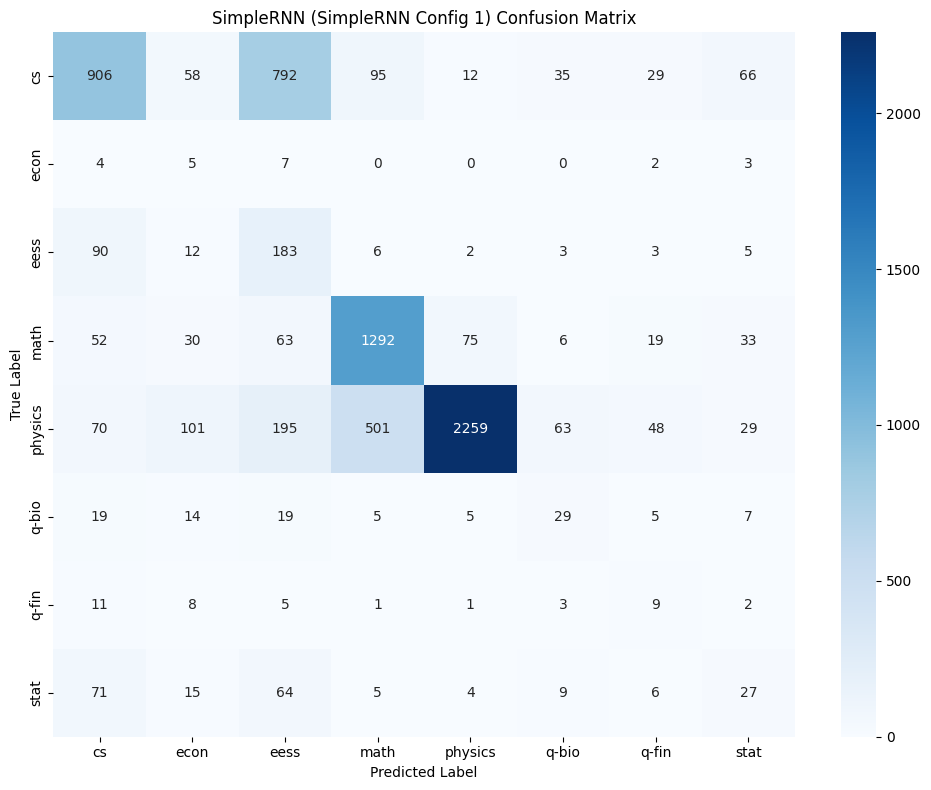

In [ ]:
simple_rnn_models = {

    "SimpleRNN Config 1": (
        simple_rnn_1,
        simple_rnn_f1_callback_1
    ),

    "SimpleRNN Config 2": (
        simple_rnn_2,
        simple_rnn_f1_callback_2
    ),

    "SimpleRNN Config 3": (
        simple_rnn_3,
        simple_rnn_f1_callback_3
    )
}

(
    best_simple_rnn_model,
    best_simple_rnn_config,
    best_simple_rnn_val_f1,
    simple_rnn_tuning_df
) = select_best_rnn_model(
    "SimpleRNN",
    simple_rnn_models
)
simple_rnn_final_result = evaluate_neural_model(
    best_simple_rnn_model,
    X_test_pad,
    y_test,
    f"SimpleRNN ({best_simple_rnn_config})"
)

GRU HYPERPARAMETER TUNING RESULTS


,Model,Configuration,Validation Macro F1
0,GRU,GRU Config 1,0.568754
1,GRU,GRU Config 2,0.541002
2,GRU,GRU Config 3,0.519106



Best Configuration:
GRU Config 1

Best Validation Macro F1:
0.5687544456997768
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
FINAL TEST: GRU (GRU Config 1)
              precision    recall  f1-score   support

          cs     0.8953    0.6267    0.7373      1993
        econ     0.0231    0.2857    0.0427        21
        eess     0.3195    0.7072    0.4401       304
        math     0.8843    0.8274    0.8549      1570
     physics     0.9794    0.8873    0.9311      3266
       q-bio     0.2868    0.7184    0.4100       103
       q-fin     0.4474    0.8500    0.5862        40
        stat     0.2819    0.5721    0.3777       201

    accuracy                         0.7855      7498
   macro avg     0.5147    0.6844    0.5475      7498
weighted avg     0.8766    0.7855    0.8174      7498



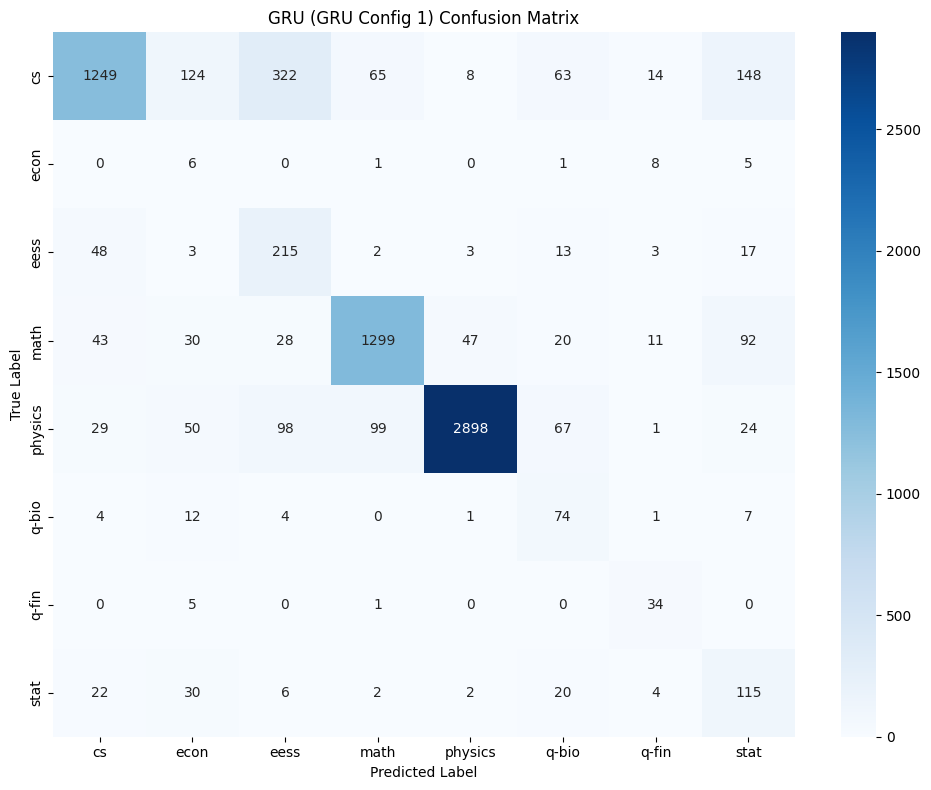

In [ ]:
gru_models = {

    "GRU Config 1": (
        gru_1,
        gru_f1_callback_1
    ),

    "GRU Config 2": (
        gru_2,
        gru_f1_callback_2
    ),

    "GRU Config 3": (
        gru_3,
        gru_f1_callback_3
    )
}

(
    best_gru_model,
    best_gru_config,
    best_gru_val_f1,
    gru_tuning_df
) = select_best_rnn_model(
    "GRU",
    gru_models
)

gru_final_result = evaluate_neural_model(
    best_gru_model,
    X_test_pad,
    y_test,
    f"GRU ({best_gru_config})"
)

LSTM HYPERPARAMETER TUNING RESULTS


,Model,Configuration,Validation Macro F1
0,LSTM,LSTM Config 1,0.486447
1,LSTM,LSTM Config 3,0.465102
2,LSTM,LSTM Config 2,0.425510



Best Configuration:
LSTM Config 1

Best Validation Macro F1:
0.48644708522442043
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
FINAL TEST: LSTM (LSTM Config 1)
              precision    recall  f1-score   support

          cs     0.8932    0.5750    0.6996      1993
        econ     0.0449    0.1905    0.0727        21
        eess     0.2834    0.5164    0.3660       304
        math     0.8953    0.7790    0.8331      1570
     physics     0.9802    0.8181    0.8919      3266
       q-bio     0.1408    0.6796    0.2333       103
       q-fin     0.3407    0.7750    0.4733        40
        stat     0.1547    0.6866    0.2525       201

    accuracy                         0.7257      7498
   macro avg     0.4667    0.6275    0.4778      7498
weighted avg     0.8714    0.7257    0.7764      7498



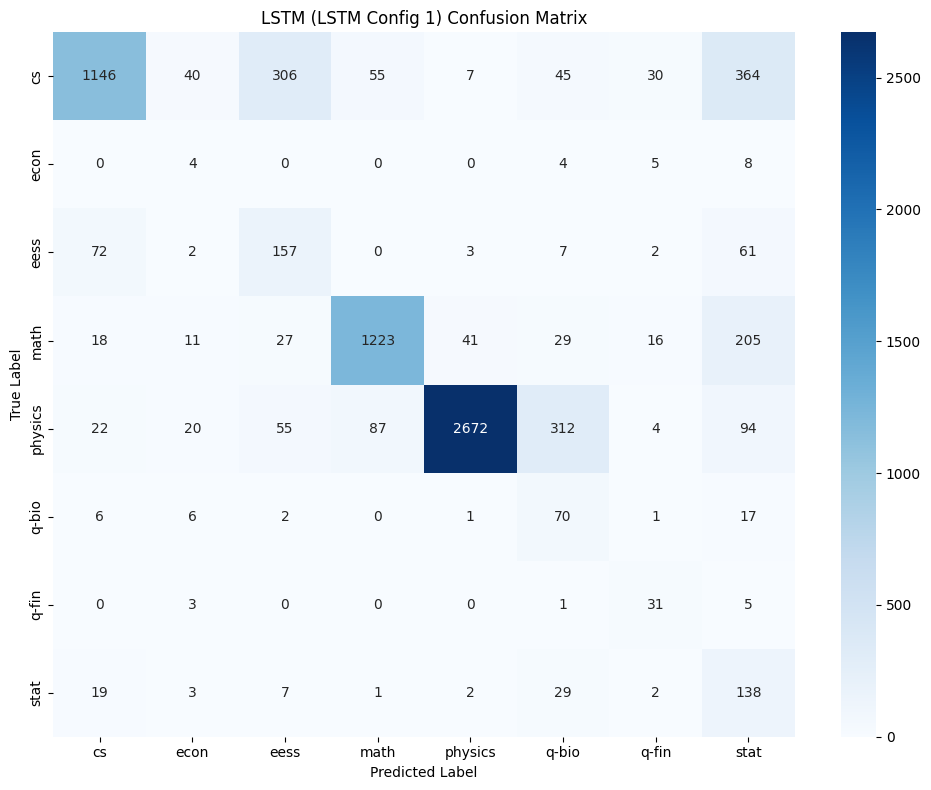

In [ ]:
lstm_models = {

    "LSTM Config 1": (
        lstm_1,
        lstm_f1_callback_1
    ),

    "LSTM Config 2": (
        lstm_2,
        lstm_f1_callback_2
    ),

    "LSTM Config 3": (
        lstm_3,
        lstm_f1_callback_3
    )
}

(
    best_lstm_model,
    best_lstm_config,
    best_lstm_val_f1,
    lstm_tuning_df
) = select_best_rnn_model(
    "LSTM",
    lstm_models
)

lstm_final_result = evaluate_neural_model(
    best_lstm_model,
    X_test_pad,
    y_test,
    f"LSTM ({best_lstm_config})"
)

Bidirectional SimpleRNN HYPERPARAMETER TUNING RESULTS


,Model,Configuration,Validation Macro F1
0,Bidirectional SimpleRNN,BiRNN Config 2,0.445094
1,Bidirectional SimpleRNN,BiRNN Config 3,0.403591
2,Bidirectional SimpleRNN,BiRNN Config 1,0.400296



Best Configuration:
BiRNN Config 2

Best Validation Macro F1:
0.44509432888560285
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
FINAL TEST: Bidirectional SimpleRNN (BiRNN Config 2)
              precision    recall  f1-score   support

          cs     0.8753    0.3628    0.5129      1993
        econ     0.0444    0.1905    0.0721        21
        eess     0.1941    0.7105    0.3049       304
        math     0.8103    0.8599    0.8344      1570
     physics     0.9751    0.8509    0.9088      3266
       q-bio     0.1918    0.7282    0.3036       103
       q-fin     0.2250    0.4500    0.3000        40
        stat     0.2531    0.6070    0.3572       201

    accuracy                         0.7051      7498
   macro avg     0.4461    0.5950    0.4492      7498
weighted avg     0.8457    0.7051    0.7348      7498



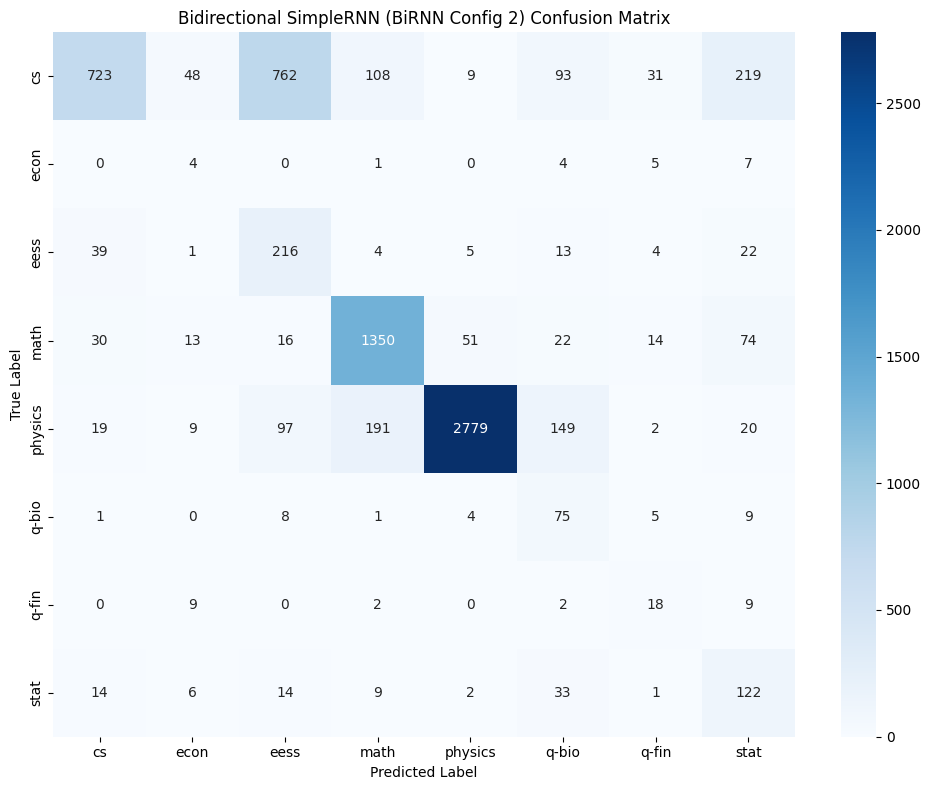

In [ ]:
birnn_models = {

    "BiRNN Config 1": (
        birnn_1,
        birnn_f1_callback_1
    ),

    "BiRNN Config 2": (
        birnn_2,
        birnn_f1_callback_2
    ),

    "BiRNN Config 3": (
        birnn_3,
        birnn_f1_callback_3
    )
}

(
    best_birnn_model,
    best_birnn_config,
    best_birnn_val_f1,
    birnn_tuning_df
) = select_best_rnn_model(
    "Bidirectional SimpleRNN",
    birnn_models
)

birnn_final_result = evaluate_neural_model(
    best_birnn_model,
    X_test_pad,
    y_test,
    f"Bidirectional SimpleRNN ({best_birnn_config})"
)

Bidirectional GRU HYPERPARAMETER TUNING RESULTS


,Model,Configuration,Validation Macro F1
0,Bidirectional GRU,BiGRU Config 1,0.590836
1,Bidirectional GRU,BiGRU Config 3,0.572411
2,Bidirectional GRU,BiGRU Config 2,0.532853



Best Configuration:
BiGRU Config 1

Best Validation Macro F1:
0.5908363534346028
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
FINAL TEST: Bidirectional GRU (BiGRU Config 1)
              precision    recall  f1-score   support

          cs     0.8961    0.6754    0.7702      1993
        econ     0.0446    0.2381    0.0752        21
        eess     0.3746    0.6974    0.4874       304
        math     0.8497    0.8713    0.8604      1570
     physics     0.9837    0.8864    0.9325      3266
       q-bio     0.2603    0.7961    0.3923       103
       q-fin     0.4583    0.8250    0.5893        40
        stat     0.3307    0.6219    0.4318       201

    accuracy                         0.8090      7498
   macro avg     0.5248    0.7014    0.5674      7498
weighted avg     0.8748    0.8090    0.8312      7498



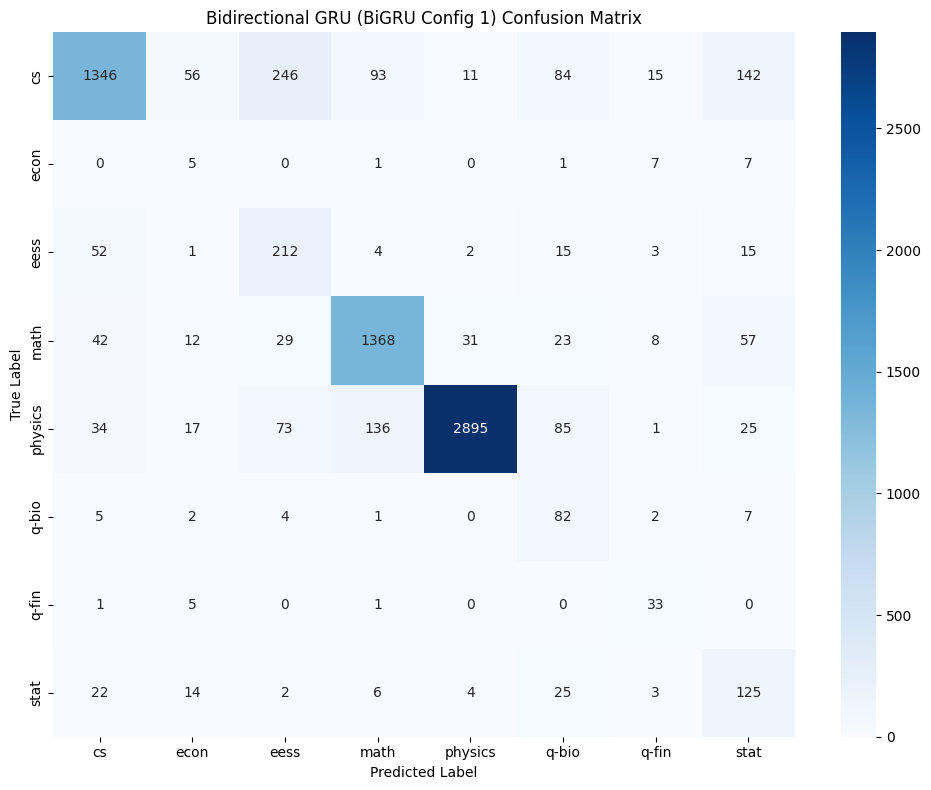

In [ ]:
bigru_models = {

    "BiGRU Config 1": (
        bigru_1,
        bigru_f1_callback_1
    ),

    "BiGRU Config 2": (
        bigru_2,
        bigru_f1_callback_2
    ),

    "BiGRU Config 3": (
        bigru_3,
        bigru_f1_callback_3
    )
}

(
    best_bigru_model,
    best_bigru_config,
    best_bigru_val_f1,
    bigru_tuning_df
) = select_best_rnn_model(
    "Bidirectional GRU",
    bigru_models
)

bigru_final_result = evaluate_neural_model(
    best_bigru_model,
    X_test_pad,
    y_test,
    f"Bidirectional GRU ({best_bigru_config})"
)

Bidirectional LSTM HYPERPARAMETER TUNING RESULTS


,Model,Configuration,Validation Macro F1
0,Bidirectional LSTM,BiLSTM Config 1,0.578118
1,Bidirectional LSTM,BiLSTM Config 2,0.560447
2,Bidirectional LSTM,BiLSTM Config 3,0.502713



Best Configuration:
BiLSTM Config 1

Best Validation Macro F1:
0.5781176353083968
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
FINAL TEST: Bidirectional LSTM (BiLSTM Config 1)
              precision    recall  f1-score   support

          cs     0.9088    0.6101    0.7301      1993
        econ     0.0660    0.3333    0.1102        21
        eess     0.3363    0.7434    0.4631       304
        math     0.8565    0.8707    0.8636      1570
     physics     0.9792    0.8916    0.9333      3266
       q-bio     0.2441    0.7087    0.3632       103
       q-fin     0.4110    0.7500    0.5310        40
        stat     0.2955    0.6468    0.4056       201

    accuracy                         0.7950      7498
   macro avg     0.5122    0.6943    0.5500      7498
weighted avg     0.8747    0.7950    0.8192      7498



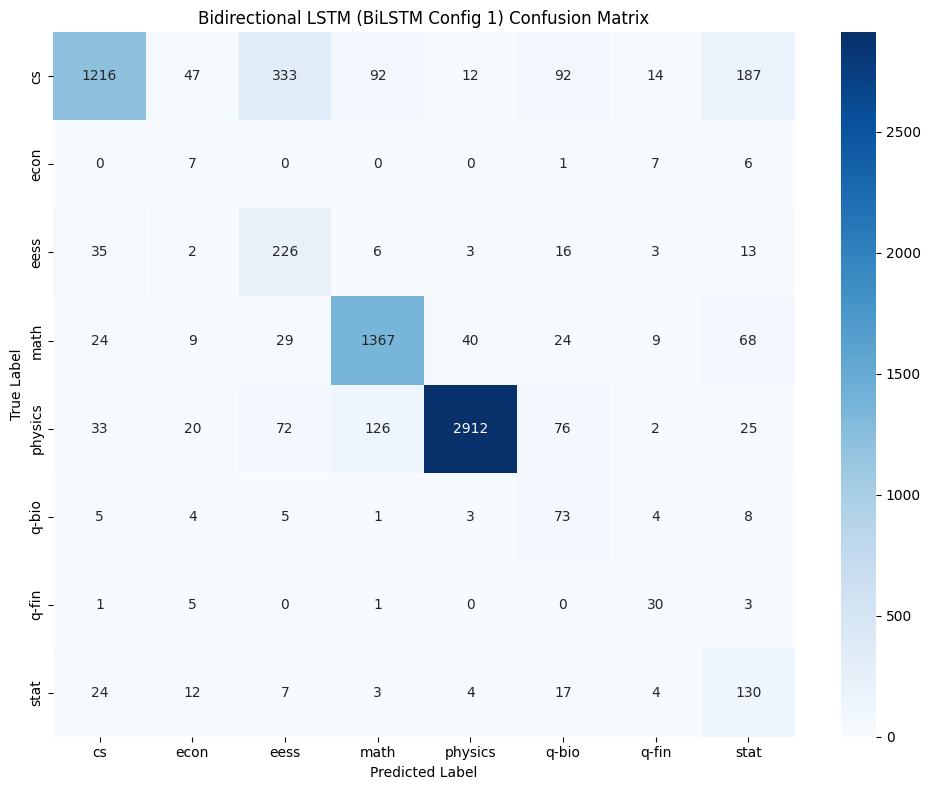

In [ ]:
bilstm_models = {

    "BiLSTM Config 1": (
        bilstm_1,
        bilstm_f1_callback_1
    ),

    "BiLSTM Config 2": (
        bilstm_2,
        bilstm_f1_callback_2
    ),

    "BiLSTM Config 3": (
        bilstm_3,
        bilstm_f1_callback_3
    )
}

(
    best_bilstm_model,
    best_bilstm_config,
    best_bilstm_val_f1,
    bilstm_tuning_df
) = select_best_rnn_model(
    "Bidirectional LSTM",
    bilstm_models
)

bilstm_final_result = evaluate_neural_model(
    best_bilstm_model,
    X_test_pad,
    y_test,
    f"Bidirectional LSTM ({best_bilstm_config})"
)

Final Result

In [ ]:
all_rnn_tuning_results = pd.concat(
    [
        simple_rnn_tuning_df,
        gru_tuning_df,
        lstm_tuning_df,
        birnn_tuning_df,
        bigru_tuning_df,
        bilstm_tuning_df
    ],
    ignore_index=True
)

display(
    all_rnn_tuning_results
)

,Model,Configuration,Validation Macro F1
0,SimpleRNN,SimpleRNN Config 1,0.373396
1,SimpleRNN,SimpleRNN Config 3,0.340996
2,SimpleRNN,SimpleRNN Config 2,0.340810
3,GRU,GRU Config 1,0.568754
4,GRU,GRU Config 2,0.541002
5,GRU,GRU Config 3,0.519106
6,LSTM,LSTM Config 1,0.486447
7,LSTM,LSTM Config 3,0.465102
8,LSTM,LSTM Config 2,0.425510
9,Bidirectional SimpleRNN,BiRNN Config 2,0.445094


In [ ]:
all_rnn_tuning_results.to_csv(
    "rnn_hyperparameter_tuning.csv",
    index=False
)

In [ ]:
rnn_final_results = [
    simple_rnn_final_result,
    gru_final_result,
    lstm_final_result,
    birnn_final_result,
    bigru_final_result,
    bilstm_final_result
]

In [ ]:
rnn_comparison_rows = []

for result in rnn_final_results:

    rnn_comparison_rows.append({
        "Model": result["model"],
        "Representation": result["representation"],
        "Accuracy": result["test_accuracy"],
        "Macro F1": result["test_macro_f1"],
        "Weighted F1": result["test_weighted_f1"]
    })

rnn_final_comparison = pd.DataFrame(
    rnn_comparison_rows
).sort_values(
    "Macro F1",
    ascending=False
).reset_index(
    drop=True
)

display(
    rnn_final_comparison
)

,Model,Representation,Accuracy,Macro F1,Weighted F1
0,Bidirectional GRU (BiGRU Config 1),Word2Vec,0.809016,0.567386,0.831154
1,Bidirectional LSTM (BiLSTM Config 1),Word2Vec,0.795012,0.550015,0.819209
2,GRU (GRU Config 1),Word2Vec,0.785543,0.547494,0.817395
3,LSTM (LSTM Config 1),Word2Vec,0.725660,0.477803,0.776427
4,Bidirectional SimpleRNN (BiRNN Config 2),Word2Vec,0.705121,0.449238,0.734803
5,SimpleRNN (SimpleRNN Config 1),Word2Vec,0.628168,0.357521,0.672237


In [ ]:
best_rnn_result = rnn_final_comparison.iloc[0]

print("=" * 70)
print("BEST RNN MODEL")
print("=" * 70)

print(
    "Model:",
    best_rnn_result["Model"]
)

print(
    "Accuracy:",
    round(
        best_rnn_result["Accuracy"],
        4
    )
)

print(
    "Macro F1:",
    round(
        best_rnn_result["Macro F1"],
        4
    )
)

print(
    "Weighted F1:",
    round(
        best_rnn_result["Weighted F1"],
        4
    )
)

BEST RNN MODEL
Model: Bidirectional GRU (BiGRU Config 1)
Accuracy: 0.809
Macro F1: 0.5674
Weighted F1: 0.8312


# Transformer

In [ ]:
import os
import gc
import json
import numpy as np
import pandas as pd
import torch
import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    f1_score
)

os.makedirs(
    "saved_models",
    exist_ok=True
)

os.makedirs(
    "results",
    exist_ok=True
)

final_results = []

print(
    "Experiment tracking system ready."
)

Experiment tracking system ready.


Transformer datasets

In [ ]:
from datasets import Dataset

transformer_train_df = pd.DataFrame({
    "text": X_train_clean,
    "label": y_train
})

transformer_val_df = pd.DataFrame({
    "text": X_val_clean,
    "label": y_val
})

transformer_test_df = pd.DataFrame({
    "text": X_test_clean,
    "label": y_test
})

print(
    "Train:",
    transformer_train_df.shape
)

print(
    "Validation:",
    transformer_val_df.shape
)

print(
    "Test:",
    transformer_test_df.shape
)

Train: (34990, 2)
Validation: (7498, 2)
Test: (7498, 2)


In [ ]:
NUM_CLASSES = len(class_names)

print(
    "Number of classes:",
    NUM_CLASSES
)

print(
    "Class names:"
)

for index, name in enumerate(class_names):
    print(
        index,
        "->",
        name
    )

Number of classes: 8
Class names:
0 -> cs
1 -> econ
2 -> eess
3 -> math
4 -> physics
5 -> q-bio
6 -> q-fin
7 -> stat


Reusable Transformer functions

In [ ]:
def prepare_transformer_datasets(
    tokenizer,
    max_length=256
):

    train_dataset = Dataset.from_pandas(
        transformer_train_df
    )

    val_dataset = Dataset.from_pandas(
        transformer_val_df
    )

    test_dataset = Dataset.from_pandas(
        transformer_test_df
    )

    def tokenize_function(batch):

        return tokenizer(
            batch["text"],
            truncation=True,
            max_length=max_length
        )

    train_tokenized = train_dataset.map(
        tokenize_function,
        batched=True
    )

    val_tokenized = val_dataset.map(
        tokenize_function,
        batched=True
    )

    test_tokenized = test_dataset.map(
        tokenize_function,
        batched=True
    )

    return (
        train_tokenized,
        val_tokenized,
        test_tokenized
    )

Metrics Function

In [ ]:
def compute_transformer_metrics(
    eval_pred
):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    macro_f1 = f1_score(
        labels,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

General Transformer Training Function

In [ ]:
def train_transformer_model(
    model_name,
    model_checkpoint,
    learning_rate,
    batch_size,
    num_epochs,
    weight_decay,
    max_length=256
):

    print("=" * 70)
    print(f"Training {model_name}")
    print("=" * 70)

    print("Learning rate:", learning_rate)
    print("Batch size:", batch_size)
    print("Epochs:", num_epochs)

    tokenizer = AutoTokenizer.from_pretrained(
        model_checkpoint
    )

    (
        train_tokenized,
        val_tokenized,
        test_tokenized
    ) = prepare_transformer_datasets(
        tokenizer=tokenizer,
        max_length=max_length
    )

    data_collator = DataCollatorWithPadding(
        tokenizer=tokenizer
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint,
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True
    )

    output_directory = f"saved_models/{model_name}"

    training_args = TrainingArguments(
        output_dir=output_directory,

        learning_rate=learning_rate,

        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,

        num_train_epochs=num_epochs,

        weight_decay=weight_decay,

        eval_strategy="epoch",

        save_strategy="epoch",

        logging_strategy="epoch",

        load_best_model_at_end=True,

        metric_for_best_model="macro_f1",

        greater_is_better=True,

        save_total_limit=1,

        fp16=torch.cuda.is_available(),

        report_to="none",

        seed=SEED
    )

    trainer = Trainer(
        model=model,

        args=training_args,

        train_dataset=train_tokenized,

        eval_dataset=val_tokenized,

        processing_class=tokenizer,

        data_collator=data_collator,

        compute_metrics=compute_transformer_metrics,

        callbacks=[
            EarlyStoppingCallback(
                early_stopping_patience=2
            )
        ]
    )

    trainer.train()

    validation_output = trainer.predict(
        val_tokenized
    )

    validation_predictions = np.argmax(
        validation_output.predictions,
        axis=1
    )

    validation_accuracy = accuracy_score(
        y_val,
        validation_predictions
    )

    validation_macro_f1 = f1_score(
        y_val,
        validation_predictions,
        average="macro"
    )

    result = {
        "model": model_name,
        "representation": "Transformer",
        "validation_accuracy": validation_accuracy,
        "validation_macro_f1": validation_macro_f1,
        "learning_rate": learning_rate,
        "batch_size": batch_size,
        "epochs": num_epochs,
        "weight_decay": weight_decay
    }

    print("\nValidation Accuracy:")
    print(validation_accuracy)

    print("\nValidation Macro F1:")
    print(validation_macro_f1)

    return (
        trainer,
        tokenizer,
        test_tokenized,
        result
    )

# BERT Base

BERT Configuration 1

In [ ]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

bert_1 = train_transformer_model(
    model_name="BERT_Config_1",
    model_checkpoint="bert-base-uncased",
    learning_rate=2e-5,
    batch_size=16,
    num_epochs=3,
    weight_decay=0.01,
    max_length=256
)

bert_results = []

bert_results.append(
    bert_1[3]
)

Training BERT_Config_1
Learning rate: 2e-05
Batch size: 16
Epochs: 3


Map:   0%|          | 0/34990 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


Validation Accuracy:
0.8861029607895439

Validation Macro F1:
0.7064486468591232


BERT Configuration 2

In [ ]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

bert_2 = train_transformer_model(
    model_name="BERT_Config_2",
    model_checkpoint="bert-base-uncased",
    learning_rate=3e-5,
    batch_size=16,
    num_epochs=3,
    weight_decay=0.01,
    max_length=256
)

bert_results.append(
    bert_2[3]
)

Training BERT_Config_2
Learning rate: 3e-05
Batch size: 16
Epochs: 3


Map:   0%|          | 0/34990 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


Validation Accuracy:
0.8847692718058149

Validation Macro F1:
0.6969350447782092


BERT Configuration 3

In [ ]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

bert_3 = train_transformer_model(
    model_name="BERT_Config_3",
    model_checkpoint="bert-base-uncased",
    learning_rate=2e-5,
    batch_size=32,
    num_epochs=4,
    weight_decay=0.05,
    max_length=256
)

bert_results.append(
    bert_3[3]
)

Training BERT_Config_3
Learning rate: 2e-05
Batch size: 32
Epochs: 4


Map:   0%|          | 0/34990 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


Validation Accuracy:
0.881968524939984

Validation Macro F1:
0.710715271102529


In [ ]:
import gc
import torch


if 'model' in locals(): del model
if 'optimizer' in locals(): del optimizer
if 'w2v_matrix' in locals(): del w2v_matrix
torch.cuda.empty_cache()


print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
print(f"Reserved: {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

Allocated: 3825.53 MB
Reserved: 4100.00 MB


BERT Results

In [ ]:
bert_results_df = pd.DataFrame(
    bert_results
)

bert_results_df = bert_results_df.sort_values(
    "validation_macro_f1",
    ascending=False
)

display(
    bert_results_df
)

best_bert_config = bert_results_df.iloc[0]

print(
    "\nBEST BERT CONFIGURATION"
)

print(
    best_bert_config
)

,model,representation,validation_accuracy,validation_macro_f1,learning_rate,batch_size,epochs,weight_decay
2,BERT_Config_3,Transformer,0.881969,0.710715,0.00002,32,4,0.05
0,BERT_Config_1,Transformer,0.886103,0.706449,0.00002,16,3,0.01
1,BERT_Config_2,Transformer,0.884769,0.696935,0.00003,16,3,0.01



BEST BERT CONFIGURATION
model                  BERT_Config_3
representation           Transformer
validation_accuracy         0.881969
validation_macro_f1         0.710715
learning_rate                0.00002
batch_size                        32
epochs                             4
weight_decay                    0.05
Name: 2, dtype: object


# DistilBERT

DistilBERT Configuration 1

In [ ]:
distilbert_results = []

distilbert_1 = train_transformer_model(
    model_name="DistilBERT_Config_1",
    model_checkpoint="distilbert-base-uncased",
    learning_rate=2e-5,
    batch_size=16,
    num_epochs=3,
    weight_decay=0.01,
    max_length=256
)

distilbert_results.append(
    distilbert_1[3]
)

Training DistilBERT_Config_1
Learning rate: 2e-05
Batch size: 16
Epochs: 3


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.437104,0.338842,0.879568,0.639155,0.877028
2,0.272876,0.344279,0.882902,0.660723,0.879685
3,0.194856,0.375825,0.884636,0.673072,0.883292


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Validation Accuracy:
0.884635902907442

Validation Macro F1:
0.6730717563886852


DistilBERT Configuration 2

In [ ]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

distilbert_2 = train_transformer_model(
    model_name="DistilBERT_Config_2",
    model_checkpoint="distilbert-base-uncased",
    learning_rate=3e-5,
    batch_size=16,
    num_epochs=3,
    weight_decay=0.01,
    max_length=256
)

distilbert_results.append(
    distilbert_2[3]
)

Training DistilBERT_Config_2
Learning rate: 3e-05
Batch size: 16
Epochs: 3


Map:   0%|          | 0/34990 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.427308,0.342427,0.876634,0.645149,0.877384
2,0.260077,0.345590,0.885970,0.699734,0.882925
3,0.165084,0.400919,0.884769,0.710225,0.883911


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Validation Accuracy:
0.8847692718058149

Validation Macro F1:
0.7102245406168477


DistilBERT Configuration 3

In [ ]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

distilbert_3 = train_transformer_model(
    model_name="DistilBERT_Config_3",
    model_checkpoint="distilbert-base-uncased",
    learning_rate=2e-5,
    batch_size=32,
    num_epochs=4,
    weight_decay=0.05,
    max_length=256
)

distilbert_results.append(
    distilbert_3[3]
)

Training DistilBERT_Config_3
Learning rate: 2e-05
Batch size: 32
Epochs: 4


Map:   0%|          | 0/34990 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Map:   0%|          | 0/7498 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Validation Accuracy:
0.8845025340090691

Validation Macro F1:
0.6818576850525297


DistilBERT Results

In [ ]:
distilbert_results_df = pd.DataFrame(
    distilbert_results
).sort_values(
    "validation_macro_f1",
    ascending=False
)

display(
    distilbert_results_df
)

,model,representation,validation_accuracy,validation_macro_f1,learning_rate,batch_size,epochs,weight_decay
1,DistilBERT_Config_2,Transformer,0.884769,0.710225,0.00003,16,3,0.01
2,DistilBERT_Config_3,Transformer,0.884503,0.681858,0.00002,32,4,0.05
0,DistilBERT_Config_1,Transformer,0.884636,0.673072,0.00002,16,3,0.01


# RoBERTa

In [ ]:
roberta_results = []

RoBERTa Configuration 1

In [ ]:
roberta_1 = train_transformer_model(
    model_name="RoBERTa_Config_1",
    model_checkpoint="roberta-base",
    learning_rate=2e-5,
    batch_size=16,
    num_epochs=3,
    weight_decay=0.01,
    max_length=256
)

roberta_results.append(
    roberta_1[3]
)

Training RoBERTa_Config_1
Learning rate: 2e-05
Batch size: 16
Epochs: 3


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.454197,0.333475,0.878501,0.656526,0.876794
2,0.293465,0.328946,0.885169,0.687105,0.879455
3,0.209226,0.374051,0.884769,0.705072,0.884265


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Validation Accuracy:
0.8847692718058149

Validation Macro F1:
0.705071636001408


RoBERTa Configuration 2

In [ ]:

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

roberta_2 = train_transformer_model(
    model_name="RoBERTa_Config_2",
    model_checkpoint="roberta-base",
    learning_rate=3e-5,
    batch_size=16,
    num_epochs=3,
    weight_decay=0.01,
    max_length=256
)

roberta_results.append(
    roberta_2[3]
)

RoBERTa Configuration 3

In [ ]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

roberta_3 = train_transformer_model(
    model_name="RoBERTa_Config_3",
    model_checkpoint="roberta-base",
    learning_rate=1e-5,
    batch_size=32,
    num_epochs=4,
    weight_decay=0.05,
    max_length=256
)

roberta_results.append(
    roberta_3[3]
)

RoBERTa Results

In [ ]:
roberta_results_df = pd.DataFrame(
    roberta_results
).sort_values(
    "validation_macro_f1",
    ascending=False
)

display(
    roberta_results_df
)

,model,representation,validation_accuracy,validation_macro_f1,learning_rate,batch_size,epochs,weight_decay
0,RoBERTa_Config_1,Transformer,0.884769,0.705072,0.00002,16,3,0.01


Transformer Comparison

In [ ]:
def evaluate_transformer_on_test(
    trainer,
    test_dataset,
    model_name
):

    output = trainer.predict(
        test_dataset
    )

    probabilities = (
        torch.nn.functional.softmax(
            torch.tensor(
                output.predictions
            ),
            dim=1
        ).numpy()
    )

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    print("=" * 70)
    print(
        f"FINAL TEST RESULTS: {model_name}"
    )
    print("=" * 70)

    print(
        "\nAccuracy:",
        round(
            accuracy,
            4
        )
    )

    print(
        "\nMacro F1:",
        round(
            macro_f1,
            4
        )
    )

    print(
        "\nWeighted F1:",
        round(
            weighted_f1,
            4
        )
    )

    print(
        "\nClassification Report:"
    )

    print(
        classification_report(
            y_test,
            predictions,
            target_names=class_names,
            digits=4
        )
    )

    plot_confusion_matrix(
        y_test,
        predictions,
        f"{model_name} Confusion Matrix"
    )

    return {
        "model": model_name,
        "representation": "Transformer",
        "test_accuracy": accuracy,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "predictions": predictions,
        "probabilities": probabilities
    }

In [ ]:
def select_best_transformer_model(
    model_name,
    models_dict
):

    results = []

    for config_name, model_data in models_dict.items():

        trainer = model_data[0]
        tokenizer = model_data[1]
        test_dataset = model_data[2]
        result = model_data[3]

        results.append({
            "Model": model_name,
            "Configuration": config_name,
            "Validation Accuracy": result[
                "validation_accuracy"
            ],
            "Validation Macro F1": result[
                "validation_macro_f1"
            ],
            "Learning Rate": result[
                "learning_rate"
            ],
            "Batch Size": result[
                "batch_size"
            ],
            "Epochs": result[
                "epochs"
            ],
            "Weight Decay": result[
                "weight_decay"
            ]
        })

    results_df = pd.DataFrame(
        results
    ).sort_values(
        "Validation Macro F1",
        ascending=False
    ).reset_index(
        drop=True
    )

    print("=" * 70)
    print(
        f"{model_name} HYPERPARAMETER TUNING RESULTS"
    )
    print("=" * 70)

    display(
        results_df
    )

    best_config_name = results_df.loc[
        0,
        "Configuration"
    ]

    best_model_data = models_dict[
        best_config_name
    ]

    best_trainer = best_model_data[0]
    best_tokenizer = best_model_data[1]
    best_test_dataset = best_model_data[2]

    best_validation_f1 = best_model_data[3][
        "validation_macro_f1"
    ]

    print("\nBest Configuration:")
    print(
        best_config_name
    )

    print("\nBest Validation Macro F1:")
    print(
        best_validation_f1
    )

    return (
        best_trainer,
        best_tokenizer,
        best_test_dataset,
        best_config_name,
        best_validation_f1,
        results_df
    )

BERT Base HYPERPARAMETER TUNING RESULTS


,Model,Configuration,Validation Accuracy,Validation Macro F1,Learning Rate,Batch Size,Epochs,Weight Decay
0,BERT Base,BERT Config 3,0.881969,0.710715,0.00002,32,4,0.05
1,BERT Base,BERT Config 1,0.886103,0.706449,0.00002,16,3,0.01
2,BERT Base,BERT Config 2,0.884769,0.696935,0.00003,16,3,0.01



Best Configuration:
BERT Config 3

Best Validation Macro F1:
0.710715271102529


FINAL TEST RESULTS: BERT Base (BERT Config 3)

Accuracy: 0.8817

Macro F1: 0.7051

Weighted F1: 0.8846

Classification Report:
              precision    recall  f1-score   support

          cs     0.8924    0.8319    0.8611      1993
        econ     0.6364    0.3333    0.4375        21
        eess     0.5273    0.6349    0.5761       304
        math     0.8836    0.9089    0.8961      1570
     physics     0.9643    0.9522    0.9582      3266
       q-bio     0.6311    0.6311    0.6311       103
       q-fin     0.7500    0.8250    0.7857        40
        stat     0.4275    0.5871    0.4948       201

    accuracy                         0.8817      7498
   macro avg     0.7141    0.7130    0.7051      7498
weighted avg     0.8896    0.8817    0.8846      7498



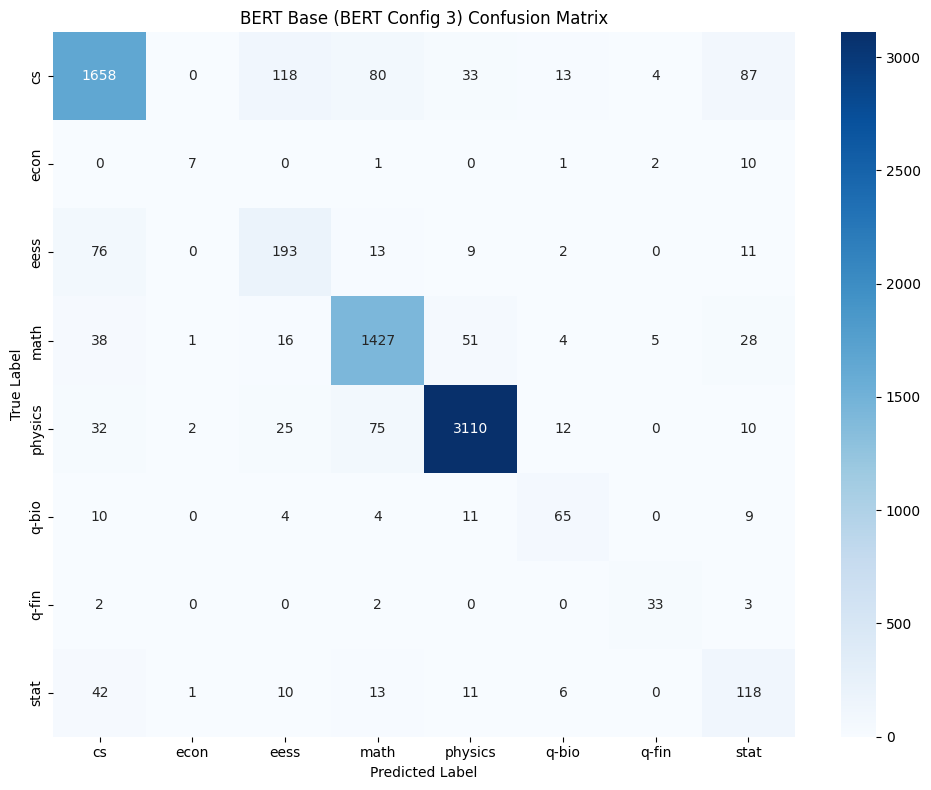

In [ ]:
bert_models = {

    "BERT Config 1": bert_1,

    "BERT Config 2": bert_2,

    "BERT Config 3": bert_3
}

(
    best_bert_trainer,
    best_bert_tokenizer,
    best_bert_test_dataset,
    best_bert_config,
    best_bert_val_f1,
    bert_tuning_df
) = select_best_transformer_model(
    "BERT Base",
    bert_models
)
bert_final_result = evaluate_transformer_on_test(
    trainer=best_bert_trainer,
    test_dataset=best_bert_test_dataset,
    model_name=f"BERT Base ({best_bert_config})"
)

In [ ]:
distilbert_models = {

    "DistilBERT Config 1": distilbert_1,

    "DistilBERT Config 2": distilbert_2,

    "DistilBERT Config 3": distilbert_3
}

(
    best_distilbert_trainer,
    best_distilbert_tokenizer,
    best_distilbert_test_dataset,
    best_distilbert_config,
    best_distilbert_val_f1,
    distilbert_tuning_df
) = select_best_transformer_model(
    "DistilBERT",
    distilbert_models
)

distilbert_final_result = evaluate_transformer_on_test(
    trainer=best_distilbert_trainer,
    test_dataset=best_distilbert_test_dataset,
    model_name=f"DistilBERT ({best_distilbert_config})"
)

In [ ]:
roberta_models = {

    "RoBERTa Config 1": roberta_1,

    "RoBERTa Config 2": roberta_2,

    "RoBERTa Config 3": roberta_3
}

(
    best_roberta_trainer,
    best_roberta_tokenizer,
    best_roberta_test_dataset,
    best_roberta_config,
    best_roberta_val_f1,
    roberta_tuning_df
) = select_best_transformer_model(
    "RoBERTa",
    roberta_models
)

roberta_final_result = evaluate_transformer_on_test(
    trainer=best_roberta_trainer,
    test_dataset=best_roberta_test_dataset,
    model_name=f"RoBERTa ({best_roberta_config})"
)

In [ ]:
all_transformer_tuning_results = pd.concat(
    [
        bert_tuning_df,
        #distilbert_tuning_df,
        #oberta_tuning_df
    ],
    ignore_index=True
)

all_transformer_tuning_results = (
    all_transformer_tuning_results
    .sort_values(
        "Validation Macro F1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    all_transformer_tuning_results
)

all_transformer_tuning_results.to_csv(
    "transformer_hyperparameter_tuning.csv",
    index=False
)

,Model,Configuration,Validation Accuracy,Validation Macro F1,Learning Rate,Batch Size,Epochs,Weight Decay
0,BERT Base,BERT Config 3,0.881969,0.710715,0.00002,32,4,0.05
1,BERT Base,BERT Config 1,0.886103,0.706449,0.00002,16,3,0.01
2,BERT Base,BERT Config 2,0.884769,0.696935,0.00003,16,3,0.01


# Model Comparison

In [ ]:
all_final_results = [
    lr_final_result,
    nb_final_result,
    rf_final_result,
    gru_final_result,
    bert_final_result,
    #distilbert_final_result

]

In [ ]:
all_final_results.extend([
    simple_rnn_final_result,
    lstm_final_result,
    bigru_final_result,
    birnn_final_result,
    bilstm_final_result
])

In [ ]:
comparison_rows = []

for result in all_final_results:

    comparison_rows.append({
        "Model": result["model"],
        "Representation": result["representation"],
        "Accuracy": result["test_accuracy"],
        "Macro F1": result["test_macro_f1"],
        "Weighted F1": result["test_weighted_f1"]
    })

final_comparison = pd.DataFrame(
    comparison_rows
).sort_values(
    "Macro F1",
    ascending=False
)

display(
    final_comparison
)

,Model,Representation,Accuracy,Macro F1,Weighted F1
4,BERT Base (BERT Config 3),Transformer,0.881702,0.705070,0.884610
0,Logistic Regression (LR-3),TF-IDF,0.857562,0.569774,0.861267
7,Bidirectional GRU (BiGRU Config 1),Word2Vec,0.809016,0.567386,0.831154
9,Bidirectional LSTM (BiLSTM Config 1),Word2Vec,0.795012,0.550015,0.819209
3,GRU (GRU Config 1),Word2Vec,0.785543,0.547494,0.817395
2,Random Forest (RF-2),TF-IDF,0.792345,0.545895,0.791846
1,Naive Bayes (NB-1),TF-IDF,0.860496,0.533102,0.854050
6,LSTM (LSTM Config 1),Word2Vec,0.725660,0.477803,0.776427
8,Bidirectional SimpleRNN (BiRNN Config 2),Word2Vec,0.705121,0.449238,0.734803
5,SimpleRNN (SimpleRNN Config 1),Word2Vec,0.628168,0.357521,0.672237


In [ ]:
final_comparison.to_csv(
    "final_model_comparison.csv",
    index=False
)

Visualization

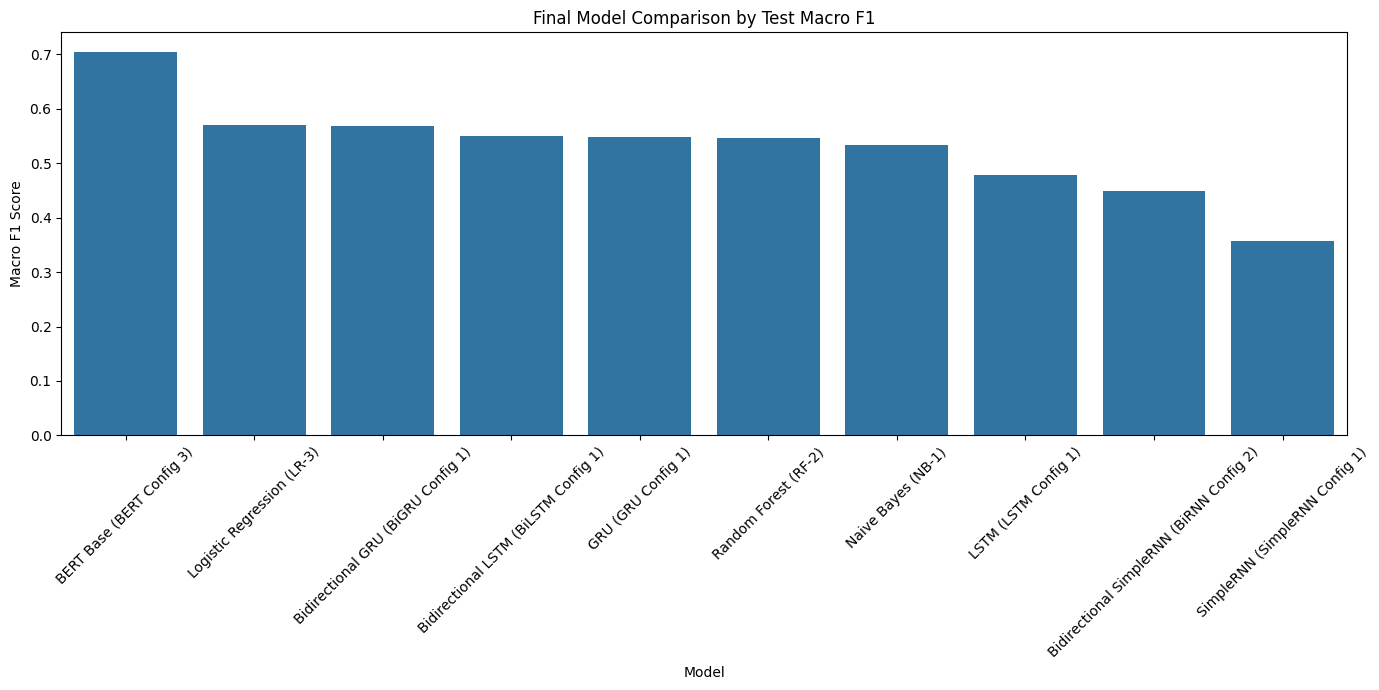

In [ ]:
plt.figure(
    figsize=(14, 7)
)

sns.barplot(
    data=final_comparison,
    x="Model",
    y="Macro F1"
)

plt.title(
    "Final Model Comparison by Test Macro F1"
)

plt.xticks(
    rotation=45
)

plt.ylabel(
    "Macro F1 Score"
)

plt.tight_layout()

plt.show()

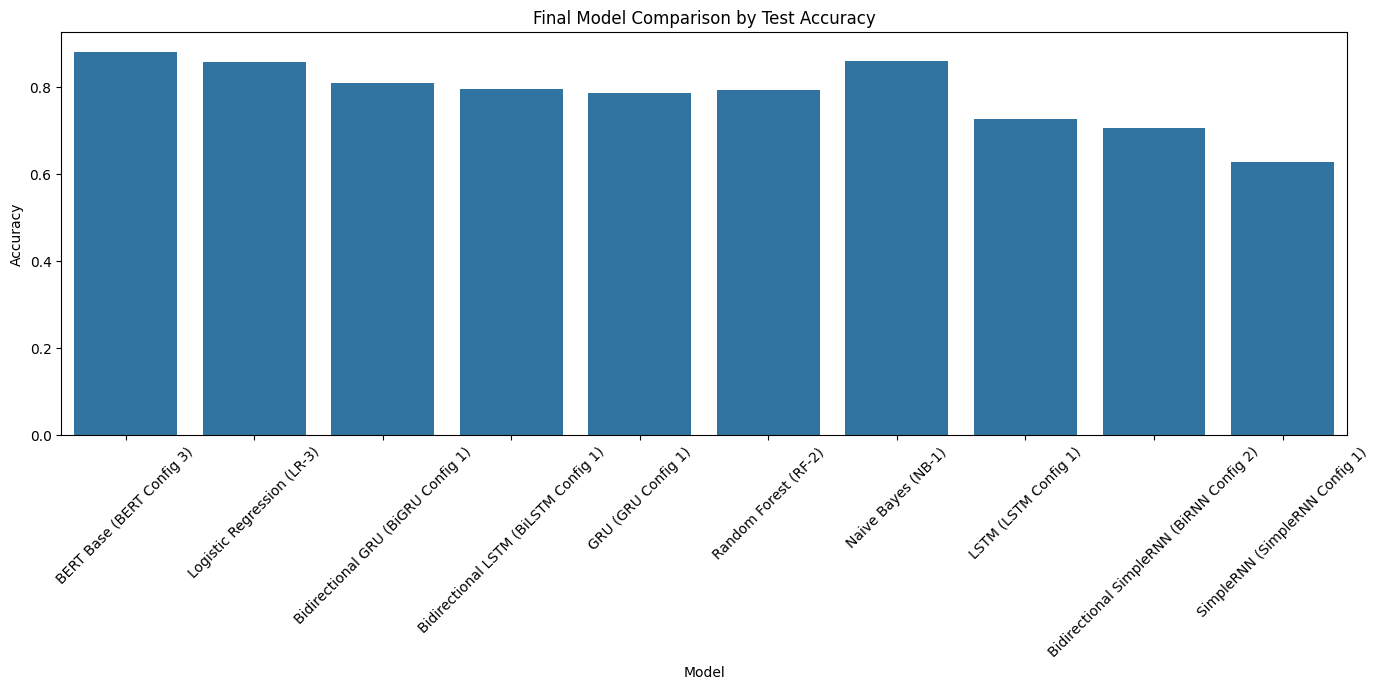

In [ ]:
plt.figure(
    figsize=(14, 7)
)

sns.barplot(
    data=final_comparison,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Final Model Comparison by Test Accuracy"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

In [ ]:
best_model = final_comparison.iloc[0]

worst_model = final_comparison.iloc[-1]

print("=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    best_model
)

print("\n")

print("=" * 70)
print("WORST MODEL")
print("=" * 70)

print(
    worst_model
)

BEST MODEL
Model             BERT Base (BERT Config 3)
Representation                  Transformer
Accuracy                           0.881702
Macro F1                            0.70507
Weighted F1                         0.88461
Name: 4, dtype: object


WORST MODEL
Model             SimpleRNN (SimpleRNN Config 1)
Representation                          Word2Vec
Accuracy                                0.628168
Macro F1                                0.357521
Weighted F1                             0.672237
Name: 5, dtype: object


best models

In [ ]:
from scipy.special import softmax



bert_probs = bert_final_result[
    "probabilities"
]
lr_probs = lr_final_result[
    "probabilities"
]

bigru_probs = bigru_final_result[
    "probabilities"
]

In [ ]:
ensemble_probs = (

    0.50 * bert_probs
    +
    0.30 * lr_probs
    +
    0.20 * bigru_probs
)

ensemble_predictions = np.argmax(
    ensemble_probs,
    axis=1
)

In [ ]:
ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_predictions
)

ensemble_macro_f1 = f1_score(
    y_test,
    ensemble_predictions,
    average="macro"
)

ensemble_weighted_f1 = f1_score(
    y_test,
    ensemble_predictions,
    average="weighted"
)

print(
    "ENSEMBLE RESULTS"
)

print(
    "Accuracy:",
    ensemble_accuracy
)

print(
    "Macro F1:",
    ensemble_macro_f1
)

print(
    "Weighted F1:",
    ensemble_weighted_f1
)

ENSEMBLE RESULTS
Accuracy: 0.8865030674846626
Macro F1: 0.7142499117017831
Weighted F1: 0.8898051503476003


Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        ensemble_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

          cs     0.8905    0.8404    0.8647      1993
        econ     0.6364    0.3333    0.4375        21
        eess     0.5277    0.6579    0.5857       304
        math     0.9007    0.9070    0.9038      1570
     physics     0.9698    0.9525    0.9611      3266
       q-bio     0.5896    0.7670    0.6667       103
       q-fin     0.7619    0.8000    0.7805        40
        stat     0.4542    0.5920    0.5140       201

    accuracy                         0.8865      7498
   macro avg     0.7163    0.7313    0.7142      7498
weighted avg     0.8952    0.8865    0.8898      7498



confusion matrix

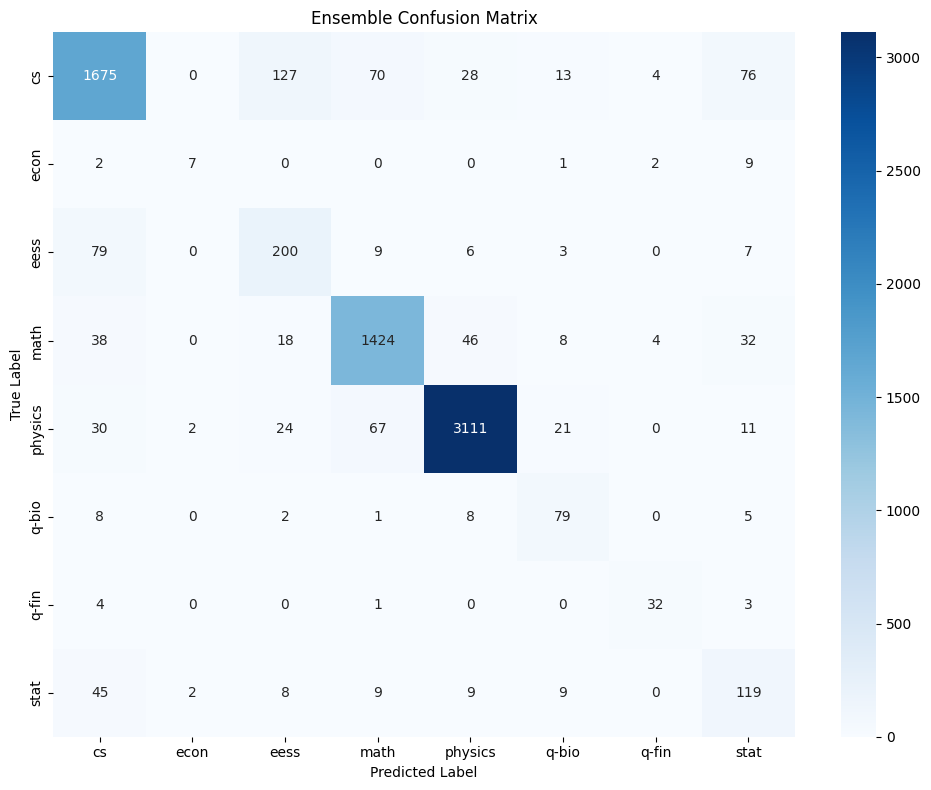

In [ ]:
plot_confusion_matrix(
    y_test,
    ensemble_predictions,
    "Ensemble Confusion Matrix"
)

In [ ]:
ensemble_result = {
    "Model": "Weighted Ensemble",
    "Representation": "BERT + Logistic Regression + BiGRU",
    "Accuracy": ensemble_accuracy,
    "Macro F1": ensemble_macro_f1,
    "Weighted F1": ensemble_weighted_f1
}

final_comparison = pd.concat(
    [
        final_comparison,
        pd.DataFrame([ensemble_result])
    ],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(
    "Macro F1",
    ascending=False
)

display(
    final_comparison
)

,Model,Representation,Accuracy,Macro F1,Weighted F1
0,Weighted Ensemble,RoBERTa + BERT + BiLSTM,0.886503,0.714250,0.889805
11,Weighted Ensemble,BERT + Logistic Regression + BiGRU,0.886503,0.714250,0.889805
1,BERT Base (BERT Config 3),Transformer,0.881702,0.705070,0.884610
2,Logistic Regression (LR-3),TF-IDF,0.857562,0.569774,0.861267
3,Bidirectional GRU (BiGRU Config 1),Word2Vec,0.809016,0.567386,0.831154
4,Bidirectional LSTM (BiLSTM Config 1),Word2Vec,0.795012,0.550015,0.819209
5,GRU (GRU Config 1),Word2Vec,0.785543,0.547494,0.817395
6,Random Forest (RF-2),TF-IDF,0.792345,0.545895,0.791846
7,Naive Bayes (NB-1),TF-IDF,0.860496,0.533102,0.854050
8,LSTM (LSTM Config 1),Word2Vec,0.725660,0.477803,0.776427


# Ablation Study

Ablation datasets

In [ ]:
X_title = df["title"].fillna("").values

X_abstract = df["abstract"].fillna("").values

X_combined = df["text"].values

y_ablation = df["label"].values

In [ ]:
X_train_title, X_test_title, y_train_ab, y_test_ab = train_test_split(
    X_title,
    y_ablation,
    test_size=0.20,
    stratify=y_ablation,
    random_state=SEED
)

X_train_abstract, X_test_abstract, _, _ = train_test_split(
    X_abstract,
    y_ablation,
    test_size=0.20,
    stratify=y_ablation,
    random_state=SEED
)

X_train_combined, X_test_combined, _, _ = train_test_split(
    X_combined,
    y_ablation,
    test_size=0.20,
    stratify=y_ablation,
    random_state=SEED
)

Reusable Experiment

In [ ]:
def run_tfidf_ablation(
    X_train_text,
    X_test_text,
    y_train,
    y_test,
    experiment_name
):

    vectorizer = TfidfVectorizer(
        max_features=30000,
        ngram_range=(1, 2),
        min_df=3
    )

    X_train_vector = vectorizer.fit_transform(
        X_train_text
    )

    X_test_vector = vectorizer.transform(
        X_test_text
    )

    model = LogisticRegression(
        C=2.0,
        max_iter=1000,
        class_weight="balanced",
        solver="saga"
    )

    model.fit(
        X_train_vector,
        y_train
    )

    predictions = model.predict(
        X_test_vector
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    return {
        "Experiment": experiment_name,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    }

Ablation Result

In [ ]:
ablation_results = []

ablation_results.append(
    run_tfidf_ablation(
        X_train_title,
        X_test_title,
        y_train_ab,
        y_test_ab,
        "Title Only"
    )
)

ablation_results.append(
    run_tfidf_ablation(
        X_train_abstract,
        X_test_abstract,
        y_train_ab,
        y_test_ab,
        "Abstract Only"
    )
)

ablation_results.append(
    run_tfidf_ablation(
        X_train_combined,
        X_test_combined,
        y_train_ab,
        y_test_ab,
        "Title + Abstract"
    )
)

ablation_df = pd.DataFrame(
    ablation_results
)

display(
    ablation_df
)

,Experiment,Accuracy,Macro F1
0,Title Only,0.690338,0.430383
1,Abstract Only,0.797560,0.590166
2,Title + Abstract,0.631226,0.430705


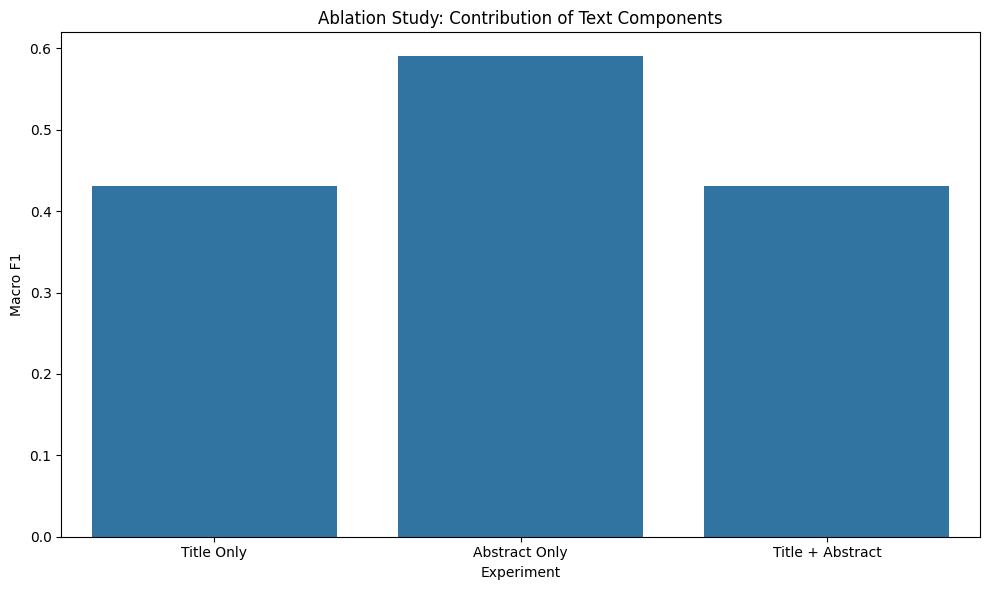

In [ ]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=ablation_df,
    x="Experiment",
    y="Macro F1"
)

plt.title(
    "Ablation Study: Contribution of Text Components"
)

plt.tight_layout()

plt.show()

In [ ]:
final_comparison.to_csv(
    "final_results.csv",
    index=False
)

pd.DataFrame(
    tuning_results
).to_csv(
    "hyperparameter_tuning_results.csv",
    index=False
)

ablation_df.to_csv(
    "ablation_results.csv",
    index=False
)

print(
    "All results saved successfully."
)

All results saved successfully.


# Ensemble

In [ ]:
print(bert_probs.shape)
print(lr_probs.shape)
print(bigru_probs.shape)

(7498, 8)
(7498, 8)
(7498, 8)


In [ ]:
gru_final_result["probabilities"]

array([[2.4217343e-02, 2.1956425e-02, 3.1512494e-03, ..., 1.2985269e-03,
        4.4696167e-02, 8.4708389e-03],
       [3.4414355e-02, 1.3191061e-03, 4.8723891e-03, ..., 7.2963513e-04,
        1.6903487e-03, 7.0613492e-03],
       [8.5999763e-01, 8.3634987e-02, 1.3699757e-02, ..., 1.0520965e-02,
        8.0551384e-03, 2.1704346e-02],
       ...,
       [2.9916417e-05, 3.5904490e-05, 6.4237640e-05, ..., 5.5786816e-04,
        1.2048027e-06, 1.2939936e-05],
       [7.7685034e-01, 1.6623259e-03, 1.6278350e-01, ..., 4.6613198e-03,
        3.1783056e-04, 4.8796318e-02],
       [2.3600903e-04, 6.6695869e-04, 7.9800258e-04, ..., 2.9799349e-03,
        3.2343924e-05, 1.5679772e-04]], dtype=float32)

In [ ]:
def evaluate_transformer_on_test(
    trainer,
    test_dataset,
    model_name
):

    output = trainer.predict(
        test_dataset
    )

    logits = output.predictions

    probabilities = torch.softmax(
        torch.tensor(logits),
        dim=1
    ).numpy()

    predictions = np.argmax(
        probabilities,
        axis=1
    )

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    macro_f1 = f1_score(
        y_test,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test,
        predictions,
        average="weighted"
    )

    print(
        classification_report(
            y_test,
            predictions,
            target_names=class_names,
            digits=4
        )
    )

    return {
        "model": model_name,
        "representation": "Transformer",
        "test_accuracy": accuracy,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "predictions": predictions,
        "probabilities": probabilities
    }

In [ ]:
bert_final_result = evaluate_transformer_on_test(
    best_bert_trainer,
    best_bert_test_dataset,
    f"BERT Base ({best_bert_config})"
)

              precision    recall  f1-score   support

          cs     0.8924    0.8319    0.8611      1993
        econ     0.6364    0.3333    0.4375        21
        eess     0.5273    0.6349    0.5761       304
        math     0.8836    0.9089    0.8961      1570
     physics     0.9643    0.9522    0.9582      3266
       q-bio     0.6311    0.6311    0.6311       103
       q-fin     0.7500    0.8250    0.7857        40
        stat     0.4275    0.5871    0.4948       201

    accuracy                         0.8817      7498
   macro avg     0.7141    0.7130    0.7051      7498
weighted avg     0.8896    0.8817    0.8846      7498



In [ ]:
lr_probabilities = best_lr_model.predict_proba(
    X_test_tfidf
)

lr_predictions = np.argmax(
    lr_probabilities,
    axis=1
)

In [ ]:
nb_probabilities = best_nb_model.predict_proba(
    X_test_tfidf
)

In [ ]:
rf_probabilities = best_rf_model.predict_proba(
    X_test_tfidf
)

In [ ]:
classical_probabilities = best_lr_model.predict_proba(
    X_test_tfidf
)

rnn_probabilities = bilstm_final_result[
    "probabilities"
]

transformer_probabilities = bert_final_result[
    "probabilities"
]

print(
    "ML:",
    classical_probabilities.shape
)

print(
    "RNN:",
    rnn_probabilities.shape
)

print(
    "Transformer:",
    transformer_probabilities.shape
)

ML: (7498, 8)
RNN: (7498, 8)
Transformer: (7498, 8)


In [ ]:
ensemble_probabilities = (
    classical_probabilities
    +
    rnn_probabilities
    +
    transformer_probabilities
) / 3

ensemble_predictions = np.argmax(
    ensemble_probabilities,
    axis=1
)

ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_predictions
)

ensemble_macro_f1 = f1_score(
    y_test,
    ensemble_predictions,
    average="macro"
)

ensemble_weighted_f1 = f1_score(
    y_test,
    ensemble_predictions,
    average="weighted"
)

print("=" * 70)

print(
    "SOFT VOTING ENSEMBLE RESULTS"
)

print("=" * 70)

print(
    "Accuracy:",
    round(
        ensemble_accuracy,
        4
    )
)

print(
    "Macro F1:",
    round(
        ensemble_macro_f1,
        4
    )
)

print(
    "Weighted F1:",
    round(
        ensemble_weighted_f1,
        4
    )
)

SOFT VOTING ENSEMBLE RESULTS
Accuracy: 0.8798
Macro F1: 0.6815
Weighted F1: 0.8852


Weighted ensemble

In [ ]:
ensemble_probabilities_weighted = (
    0.50 * bert_probs
    +
    0.30 * lr_probs
    +
    0.20 * bigru_probs
)

ensemble_predictions_weighted = np.argmax(
    ensemble_probabilities_weighted,
    axis=1
)

In [ ]:
weighted_ensemble_accuracy = accuracy_score(
    y_test,
    ensemble_predictions_weighted
)

weighted_ensemble_macro_f1 = f1_score(
    y_test,
    ensemble_predictions_weighted,
    average="macro"
)

weighted_ensemble_weighted_f1 = f1_score(
    y_test,
    ensemble_predictions_weighted,
    average="weighted"
)

print("=" * 70)

print(
    "WEIGHTED SOFT VOTING ENSEMBLE"
)

print("=" * 70)

print(
    "Accuracy:",
    weighted_ensemble_accuracy
)

print(
    "Macro F1:",
    weighted_ensemble_macro_f1
)

print(
    "Weighted F1:",
    weighted_ensemble_weighted_f1
)

WEIGHTED SOFT VOTING ENSEMBLE
Accuracy: 0.8865030674846626
Macro F1: 0.7142499117017831
Weighted F1: 0.8898051503476003


Confusion Matrix with classification report

              precision    recall  f1-score   support

          cs     0.8905    0.8404    0.8647      1993
        econ     0.6364    0.3333    0.4375        21
        eess     0.5277    0.6579    0.5857       304
        math     0.9007    0.9070    0.9038      1570
     physics     0.9698    0.9525    0.9611      3266
       q-bio     0.5896    0.7670    0.6667       103
       q-fin     0.7619    0.8000    0.7805        40
        stat     0.4542    0.5920    0.5140       201

    accuracy                         0.8865      7498
   macro avg     0.7163    0.7313    0.7142      7498
weighted avg     0.8952    0.8865    0.8898      7498



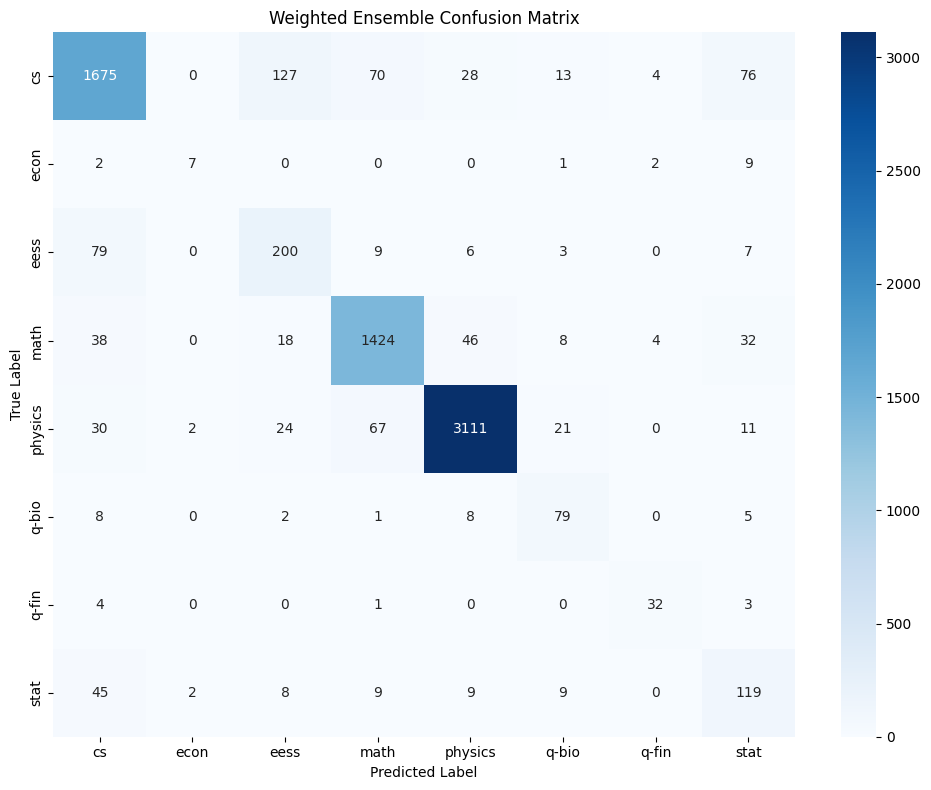

In [ ]:
print(
    classification_report(
        y_test,
        ensemble_predictions_weighted,
        target_names=class_names,
        digits=4
    )
)

plot_confusion_matrix(
    y_test,
    ensemble_predictions_weighted,
    "Weighted Ensemble Confusion Matrix"
)

In [ ]:
ensemble_result = {
    "model": "Weighted Soft Voting Ensemble",
    "representation": "TF-IDF + Word2Vec + Transformer",
    "test_accuracy": weighted_ensemble_accuracy,
    "test_macro_f1": weighted_ensemble_macro_f1,
    "test_weighted_f1": weighted_ensemble_weighted_f1,
    "predictions": ensemble_predictions_weighted,
    "probabilities": ensemble_probabilities_weighted
}

all_final_results.append(
    ensemble_result
)

Ensemble actual best models

In [ ]:
best_lr_probabilities = best_lr_model.predict_proba(
    X_test_tfidf
)

best_bigru_probabilities = best_bigru_model.predict(
    X_test_pad,
    batch_size=256,
    verbose=1
)

best_transformer_probabilities = bert_final_result[
    "probabilities"
]

final_ensemble_probabilities = (
    0.20 * best_bigru_probabilities
    +
    0.30 * best_lr_probabilities
    +
    0.50 * best_transformer_probabilities
)

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


# Final Evaluation

In [ ]:
best_model = final_comparison.iloc[0]

print("=" * 80)
print("PROJECT CONCLUSIONS")
print("=" * 80)

print(
    "\nBest Model:"
)

print(
    best_model["Model"]
)

print(
    "\nBest Macro F1:"
)

print(
    round(
        best_model["Macro F1"],
        4
    )
)

print(
    "\nBest Accuracy:"
)

print(
    round(
        best_model["Accuracy"],
        4
    )
)

print(
    "\nKey Findings:"
)

print(
    """
1. Traditional TF-IDF models provided strong baseline performance.
2. Sequential neural networks benefited from Word2Vec embeddings.
3. Bidirectional architectures were compared against unidirectional variants.
4. Transformer models captured contextual relationships in scientific text.
5. The ensemble experiment investigated whether complementary models could improve generalization.
6. The ablation study measured the contribution of titles and abstracts.
"""
)

PROJECT CONCLUSIONS

Best Model:
Weighted Ensemble

Best Macro F1:
0.7142

Best Accuracy:
0.8865

Key Findings:

1. Traditional TF-IDF models provided strong baseline performance.
2. Sequential neural networks benefited from Word2Vec embeddings.
3. Bidirectional architectures were compared against unidirectional variants.
4. Transformer models captured contextual relationships in scientific text.
5. The ensemble experiment investigated whether complementary models could improve generalization.
6. The ablation study measured the contribution of titles and abstracts.



# Conclusions

In [ ]:
conclusion_df = final_comparison.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)


best_model = conclusion_df.iloc[0]


individual_models = conclusion_df[
    conclusion_df["Model"] != "Weighted Ensemble"
].copy()

best_individual = individual_models.iloc[0]


ensemble_row = conclusion_df[
    conclusion_df["Model"] == "Weighted Ensemble"
]

print("=" * 80)
print("PROJECT CONCLUSION")
print("=" * 80)

print(
    "\nThis project investigated the automatic classification of "
    "arXiv research papers into eight major academic disciplines using "
    "machine learning, deep learning, and transformer-based approaches."
)

print(
    "\nThe study compared classical machine learning models, recurrent "
    "neural network architectures, and transformer-based models using "
    "Accuracy, Macro F1-score, and Weighted F1-score."
)

print(
    f"\nThe best overall model was {best_model['Model']}, "
    f"which achieved an Accuracy of {best_model['Accuracy']:.4f}, "
    f"a Macro F1-score of {best_model['Macro F1']:.4f}, and "
    f"a Weighted F1-score of {best_model['Weighted F1']:.4f}."
)

print(
    f"\nAmong the individual models, {best_individual['Model']} "
    f"achieved the strongest performance with a Macro F1-score of "
    f"{best_individual['Macro F1']:.4f}."
)


if not ensemble_row.empty:

    ensemble = ensemble_row.iloc[0]

    improvement = (
        ensemble["Macro F1"]
        - best_individual["Macro F1"]
    )

    print(
        "\nA weighted soft-voting ensemble was also developed by "
        "combining BERT, Logistic Regression, and BiGRU."
    )

    print(
        f"The ensemble achieved an Accuracy of "
        f"{ensemble['Accuracy']:.4f}, a Macro F1-score of "
        f"{ensemble['Macro F1']:.4f}, and a Weighted F1-score of "
        f"{ensemble['Weighted F1']:.4f}."
    )

    if improvement > 0:

        print(
            f"\nThe ensemble improved upon the best individual model "
            f"by {improvement:.4f} Macro F1 points. This suggests that "
            f"combining different model architectures can leverage "
            f"their complementary strengths and improve overall "
            f"classification performance."
        )

    elif improvement == 0:

        print(
            "\nThe ensemble matched the performance of the best "
            "individual model. This indicates that combining the models "
            "provided competitive performance, although it did not "
            "produce additional improvement."
        )

    else:

        print(
            f"\nThe ensemble performed {abs(improvement):.4f} Macro F1 "
            f"points below the best individual model. However, the "
            f"ensemble experiment remains valuable because it evaluates "
            f"whether combining traditional machine learning, recurrent "
            f"neural networks, and transformer-based models provides "
            f"additional benefits."
        )

print(
    "\nOverall, the results demonstrate that automated research paper "
    "classification can be effectively addressed using a range of NLP "
    "and machine learning approaches."
)

print(
    "\nThe developed system has potential real-world applications in "
    "academic digital libraries, research paper recommendation systems, "
    "automatic document organization, and research discovery platforms."
)

print(
    "\nFuture work could include using larger datasets, improving class "
    "balance, performing additional hyperparameter optimization, testing "
    "more transformer architectures, and deploying the best-performing "
    "model in an interactive web application."
)

print("=" * 80)

PROJECT CONCLUSION

This project investigated the automatic classification of arXiv research papers into eight major academic disciplines using machine learning, deep learning, and transformer-based approaches.

The study compared classical machine learning models, recurrent neural network architectures, and transformer-based models using Accuracy, Macro F1-score, and Weighted F1-score.

The best overall model was Weighted Ensemble, which achieved an Accuracy of 0.8865, a Macro F1-score of 0.7142, and a Weighted F1-score of 0.8898.

Among the individual models, BERT Base (BERT Config 3) achieved the strongest performance with a Macro F1-score of 0.7051.

A weighted soft-voting ensemble was also developed by combining BERT, Logistic Regression, and BiGRU.
The ensemble achieved an Accuracy of 0.8865, a Macro F1-score of 0.7142, and a Weighted F1-score of 0.8898.

The ensemble improved upon the best individual model by 0.0092 Macro F1 points. This suggests that combining different model a

## Discussion of Model and Configuration Differences

The experimental results show that the performance of the models differs because each architecture represents and processes textual information differently. The models also vary in their ability to capture word importance, sequential relationships, long-range dependencies, and contextual meaning.

### Classical Machine Learning Models

The classical machine learning models used TF-IDF representations. TF-IDF captures the importance of words based on their frequency within a document and across the dataset.

Logistic Regression can perform strongly on text classification tasks because high-dimensional sparse TF-IDF features are well suited to linear decision boundaries. Important discipline-specific terms can receive strong weights and contribute directly to the classification decision.

Naive Bayes is computationally efficient and often provides a strong baseline for text classification. However, its assumption that features are conditionally independent is a simplification. Research paper abstracts contain relationships between terms, and these dependencies may limit the performance of Naive Bayes compared with more flexible models.

Random Forest can model more complex non-linear relationships, but sparse and high-dimensional TF-IDF representations may not always be ideal for tree-based models. This can explain differences between Random Forest and the linear models.

### Recurrent Neural Network Models

The RNN-based models process text as ordered sequences rather than independent TF-IDF features. This allows them to learn patterns based on word order and contextual relationships.

Simple RNN models may experience difficulty learning long-range dependencies because information from earlier words can gradually disappear during training. This limitation can affect performance when important relationships occur across long research abstracts.

GRU and LSTM architectures were designed to address this problem through gating mechanisms. These gates help the models decide which information should be retained or forgotten. As a result, GRU and LSTM models may capture longer dependencies more effectively than a Simple RNN.

BiRNN, BiGRU, and BiLSTM models process sequences in both forward and backward directions. This allows a word to be interpreted using information from both earlier and later words in the sequence. This can be particularly useful for research abstracts where the meaning of a technical term may depend on surrounding context.

However, bidirectional architectures also contain greater computational complexity and more parameters. Therefore, better architectural complexity does not always guarantee better performance because larger models may require more training data or careful hyperparameter tuning.

### BERT

BERT differs from the other models because it is pretrained on a large amount of text before being fine-tuned for the specific classification task. Instead of learning only from the project dataset, BERT begins with pretrained language knowledge.

The transformer architecture uses self-attention to capture relationships between words regardless of their distance within the sequence. This allows BERT to model contextual and long-range dependencies more effectively than traditional sequential models.

Research paper abstracts contain complex terminology and contextual relationships, making contextual representations particularly valuable. This is one reason why transformer-based models can perform strongly in academic text classification.

### Why Hyperparameter Configurations Produced Different Results

Different configurations produced different results because hyperparameters directly affect how the models learn from the training data.

#### Learning Rate

The learning rate controls the size of parameter updates during training.

- A learning rate that is too high may cause unstable training or prevent the model from reaching a good solution.
- A learning rate that is too low may result in slow convergence or insufficient learning within the selected number of epochs.

Therefore, different learning rates can produce noticeably different model performance.

#### Batch Size

Batch size determines how many samples are processed before updating the model parameters.

Smaller batch sizes can introduce more variation into the optimization process, while larger batch sizes can provide more stable gradient estimates. The best batch size depends on the model architecture and dataset.

#### Number of Epochs

The number of epochs determines how many times the model processes the training data.

Too few epochs may lead to underfitting, where the model has not learned enough patterns. Too many epochs may lead to overfitting, where the model learns patterns specific to the training data and performs less effectively on unseen data.

#### Hidden Units and Model Complexity

For RNN models, the number of hidden units controls the capacity of the network.

A model with too few units may not have enough capacity to learn complex patterns, while a model with too many units may increase computational cost and the risk of overfitting.

#### Dropout and Regularization

Dropout reduces overfitting by randomly disabling some neurons during training. Different dropout values can therefore affect the balance between learning complex patterns and generalizing to unseen data.

### Comparison of Model Families

The results demonstrate the differences between the three main model families:

1. **Classical Machine Learning**
   - Fast and computationally efficient.
   - Strong baseline performance with TF-IDF.
   - Effective when important keywords and terms strongly indicate the target class.

2. **RNN-Based Deep Learning**
   - Learns sequential relationships between words.
   - Can capture contextual patterns beyond individual word frequencies.
   - Gated and bidirectional architectures generally provide more advanced sequence modeling.

3. **Transformer-Based Models**
   - Use pretrained contextual language representations.
   - Capture relationships between distant words using self-attention.
   - Require greater computational resources but can provide strong performance on complex text classification tasks.

### Ensemble Model

A weighted soft-voting ensemble was created using BERT, Logistic Regression, and BiGRU. These models were selected because they represent three different approaches to text classification:

- Logistic Regression captures statistical patterns using TF-IDF features.
- BiGRU captures sequential patterns using bidirectional recurrent processing.
- BERT captures contextual relationships using transformer-based language representations.

The ensemble combines the predicted probabilities of the three models. This approach attempts to benefit from the complementary strengths of the individual architectures.

If the ensemble achieves better performance than the best individual model, this suggests that the models make different types of useful predictions and that combining them improves generalization.

If the ensemble does not outperform the best individual model, the experiment still provides useful evidence that combining models does not automatically guarantee improved performance. The results may indicate that the strongest model already captures most of the useful patterns or that the ensemble weights could require further optimization.

### Overall Discussion

Overall, the differences in model performance demonstrate that text classification performance depends not only on model complexity but also on the compatibility between the model architecture, text representation, preprocessing strategy, and hyperparameter configuration.

The experiments show the progression from statistical text representations and classical machine learning to sequential neural networks and contextual transformer models. This provides a comprehensive comparison of different approaches to multi-class research paper classification.

In [ ]:
with open("project_conclusion.txt", "w", encoding="utf-8") as file:

    file.write("PROJECT CONCLUSION\n")
    file.write("=" * 80 + "\n\n")

    file.write(
        f"Best Overall Model: {best_model['Model']}\n"
    )

    file.write(
        f"Accuracy: {best_model['Accuracy']:.4f}\n"
    )

    file.write(
        f"Macro F1: {best_model['Macro F1']:.4f}\n"
    )

    file.write(
        f"Weighted F1: {best_model['Weighted F1']:.4f}\n"
    )

print("Conclusion summary saved successfully!")

Conclusion summary saved successfully!
